# Módulo 2: Story telling

**Objetivo**:  Tomar lo hecho hasta el momento, juntar los 4 conjuntos y demostrar un panorama general los datos y de cómo estaba la educación del estado en los años 2013 a 2015.


In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import re
import os
import matplotlib.pyplot as plt
import unidecode
from copy import deepcopy

%matplotlib inline
plt.style.use('ggplot')

In [2]:
!pip install geopandas


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Reading files
files = {'evaluaciones': 'final_evaluaciones',
        'inversiones': 'final_inversiones',
        'genero_y_personal': 'final_genero_y_personal',
        'eficiencia': 'final_eficiencia'}

basedir = '.'

frames = {}
for file_type, file_name in files.items():
    print(f'-> Leyendo el file de tipo `{file_type}`.\n')
    
    file_dir = os.path.join(basedir, file_name + '.csv')
    frames[file_type] = pd.read_csv(file_dir, encoding='latin1')
    
print(f'-> Files leídos.')

-> Leyendo el file de tipo `evaluaciones`.

-> Leyendo el file de tipo `inversiones`.

-> Leyendo el file de tipo `genero_y_personal`.

-> Leyendo el file de tipo `eficiencia`.

-> Files leídos.


In [4]:
frames['evaluaciones'].head()

,Unnamed: 0.2,Unnamed: 0,Unnamed: 0.1,nivel,clave_de_la_escuela,turno,alumnos_programados_prueba,porcentaje_de_evaluados_lenguaje_y_comunicacian,porcentaje_de_evaluados_matematicas,la_prueba_es_representativa_leguaje_y_comunicacian,...,nivel_i_lenguaje_y_comunicacian_(%),nivel_ii_lenguaje_y_comunicacian_(%),nivel_iii_lenguaje_y_comunicacian_(%),nivel_iv_lenguaje_y_comunicacian_(%),nivel_predominante_lenguaje_y_comunicacian,nivel_i_matematicas_(%),nivel_ii_matematicas_(%),nivel_iii_matematicas_(%),nivel_iv_matematicas_(%),nivel_predominante_matematicas
0,0,0,0,PRIMARIA,14DPB0001Y,MATUTINO,12,83.3,83.3,SI,...,90.0,10.0,NaN,NaN,I,100.0,NaN,NaN,NaN,I
1,1,1,1,PRIMARIA,14DPB0002X,COMPLETO,58,96.6,96.6,SI,...,98.2,1.8,NaN,NaN,I,78.6,17.9,3.6,NaN,I
2,2,2,2,PRIMARIA,14DPB0004V,MATUTINO,13,100.0,100.0,SI,...,100.0,NaN,NaN,NaN,I,100.0,NaN,NaN,NaN,I
3,3,3,3,PRIMARIA,14DPB0005U,MATUTINO,12,91.7,91.7,SI,...,90.9,9.1,NaN,NaN,I,90.9,9.1,NaN,NaN,I
4,4,4,4,PRIMARIA,14DPB0006T,COMPLETO,35,94.3,94.3,SI,...,97.0,3.0,NaN,NaN,I,87.9,12.1,NaN,NaN,I


In [5]:
frames['inversiones'].head()

,Unnamed: 0.2,Unnamed: 0,Unnamed: 0.1,municipio,clave_ct,responsable,turno,nombre_ct,director,nivel,...,observacion_pec2014_pec2014,observacion_mobiliario_piezas,observacion_mobiliario_alumnos,observacion_mobiliario_matricula,inmueble_cleaned,director_cleaned,responsable_cleaned,turno_cleaned,nombre_ct_cleaned,nivel_cleaned
0,0,0,0,AHUALULCO DE MERCADO,14DPR0273Q,R,MATUTINO,5 DE MAYO,ANGELICA IVETT FLORES CARDENAS,PRIMARIA,...,NaN,569.0,304.0,304.0,1406848k,angelica_ivett_flores_cardenas,r,matutino,5_de_mayo,primaria
1,1,1,1,AHUALULCO DE MERCADO,14EPR0482V,R,MATUTINO,VALENTIN GOMEZ FARIAS,MARIA EDITH CRUZ CASTAÃÂÃÂÃÂÃÂEDA,PRIMARIA,...,NaN,179.0,93.0,93.0,1406850c,maria_edith_cruz_castaaaeda,r,matutino,valentin_gomez_farias,primaria
2,2,2,2,AHUALULCO DE MERCADO,14EJN0200G,R,MATUTINO,EMILIANO ZAPATA,HILDA GARCIA VEGA,PREESCOLAR,...,NaN,204.0,142.0,142.0,1406852k,hilda_garcia_vega,r,matutino,emiliano_zapata,preescolar
3,3,3,3,AHUALULCO DE MERCADO,14DJN0155L,R,MATUTINO,JAVIER URIBE,MARIA ELENA ARELLANO NUÃÂÃÂÃÂÃÂEZ,PREESCOLAR,...,NaN,168.0,117.0,117.0,1406854h,maria_elena_arellano_nuaaez,r,matutino,javier_uribe,preescolar
4,4,4,4,AHUALULCO DE MERCADO,14EPR0014B,R,MATUTINO,JOSE MA MERCADO,MARIA CONSEPCION PINZON RODRIGUEZ,PRIMARIA,...,289.0,518.0,276.0,344.0,1406855a,maria_consepcion_pinzon_rodriguez,r,matutino,jose_ma_mercado,primaria


In [6]:
frames['genero_y_personal'].head()

,Unnamed: 0.2,Unnamed: 0,Unnamed: 0.1,clave_ct,nom_turno,nombre_ct,domicilio,localidad_inegi,nombre_localidad,nombre_colonia,...,docentes,grupos,docenete_educacion_fisica,docente_actividades_artisticas,docente_actividades_tecnonologicas,docente_de_idiomas,personal_de_administrativo_y_servicios,director_con_grupo,director_sin_grupo,total_de_personal
0,0,0,0,14DJN0128O,MATUTINO,JUAN_DE_LA_BARRERA,ARQUIMEDES_723,1,GUADALAJARA,HERMOSA_PROVINCIA,...,6,6,1,1,0,0,2,0,1,11
1,1,1,1,14DJN0129N,MATUTINO,JOSEFA_ORTIZ_DE_DOMINGUEZ,OBREGON_70,1,AUTLAN_DE_NAVARRO,0,...,7,7,1,1,0,0,2,1,0,11
2,2,2,2,14DJN0130C,MATUTINO,ROSAURA_ZAPATA,PEDRO_CELESTINO_NEGRETE_144,1,GUADALAJARA,OBLATOS,...,7,7,1,1,0,0,2,0,1,12
3,3,3,3,14DJN0132A,MATUTINO,UNIDAD_MODELO,UNIDAD_MODELO,1,GUADALAJARA,UNIDAD_MODELO,...,5,5,1,2,0,0,2,0,1,11
4,4,4,4,14DJN0133Z,MATUTINO,CIPRIANA_GUTIERREZ_RODRIGUEZ,GREGORIO_DAVILA_1081,1,GUADALAJARA,MEZQUITAN_COUNTRY,...,4,4,1,0,0,0,2,1,0,7


In [7]:
frames['eficiencia'].head()

,Unnamed: 0.2,Unnamed: 0,Unnamed: 0.1,clave_ct,nom_turno,nombre_ct,domicilio,localidad_inegi,nombre_localidad,colonia,nombre_colonia,municipio_clave_inegi,nombre_municipio,sostenimiento,nivel,programa,deserciin_intracurricular,reprobaciin,reprobaciin__con_regularizados,eficiencia_terminal
0,0,0,0,14DJN0128O,MATUTINO,JUAN_DE_LA_BARRERA,ARQUIMEDES_723,1,GUADALAJARA,9386,HERMOSA_PROVINCIA,39,GUADALAJARA,FEDERALIZADO,PREESCOLAR,GENERAL,NaN,NaN,NaN,NaN
1,1,1,1,14DJN0129N,MATUTINO,JOSEFA_ORTIZ_DE_DOMINGUEZ,OBREGON_70,1,AUTLAN_DE_NAVARRO,0,0,15,AUTLAN_DE_NAVARRO,FEDERALIZADO,PREESCOLAR,GENERAL,NaN,NaN,NaN,NaN
2,2,2,2,14DJN0130C,MATUTINO,ROSAURA_ZAPATA,PEDRO_CELESTINO_NEGRETE_144,1,GUADALAJARA,9417,OBLATOS,39,GUADALAJARA,FEDERALIZADO,PREESCOLAR,GENERAL,NaN,NaN,NaN,NaN
3,3,3,3,14DJN0132A,MATUTINO,UNIDAD_MODELO,UNIDAD_MODELO,1,GUADALAJARA,9445,UNIDAD_MODELO,39,GUADALAJARA,FEDERALIZADO,PREESCOLAR,GENERAL,NaN,NaN,NaN,NaN
4,4,4,4,14DJN0133Z,MATUTINO,CIPRIANA_GUTIERREZ_RODRIGUEZ,GREGORIO_DAVILA_1081,1,GUADALAJARA,9061,MEZQUITAN_COUNTRY,39,GUADALAJARA,FEDERALIZADO,PREESCOLAR,GENERAL,NaN,NaN,NaN,NaN


Para poder mergear nuestros sets es importante identificar los `keys` con los que vamos a `joinear`. 




In [8]:
# Keys
indexes = {'evaluaciones': 'clave_de_la_escuela',
          'inversiones': 'clave_ct',
          'genero_y_personal': 'clave_ct',
          'eficiencia': 'clave_ct'}

##### Merge de nuestros sets

Comenzaremos haciendo _merge_ de nuestros sets, antes de eso hay que considerar que pueden existir duplicados y necesitamos tener muy claro cómo vamos a hacer ese merge. 

In [9]:
df = frames['inversiones']
duplicates = df.loc[df.clave_ct.duplicated(), 'clave_ct'].unique().tolist()

len(duplicates)

90

Iniciamos con 100 duplicados, tomaremos una instancia que se repite en todos los sets y veamos paso a paso cómo va cambiando. 

In [10]:
df.loc[df.clave_ct == '14DST0034B']

,Unnamed: 0.2,Unnamed: 0,Unnamed: 0.1,municipio,clave_ct,responsable,turno,nombre_ct,director,nivel,...,observacion_pec2014_pec2014,observacion_mobiliario_piezas,observacion_mobiliario_alumnos,observacion_mobiliario_matricula,inmueble_cleaned,director_cleaned,responsable_cleaned,turno_cleaned,nombre_ct_cleaned,nivel_cleaned
8647,9421,9421,9421,TONALA,14DST0034B,R,MATUTINO,ESCUELA SECUNDARIA TECNICA 34,ENRIQUE ANGEL RODRIGUEZ MEJIA,SECUNDARIA,...,765.0,NaN,NaN,NaN,1411124a,enrique_angel_rodriguez_mejia,r,matutino,escuela_secundaria_tecnica_34,secundaria
8648,9422,9422,9422,TONALA,14DST0034B,L,VESPERTINO,ESCUELA SECUNDARIA TECNICA 34,ENRIQUE ANGEL RODRIGUEZ MEJIA,SECUNDARIA,...,NaN,NaN,NaN,NaN,1411124a,enrique_angel_rodriguez_mejia,l,vespertino,escuela_secundaria_tecnica_34,secundaria


Notamos que está bien que esté duplicada, si bien es el mismo plantel corresponde a dos instancias en principio diferentes pues son de turnos separados.

Un plantel tiene alumnos diferentes en cada turno, habrá que confirmar esto después de añadir información. 

##### Decidiendo claves para hacer merge
Tomemos el dataset de inversiones y el de eficiencia para comenzar. 

In [11]:
intersection = set(frames['inversiones'].columns.tolist()).intersection(frames['eficiencia'].columns.tolist())
intersection

{'Unnamed: 0',
 'Unnamed: 0.1',
 'Unnamed: 0.2',
 'clave_ct',
 'nivel',
 'nombre_ct'}

In [12]:
df = pd.merge(frames['inversiones'], frames['eficiencia'],
             left_on=['clave_ct', 'turno'],
             right_on=['clave_ct', 'nom_turno'],
             how='inner',
             suffixes=('_inversion', '_eficiencia'))

duplicate_sum = df.clave_ct.duplicated().sum()
df.shape, duplicate_sum

((7631, 94), np.int64(87))

Notamos que comparten *CLAVE_CT* y *TURNO* (ésta con nombres diferentes cada uno).

La siguiente pregunta que tenemos que resolver es: ¿hay columnas que sean comunes entre ambos frames? 

Hagamos una iteración de código para ver dónde es que nuestros datos son diferentes. 

In [13]:
for col in intersection:
    if col == 'clave_ct' or 'Unnamed' in col:
        continue
    different = df.loc[df[col + '_inversion'] != df[col + '_eficiencia']].shape[0]
    if different > 0:
        print(f'Problema con columna {col}')
    else:
        print(f'Todo fine con columa {col}')

Problema con columna nombre_ct
Todo fine con columa nivel


Veamos los errores con la columna de nombre. 

In [14]:
col = 'nombre_ct'

cols = [col + '_inversion', col + '_eficiencia']

df.loc[df[col + '_inversion'] != df[col + '_eficiencia'], cols + ['clave_ct']].tail()

,nombre_ct_inversion,nombre_ct_eficiencia,clave_ct
7626,JORGE WILMONT MASON,JORGE_WILMONT_MASON,14DJN2279H
7627,HERMINIO LARIOS,HERMINIO_LARIOS,14EES0086O
7628,JUAN SORIANO,JUAN_SORIANO,14DPR4197B
7629,LUIS HECTOR ALVAREZ ALVAREZ,LUIS_HECTOR_ALVAREZ_ALVAREZ,14DPR4206T
7630,GONZALO CHAPELA Y BLANCO,GONZALO_CHAPELA_Y_BLANCO,14DES0144P


Ahora veamos la columna "todo cool"

In [15]:
col = 'nivel'
cols = [col + '_inversion', col + '_eficiencia']

df.loc[df[col + '_inversion'] != df[col + '_eficiencia'], cols + ['clave_ct']].tail()

,nivel_inversion,nivel_eficiencia,clave_ct


Vemos que los no coincidencias son por errores de textos originales en la forma de escribir el nombre por parte de los capturistas o al momento de leer archivos, no es de preocuparse y podemos omitir de manera segura una de esas columnas.

Para omitirlo de una manera segura, se hará otra vez el merge ahora ya sin el "sufijo".

In [16]:
df = pd.merge(frames['inversiones'], frames['eficiencia'],
             left_on=['clave_ct', 'turno'],
             right_on=['clave_ct', 'nom_turno'],
             how='inner',
             suffixes=('_drop', ''))

df[['nombre_ct_drop', 'nombre_ct']].head()

,nombre_ct_drop,nombre_ct
0,JAVIER URIBE,JAVIER_URIBE
1,JOSE MA MERCADO,JOSE_MA_MERCADO
2,PATRIA,PATRIA
3,LEONARDO OLIVA,LEONARDO_OLIVA
4,LUIS MANUEL ROJAS ARRIOLA,LUIS_MANUEL_ROJAS_ARRIOLA


Volvamos a revisar a nuestro plantel de confianza: 14DST0034B.  

In [17]:
df.loc[df.clave_ct == '14DST0034B']

,Unnamed: 0.2_drop,Unnamed: 0_drop,Unnamed: 0.1_drop,municipio,clave_ct,responsable,turno,nombre_ct_drop,director,nivel_drop,...,nombre_colonia,municipio_clave_inegi,nombre_municipio,sostenimiento,nivel,programa,deserciin_intracurricular,reprobaciin,reprobaciin__con_regularizados,eficiencia_terminal
7575,9421,9421,9421,TONALA,14DST0034B,R,MATUTINO,ESCUELA SECUNDARIA TECNICA 34,ENRIQUE ANGEL RODRIGUEZ MEJIA,SECUNDARIA,...,0,101,TONALA,FEDERALIZADO,SECUNDARIA,TECNICA,1.03,5.60,3.11,89.71
7576,9422,9422,9422,TONALA,14DST0034B,L,VESPERTINO,ESCUELA SECUNDARIA TECNICA 34,ENRIQUE ANGEL RODRIGUEZ MEJIA,SECUNDARIA,...,0,101,TONALA,FEDERALIZADO,SECUNDARIA,TECNICA,3.20,6.61,5.11,95.05


¿Cómo puedo calificar que todo va bien? 

Porque sigo teniendo las dos instancias que había visto en un principio.


Todo bien, por lo que procedemos a hacer lo propio con otro set.

In [18]:
intersection = set(df.columns.tolist()).intersection(frames['genero_y_personal'].columns.tolist())
intersection

{'Unnamed: 0',
 'Unnamed: 0.1',
 'Unnamed: 0.2',
 'clave_ct',
 'domicilio',
 'grupos',
 'localidad_inegi',
 'municipio',
 'nivel',
 'nom_turno',
 'nombre_colonia',
 'nombre_ct',
 'nombre_localidad',
 'nombre_municipio',
 'programa',
 'sostenimiento'}

In [19]:
df = pd.merge(df, frames['genero_y_personal'],
             left_on=['clave_ct', 'turno'],
             right_on=['clave_ct', 'nom_turno'],
             how='inner',
             suffixes=('', '_genero'))

In [20]:
duplicate_sum = df.clave_ct.duplicated().sum()
duplicate_sum

np.int64(87)

In [21]:
df

,Unnamed: 0.2_drop,Unnamed: 0_drop,Unnamed: 0.1_drop,municipio,clave_ct,responsable,turno,nombre_ct_drop,director,nivel_drop,...,docentes,grupos_genero,docenete_educacion_fisica,docente_actividades_artisticas,docente_actividades_tecnonologicas,docente_de_idiomas,personal_de_administrativo_y_servicios,director_con_grupo,director_sin_grupo,total_de_personal
0,3,3,3,AHUALULCO DE MERCADO,14DJN0155L,R,MATUTINO,JAVIER URIBE,MARIA ELENA ARELLANO NUÃÂÃÂÃÂÃÂEZ,PREESCOLAR,...,4,4,0,1,0,0,1,0,1,7
1,4,4,4,AHUALULCO DE MERCADO,14EPR0014B,R,MATUTINO,JOSE MA MERCADO,MARIA CONSEPCION PINZON RODRIGUEZ,PRIMARIA,...,12,12,0,0,1,0,1,0,1,15
2,5,5,5,AHUALULCO DE MERCADO,14EPR0347Q,L,VESPERTINO,PATRIA,JESUS OMAR CERVANTES VALDERRAMA,PRIMARIA,...,5,5,0,0,0,0,0,1,0,5
3,6,6,6,AHUALULCO DE MERCADO,14EPR1183D,R,MATUTINO,LEONARDO OLIVA,MARGARITA OLIVA HERNANDEZ,PRIMARIA,...,12,12,0,0,0,0,2,0,1,15
4,7,7,7,AHUALULCO DE MERCADO,14EPR0388Q,L,VESPERTINO,LUIS MANUEL ROJAS ARRIOLA,GILBERTO PONCE,PRIMARIA,...,6,6,0,0,0,0,0,1,0,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7626,9484,9484,9484,TONALA,14DJN2279H,L,VESPERTINO,JORGE WILMONT MASON,CECILIA FIGUEROA HERNANDEZ,PREESCOLAR,...,2,2,0,0,0,0,0,1,0,2
7627,9485,9485,9485,TONALA,14EES0086O,R,MATUTINO,HERMINIO LARIOS,JUAN CRUZ LOPEZ BASTIDAS,SECUNDARIA,...,9,3,1,1,1,0,0,1,0,9
7628,9486,9486,9486,TONALA,14DPR4197B,R,MATUTINO,JUAN SORIANO,PEDRO FABIAN AGUIRRE AGUIRRE,PRIMARIA,...,6,6,1,0,0,0,0,0,1,8
7629,9487,9487,9487,TONALA,14DPR4206T,L,VESPERTINO,LUIS HECTOR ALVAREZ ALVAREZ,JOSUE MANUEL MONTAÃÂÃÂÃÂÃÂO PEREZ,PRIMARIA,...,6,6,0,0,0,0,0,1,0,6


In [22]:
cols_problemas = []

for col in intersection:
    if col == 'clave_ct' or 'Unnamed' in col:
        continue
    different = df.loc[df[col] != df[col + '_genero']].shape[0]
    if different > 0:
        print(f'Problema con columna {col}')
        cols_problemas.append(col)
    else:
        print(f'Todo fine con columa {col}')

Todo fine con columa programa
Todo fine con columa sostenimiento
Problema con columna nombre_ct
Todo fine con columa nombre_localidad
Todo fine con columa nombre_colonia
Problema con columna grupos
Todo fine con columa nom_turno
Problema con columna municipio
Todo fine con columa domicilio
Todo fine con columa localidad_inegi
Todo fine con columa nombre_municipio
Todo fine con columa nivel


Notamos que solo hay problema real con "GRUPOS", ¿por qué viene información diferente e inconsistente dado un mismo CT? :thinking-face

De ahí en fuera la columna de "Municipio" no nos interesa tenerla, tiene solo números que no nos generan valor al ser clasificaciones.

Definamos una variable de `droppers` para ir guardando las variables que tiraremos. 

In [23]:
for col in cols_problemas:
    cols = [col, col + '_genero']
    print(df.loc[df[col] != df[col + '_genero'], cols + ['clave_ct']])

                                   nombre_ct            nombre_ct_genero  \
79                                WAXAA<<IWI                       WAXAA   
484                              XAWE_'UWENI                        XAWE   
527                              T++RI_WAKIE                           T   
1437       GRAL._JUAN_PABLO_ANAYA_HERMOSILLO                        GRAL   
2489        GERARDO_MURILLO_CORNADO_(DR_ATL)     GERARDO_MURILLO_CORNADO   
2641                GERARDO_MURILLO_(DR_ATL)             GERARDO_MURILLO   
2642                GERARDO_MURILLO_(DR_ATL)             GERARDO_MURILLO   
3179                      AURELIA_GUEVARA_L.           AURELIA_GUEVARA_L   
3365                    LEOPOLDO_I._ORENDAIN                  LEOPOLDO_I   
3774                      AURELIA_GUEVARA_L.           AURELIA_GUEVARA_L   
3973                      EDMUNDO_OA<<GORMAN                  EDMUNDO_OA   
4940  JOSE_DE_LOS_REYES_MARTINEZ_(EL_PIPILA)  JOSE_DE_LOS_REYES_MARTINEZ   
5608        

Continuemos ahora con el set de evaluaciones. 

Analicemos primero la intersección de columnas. 

In [24]:
droppers = [d for d in df if '_genero' in d and 'grupos' not in d]
droppers

['Unnamed: 0.2_genero',
 'Unnamed: 0_genero',
 'Unnamed: 0.1_genero',
 'nom_turno_genero',
 'nombre_ct_genero',
 'domicilio_genero',
 'localidad_inegi_genero',
 'nombre_localidad_genero',
 'nombre_colonia_genero',
 'municipio_genero',
 'nombre_municipio_genero',
 'sostenimiento_genero',
 'nivel_genero',
 'programa_genero']

In [25]:
df

,Unnamed: 0.2_drop,Unnamed: 0_drop,Unnamed: 0.1_drop,municipio,clave_ct,responsable,turno,nombre_ct_drop,director,nivel_drop,...,docentes,grupos_genero,docenete_educacion_fisica,docente_actividades_artisticas,docente_actividades_tecnonologicas,docente_de_idiomas,personal_de_administrativo_y_servicios,director_con_grupo,director_sin_grupo,total_de_personal
0,3,3,3,AHUALULCO DE MERCADO,14DJN0155L,R,MATUTINO,JAVIER URIBE,MARIA ELENA ARELLANO NUÃÂÃÂÃÂÃÂEZ,PREESCOLAR,...,4,4,0,1,0,0,1,0,1,7
1,4,4,4,AHUALULCO DE MERCADO,14EPR0014B,R,MATUTINO,JOSE MA MERCADO,MARIA CONSEPCION PINZON RODRIGUEZ,PRIMARIA,...,12,12,0,0,1,0,1,0,1,15
2,5,5,5,AHUALULCO DE MERCADO,14EPR0347Q,L,VESPERTINO,PATRIA,JESUS OMAR CERVANTES VALDERRAMA,PRIMARIA,...,5,5,0,0,0,0,0,1,0,5
3,6,6,6,AHUALULCO DE MERCADO,14EPR1183D,R,MATUTINO,LEONARDO OLIVA,MARGARITA OLIVA HERNANDEZ,PRIMARIA,...,12,12,0,0,0,0,2,0,1,15
4,7,7,7,AHUALULCO DE MERCADO,14EPR0388Q,L,VESPERTINO,LUIS MANUEL ROJAS ARRIOLA,GILBERTO PONCE,PRIMARIA,...,6,6,0,0,0,0,0,1,0,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7626,9484,9484,9484,TONALA,14DJN2279H,L,VESPERTINO,JORGE WILMONT MASON,CECILIA FIGUEROA HERNANDEZ,PREESCOLAR,...,2,2,0,0,0,0,0,1,0,2
7627,9485,9485,9485,TONALA,14EES0086O,R,MATUTINO,HERMINIO LARIOS,JUAN CRUZ LOPEZ BASTIDAS,SECUNDARIA,...,9,3,1,1,1,0,0,1,0,9
7628,9486,9486,9486,TONALA,14DPR4197B,R,MATUTINO,JUAN SORIANO,PEDRO FABIAN AGUIRRE AGUIRRE,PRIMARIA,...,6,6,1,0,0,0,0,0,1,8
7629,9487,9487,9487,TONALA,14DPR4206T,L,VESPERTINO,LUIS HECTOR ALVAREZ ALVAREZ,JOSUE MANUEL MONTAÃÂÃÂÃÂÃÂO PEREZ,PRIMARIA,...,6,6,0,0,0,0,0,1,0,6


In [26]:
intersection

{'Unnamed: 0',
 'Unnamed: 0.1',
 'Unnamed: 0.2',
 'clave_ct',
 'domicilio',
 'grupos',
 'localidad_inegi',
 'municipio',
 'nivel',
 'nom_turno',
 'nombre_colonia',
 'nombre_ct',
 'nombre_localidad',
 'nombre_municipio',
 'programa',
 'sostenimiento'}

In [27]:
droppers = [d for d in df if '_genero' in d and 'grupos' not in d]
tmp_df = pd.merge(df, frames['evaluaciones'],
             left_on=['clave_ct', 'turno'],
             right_on=['clave_de_la_escuela', 'turno'],
             suffixes=('_tmp', '_evaluaciones'))

duplicate_sum = df.clave_ct.duplicated().sum()
duplicate_sum

intersection = set(df.columns.tolist()).intersection(frames['evaluaciones'].columns.tolist())
intersection

{'Unnamed: 0', 'Unnamed: 0.1', 'Unnamed: 0.2', 'nivel', 'turno'}

In [28]:
tmp_df.loc[tmp_df['nivel_tmp'] != tmp_df['nivel_evaluaciones']]

,Unnamed: 0.2_drop,Unnamed: 0_drop,Unnamed: 0.1_drop,municipio,clave_ct,responsable,turno,nombre_ct_drop,director,nivel_drop,...,nivel_i_lenguaje_y_comunicacian_(%),nivel_ii_lenguaje_y_comunicacian_(%),nivel_iii_lenguaje_y_comunicacian_(%),nivel_iv_lenguaje_y_comunicacian_(%),nivel_predominante_lenguaje_y_comunicacian,nivel_i_matematicas_(%),nivel_ii_matematicas_(%),nivel_iii_matematicas_(%),nivel_iv_matematicas_(%),nivel_predominante_matematicas


La columna de nivel y de turno son intersección, entonces la de nivel es la verdadera problemática. 

In [29]:
df = pd.merge(df, frames['evaluaciones'],
             left_on=['clave_ct', 'turno'],
             right_on=['clave_de_la_escuela', 'turno'],
             suffixes=('_tmp', '_drop_'))

No hay diferencia, entonces es seguro droppear una de ellas. Haremos otro merge diferente para que también les agreguemos la terminación "drop".  

In [30]:
df.loc[df.clave_ct == '14DST0034B']

,Unnamed: 0.2_drop,Unnamed: 0_drop,Unnamed: 0.1_drop,municipio,clave_ct,responsable,turno,nombre_ct_drop,director,nivel_drop,...,nivel_i_lenguaje_y_comunicacian_(%),nivel_ii_lenguaje_y_comunicacian_(%),nivel_iii_lenguaje_y_comunicacian_(%),nivel_iv_lenguaje_y_comunicacian_(%),nivel_predominante_lenguaje_y_comunicacian,nivel_i_matematicas_(%),nivel_ii_matematicas_(%),nivel_iii_matematicas_(%),nivel_iv_matematicas_(%),nivel_predominante_matematicas
4426,9421,9421,9421,TONALA,14DST0034B,R,MATUTINO,ESCUELA SECUNDARIA TECNICA 34,ENRIQUE ANGEL RODRIGUEZ MEJIA,SECUNDARIA,...,26.9,52.2,19.4,1.5,II,67.2,29.9,1.5,1.5,I
4427,9422,9422,9422,TONALA,14DST0034B,L,VESPERTINO,ESCUELA SECUNDARIA TECNICA 34,ENRIQUE ANGEL RODRIGUEZ MEJIA,SECUNDARIA,...,23.1,50.8,20.0,6.2,II,63.5,30.2,3.2,3.2,I


Todo se ve finísimo, por lo que ahora vamos a remover las columnas problemáticas (droppers).

Tenemos que agregar las columnas que le agregamos suffix `_drop`. 

In [31]:
droppers

['Unnamed: 0.2_genero',
 'Unnamed: 0_genero',
 'Unnamed: 0.1_genero',
 'nom_turno_genero',
 'nombre_ct_genero',
 'domicilio_genero',
 'localidad_inegi_genero',
 'nombre_localidad_genero',
 'nombre_colonia_genero',
 'municipio_genero',
 'nombre_municipio_genero',
 'sostenimiento_genero',
 'nivel_genero',
 'programa_genero']

In [32]:
new_droppers = set([c  for c in df if 'Unnamed' in c or 'drop' in c] + droppers)

In [33]:
df.drop(new_droppers, axis=1, inplace=True)

In [34]:

df.loc[df.clave_ct == '14DST0034B']

,municipio,clave_ct,responsable,turno,director,matricula,docente,grupos,aulas_existentes,aulas_uso,...,nivel_i_lenguaje_y_comunicacian_(%),nivel_ii_lenguaje_y_comunicacian_(%),nivel_iii_lenguaje_y_comunicacian_(%),nivel_iv_lenguaje_y_comunicacian_(%),nivel_predominante_lenguaje_y_comunicacian,nivel_i_matematicas_(%),nivel_ii_matematicas_(%),nivel_iii_matematicas_(%),nivel_iv_matematicas_(%),nivel_predominante_matematicas
4426,TONALA,14DST0034B,R,MATUTINO,ENRIQUE ANGEL RODRIGUEZ MEJIA,439.0,15.0,12.0,12.0,12.0,...,26.9,52.2,19.4,1.5,II,67.2,29.9,1.5,1.5,I
4427,TONALA,14DST0034B,L,VESPERTINO,ENRIQUE ANGEL RODRIGUEZ MEJIA,326.0,12.0,9.0,12.0,9.0,...,23.1,50.8,20.0,6.2,II,63.5,30.2,3.2,3.2,I


Por seguridad extra, revisemos si los duplicados se siguen dando por la misma razón.

In [35]:
duplicate_sum = df.clave_ct.duplicated().sum()
duplicate_sum, df.shape

(np.int64(84), (4459, 135))

In [36]:
basedir = '.'
saving_df = os.path.join(basedir, 'final_data.csv')
df.to_csv(saving_df)

## Retomando la clase de análisis. 

In [37]:
def get_shp_files(basedir, object_type, file_type='.shp'):
    print(f'Initiating with {file_type} file reading over {object_type} type of files.')
    
    final_dir = os.path.join(basedir, object_type)
    
    existing_files = os.listdir(final_dir)
    
    returning_files = {}
    for existing_file in existing_files:

        if file_type in existing_file:

            file_name = existing_file.strip(file_type)
            
            print(f'Found file {file_type}: {file_name}.')
                                            
            path_to_specific_file = os.path.join(final_dir, existing_file)
            returning_files[file_name] = gpd.read_file(path_to_specific_file)
    
    print(f'Done with file seek over {object_type}.')
    return returning_files

# Algunas utilerías que vamos a usar
def autolabel(rects, ax):
    """
    Método auxiliar para agregarle el númerito correspondiente a su valor 
    a la barra en una gráfica de barras.
    
    Esta función no la hice yo (aunque sí la modifiqué). La origi está en:
    https://matplotlib.org/3.1.1/gallery/lines_bars_and_markers/barchart.html
    
    rects: La figura de la gráfica guardada en una variable
    ax: El eje donde se está graficando.
    """
    # attach some text labels
    for rect in rects:
        height = rect.get_height()
        ax.text(rect.get_x() + rect.get_width()/2.,
                1.05*height,
                '%d'%int(height),
                ha='center', va='bottom')
        
def _get_colors_to_use(variables):
    """ Función para asignarle colores crecientes a una lista de elements
    
    Parámetros
    ----------
    variables: Lista de elementos a los cuales les queremos asignar color


    Regresa
    -------
    Dictionario de la forma: {element: color}
    """
    colors = plt.cm.jet(np.linspace(0, 1, len(variables)))
    return dict(zip(variables, colors))


def plot_numeric(df, numeric_stats):
    corr = df.select_dtypes(exclude=['object']).corr()

    fig, ax = plt.subplots(figsize=(15, 15))
    ax.matshow(corr, cmap='Blues')

    ax.set_xticks(range(len(corr.columns)))
    ax.set_xticklabels(corr.columns, rotation=90)

    ax.set_yticks(range(len(corr.columns)))
    ax.set_yticklabels(corr.columns)

    ax.grid(False)
    
    metrics = ['mean', 'median', 'std', 'q25', 'q75', 'nulls']
    colors = _get_colors_to_use(metrics)

    for index, variable in enumerate(sorted(numeric_stats.keys())):

        # Plotting basic metrics
        fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(10, 5))

        bar_position = -1
        for metric, value in numeric_stats[variable].items():
            bar_position += 1

            if value is None or np.isnan(value):
                value = -1

            # Plotting bars
            bar_plot = ax[0].bar(bar_position, value,
                                 label=metric, color=colors[metric])
            autolabel(bar_plot, ax[0])

            # Plotting histogram
            df[variable].plot(kind='hist', color='blue',
                              alpha=0.4, ax=ax[1])

            # Plotting boxplot
            df.boxplot(ax=ax[2], column=variable)

            ax[0].set_xticks(range(len(metrics)))
            ax[0].set_xticklabels(metrics, rotation=90)
            ax[2].set_xticklabels('', rotation=90)

            ax[0].set_title('\n Basic metrics \n', fontsize=10)
            ax[1].set_title('\n Data histogram \n', fontsize=10)
            ax[2].set_title('\n Data boxplot \n', fontsize=10)
            fig.suptitle(f'Variable: {variable} \n\n\n', fontsize=15)

            fig.tight_layout()
    return


def plot_categorical(df, object_stats):

    metrics = ['unique_vals', 'mode', 'null_count']
    colors = _get_colors_to_use(metrics)

    for index, variable in enumerate(sorted(object_stats.keys())):

        # Plotting basic metrics
        fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 5))

        bar_position = -1
        for metric, value in object_stats[variable].items():
            bar_position += 1

            if metric == 'mode':
                mode = value[0]
                value = value[1]

            if value is None or np.isnan(value):
                value = -1

            bar_plot = ax.bar(bar_position, value,
                              label=metric, color=colors[metric])
            autolabel(bar_plot, ax)

        ax.set_xticks(range(len(metrics)))
        ax.set_xticklabels(metrics, rotation=90, fontsize=15)

        ax.set_title(
            f'\n Basic object metrics: {variable} \n Mode: {mode}\n',
            fontsize=15)

        fig.tight_layout()
    return

def get_numeric_stats(df):
    """
    Esta magia sacará estadísticas básicas DE LAS VARIABLES NUMÉRICAS.

    Parámetros
    ----------
    df: pandas.DataFrame
        Tabla con variables limpias.

    Regresa
    -------
    stats: diccionario
        Dict de la forma {columna: {nombre de la métrica: valor de la métrica}}
    """
    # Seleccionando las variables numéricas únicamente
    numeric_df = df.select_dtypes(include=['float64', 'int64'])

    # Este va a ser el diccionario que regresaremos, lo llenaremos con un looop.
    stats = {}

    # Recorramos las columnas
    for numeric_column in numeric_df.columns:
        # Obtengamos el promedio
        mean = numeric_df[numeric_column].mean()

        # Ahora la mediana
        median = numeric_df[numeric_column].median()

        # Ahora la desviación estándar
        std = numeric_df[numeric_column].std()

        # Obtengamos el primer y tercer cuartil
        quantile25, quantile75 = numeric_df[numeric_column].quantile(
            q=[0.25, 0.75])

        # ¿Cuál es el porcentaje de nulos?
        null_count = 100 * (
        numeric_df[numeric_column].isnull().sum() / len(numeric_df))

        # Guardemos
        stats[numeric_column] = {'mean': mean,
                                 'median': median,
                                 'std': std,
                                 'q25': quantile25,
                                 'q75': quantile75,
                                 'nulls': null_count
                                 }
    return stats

def get_cat_stats(df):
    """
    Esta magia sacará estadísticas básicas DE LAS VARIABLES CATEGÓRICAS

    Parámetros
    ----------
    df: pandas.DataFrame
        Tabla con variables limpias.

    Regresa
    -------
    stats: diccionario
        Dict de la forma {columna: {nombre de la métrica: valor de la métrica}}
    """
    # Seleccionando los objetos
    object_df = df.select_dtypes(include=['object'])

    # El dict que regresaremos
    stats = {}

    # Recorramos las columnas
    for object_column in object_df.columns:
        # ¿Cuántos valores únicos hay?
        unique_vals = len(object_df[object_column].unique())

        # Saquemos la "moda" (valor más común).
        # Para eso primero usamos value_counts para encontrar la frecuenc
        all_values = object_df[object_column].value_counts()

        # Ahora sacaremos una tupla con el valor más común y el porcentaje de veces
        # que aparece
        mode = (all_values.index[0],
                100 * (all_values.values[0] / len(object_df)))

        # Cuenta de nulos
        null_count = (object_df[object_column].isnull().sum() / len(
            object_df)) * 100

        # Stats a devolver
        stats[object_column] = {'unique_vals': unique_vals,
                                'mode': mode,
                                'null_count': null_count}

    return stats

In [38]:
numeric_stats = get_numeric_stats(df)

C:\Users\TAJ\AppData\Local\Temp\ipykernel_7172\3040763349.py:79: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(10, 5))


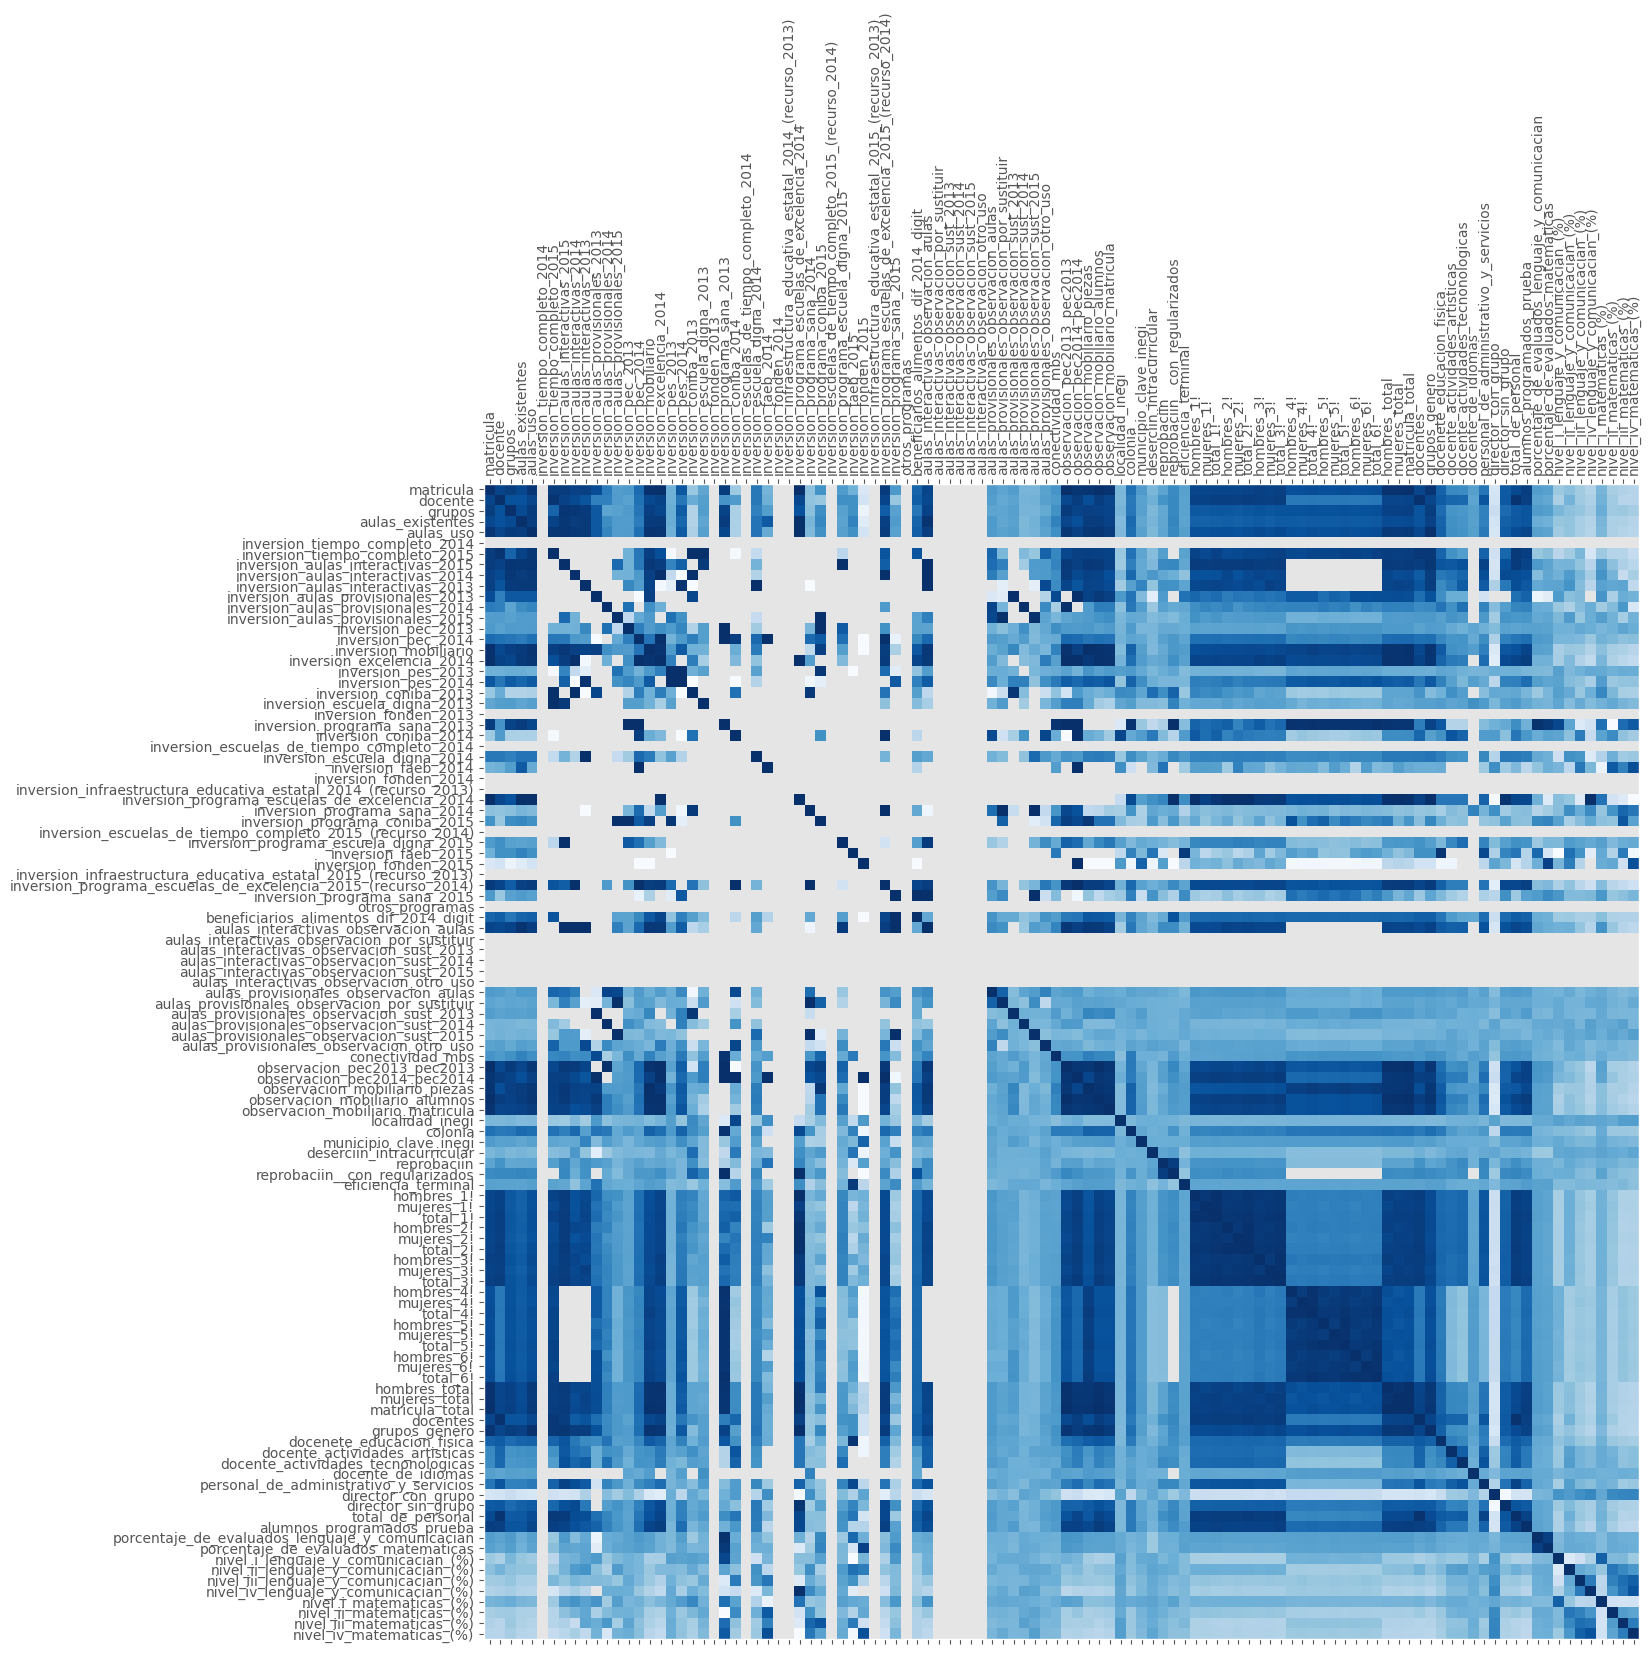

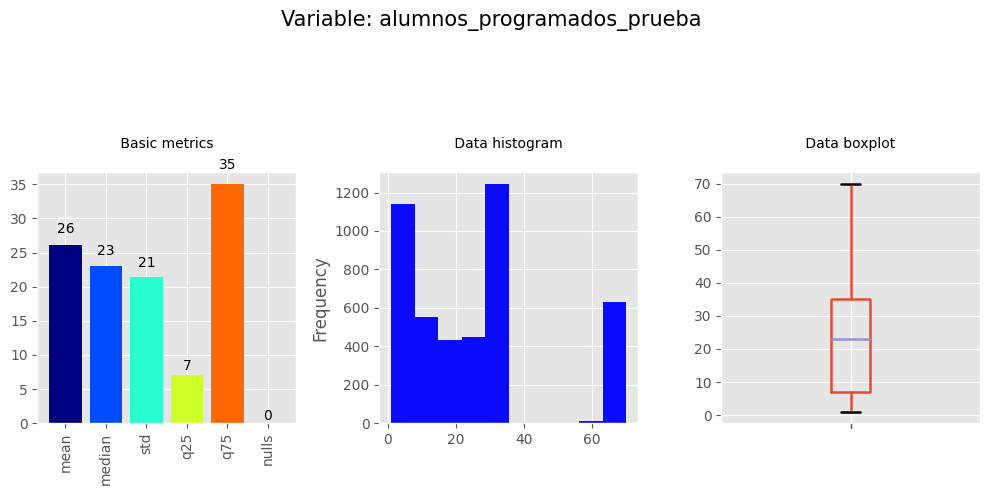

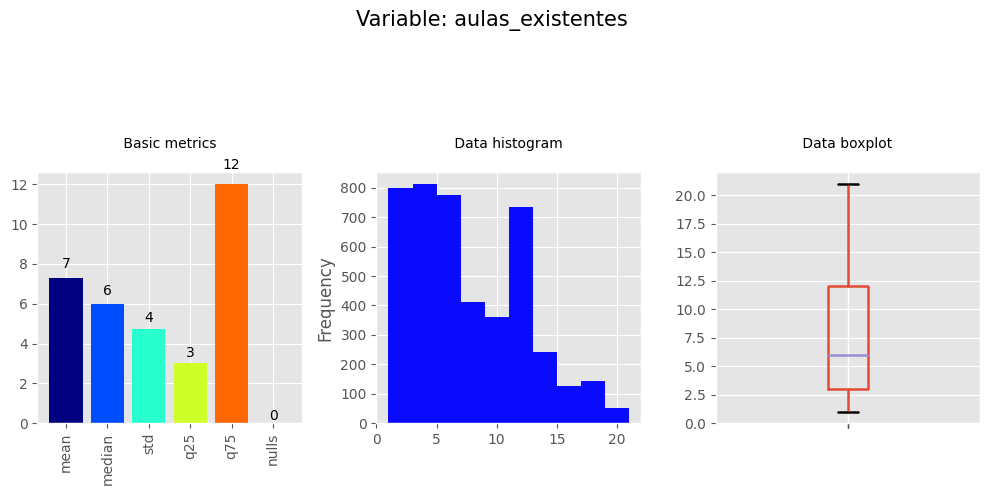

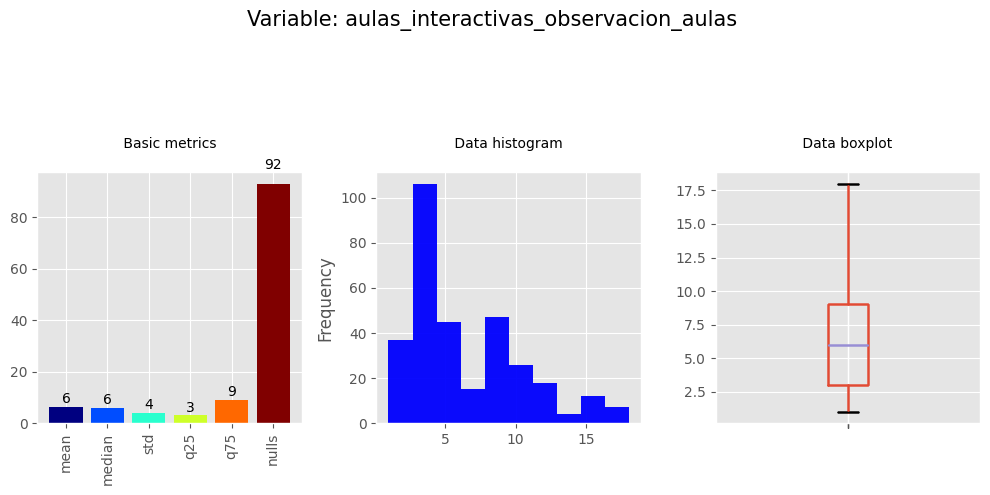

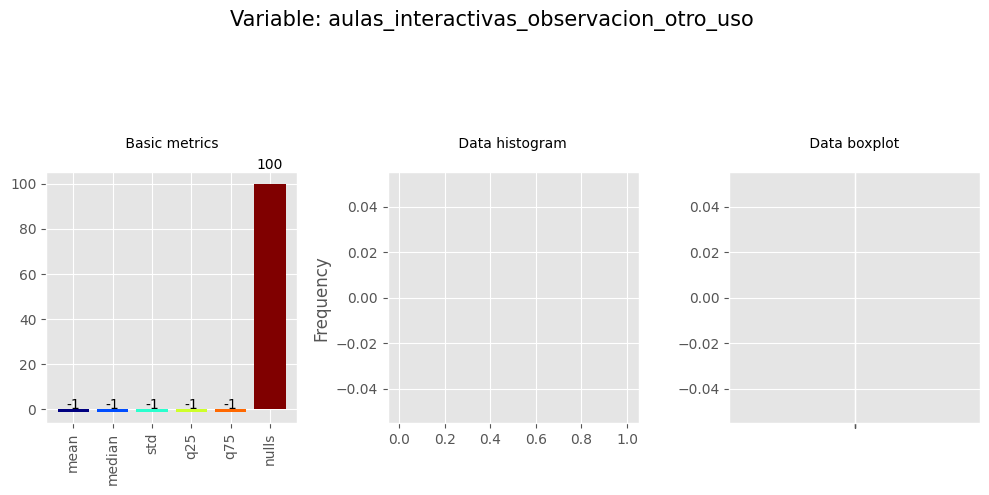

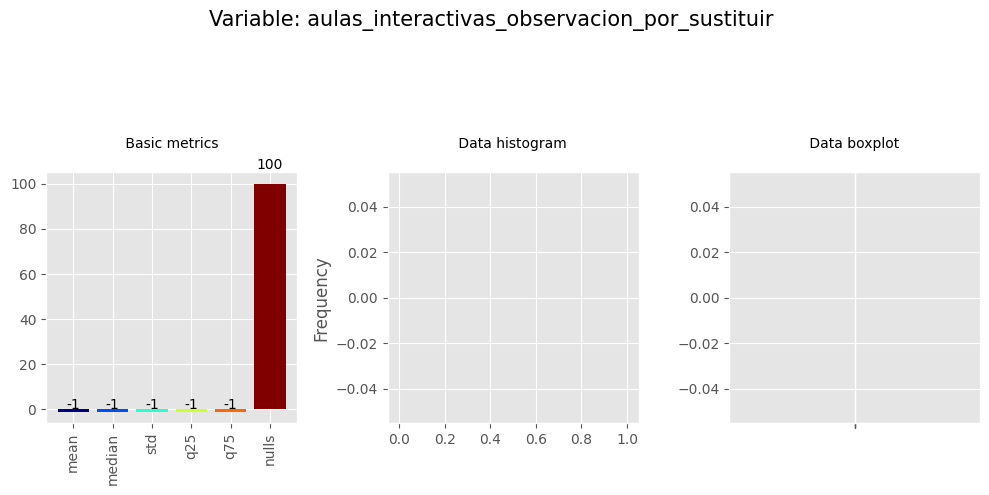

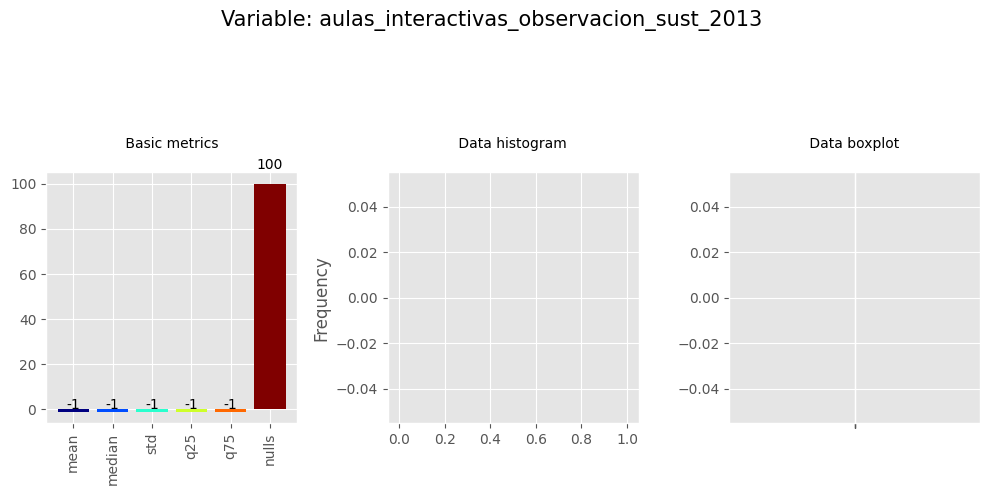

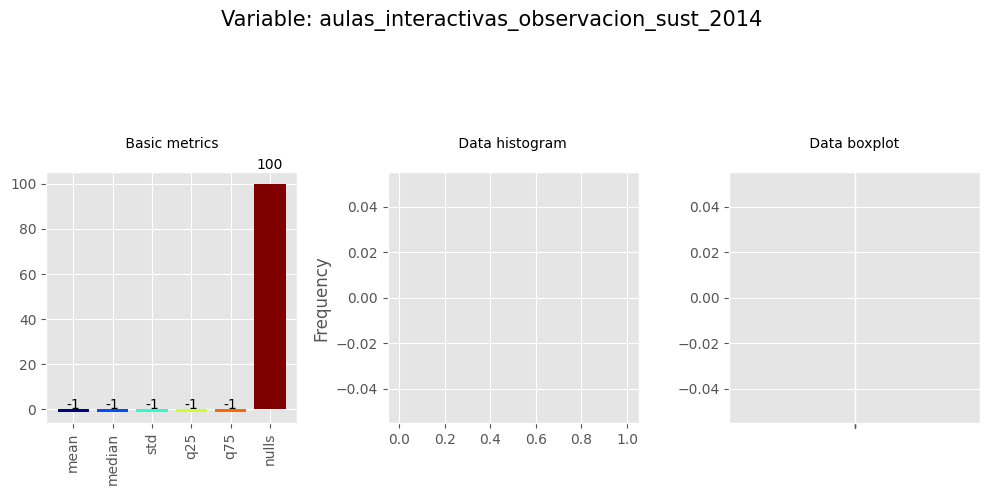

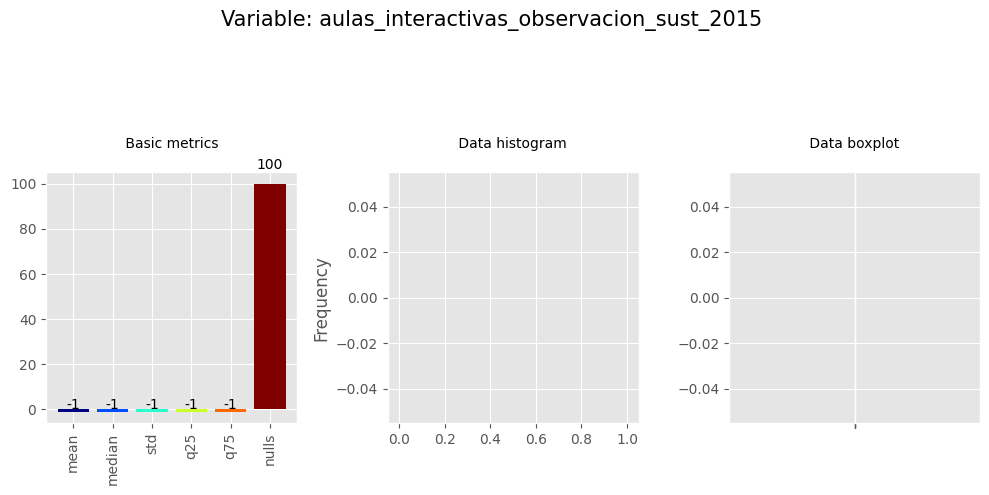

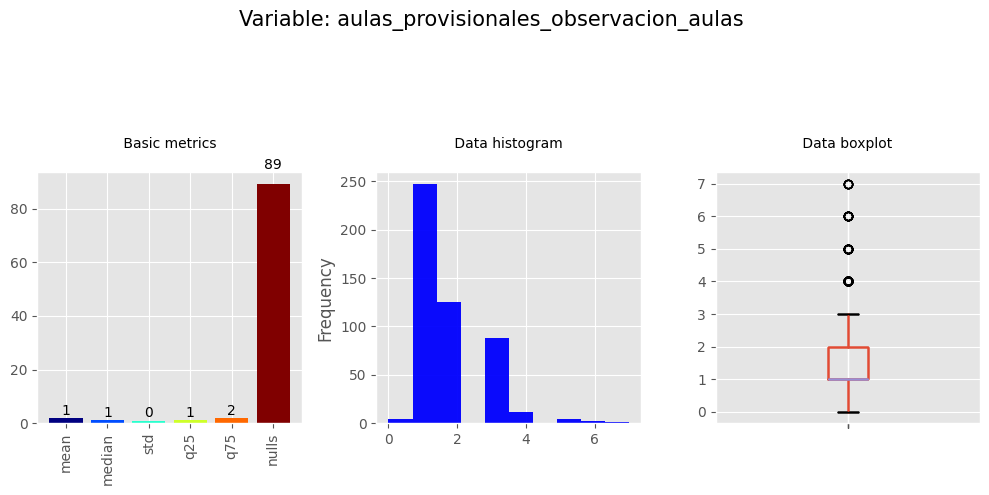

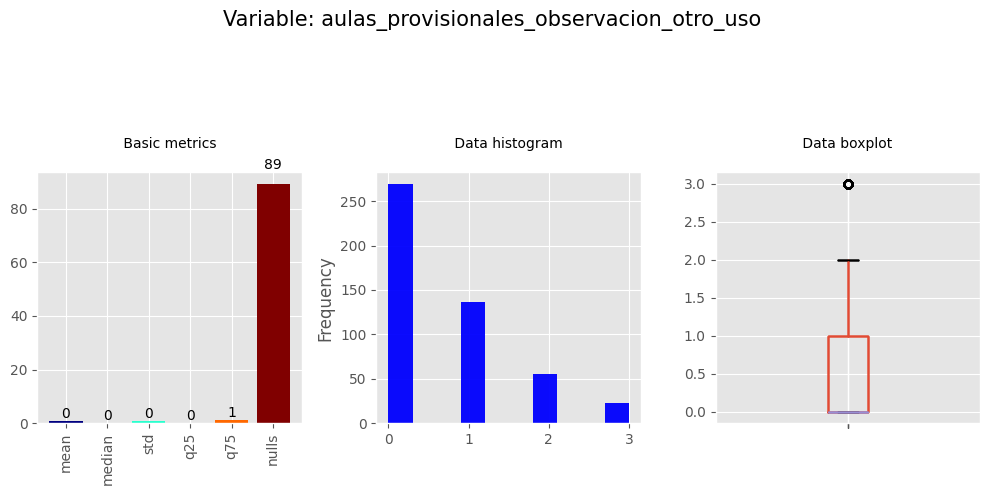

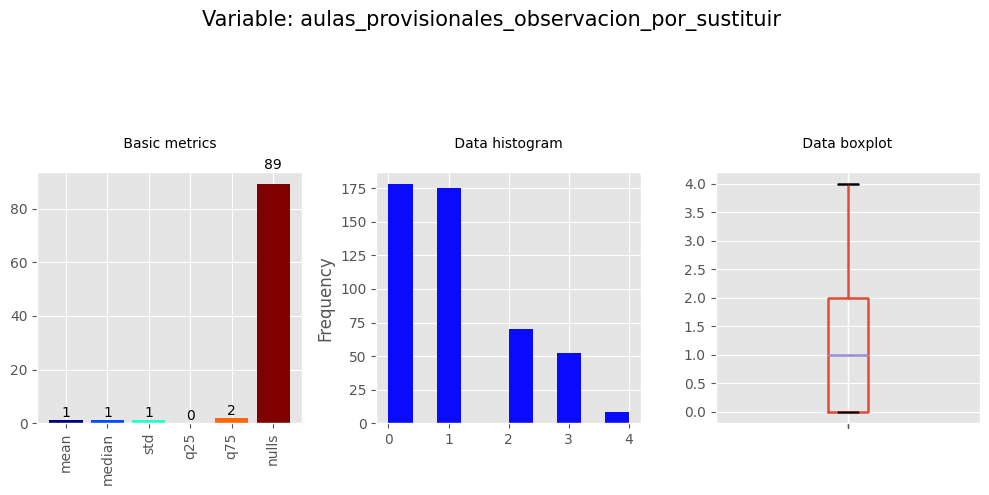

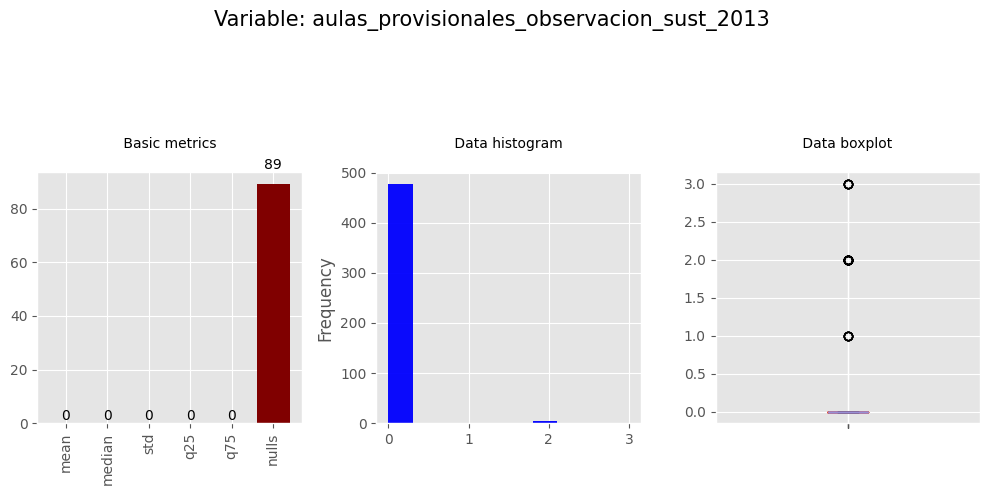

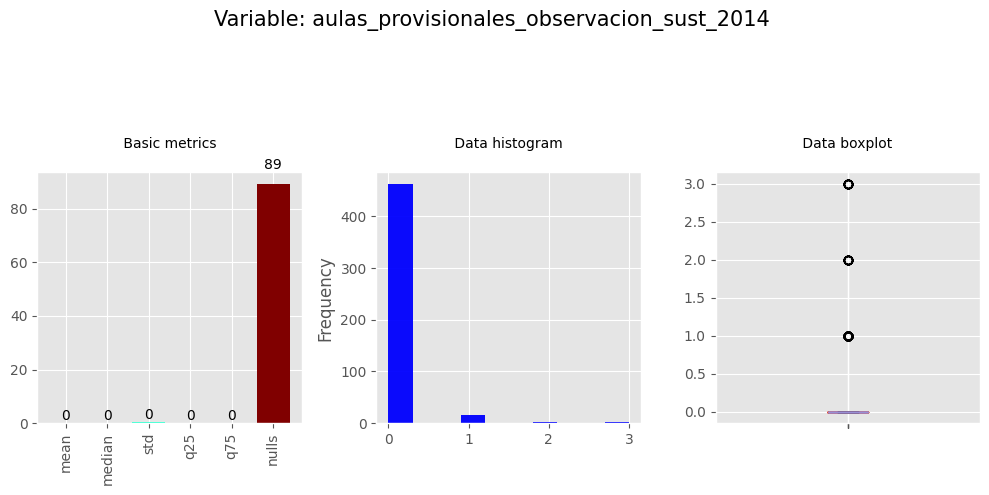

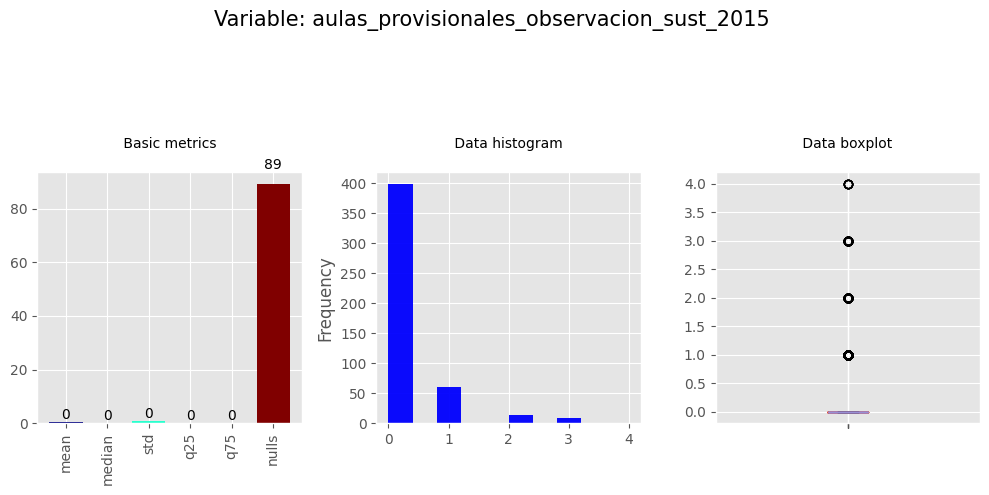

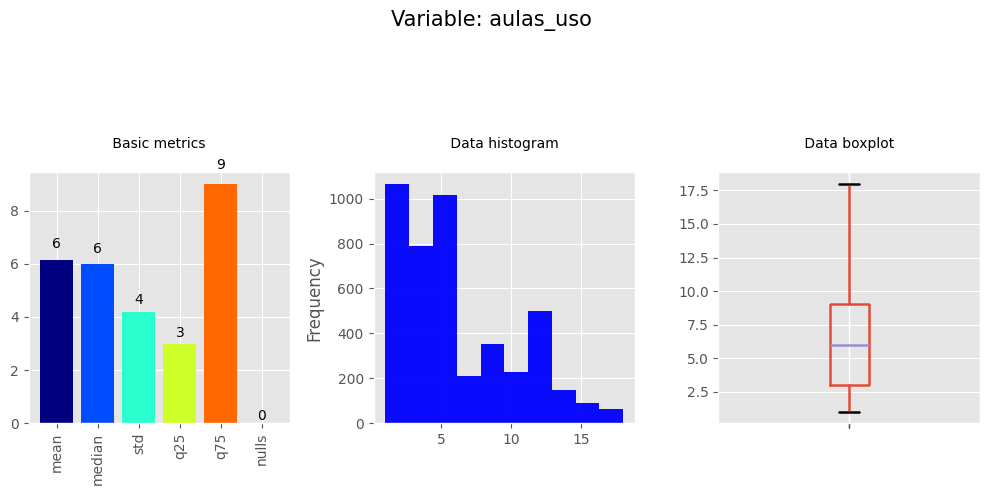

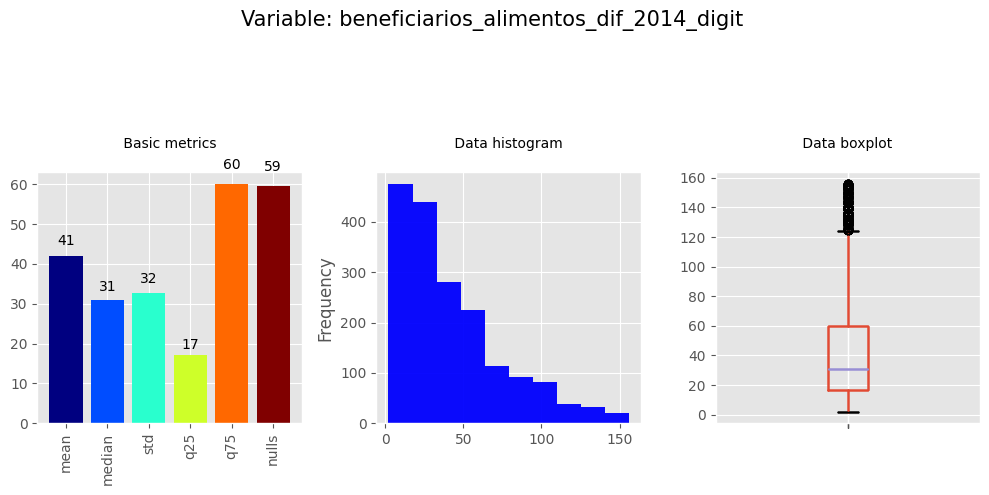

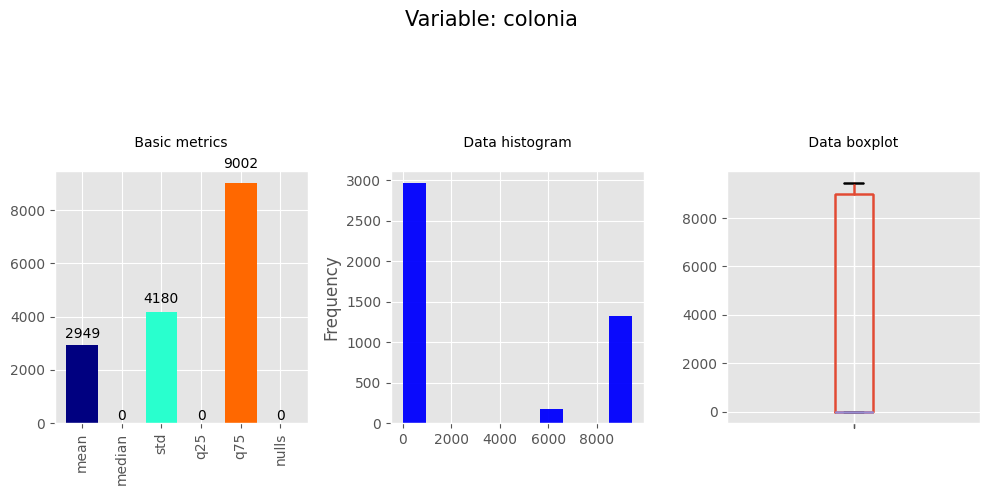

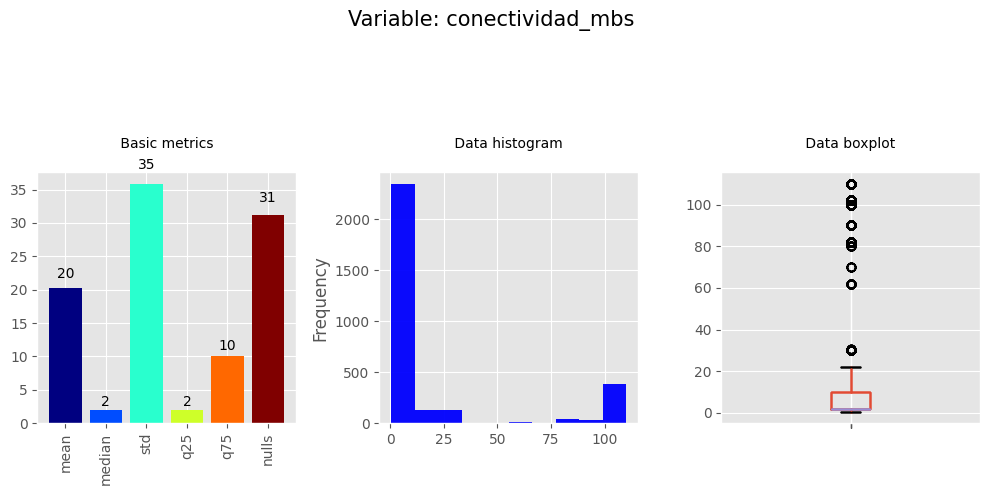

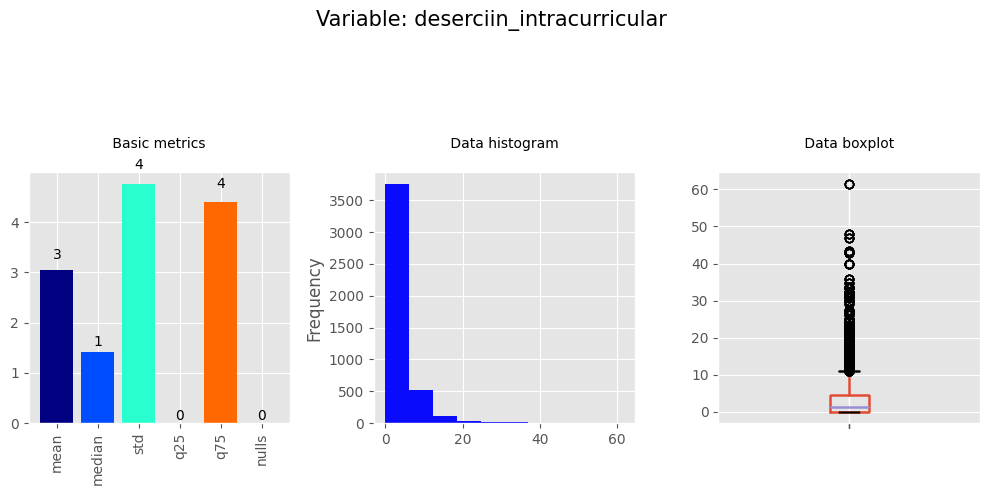

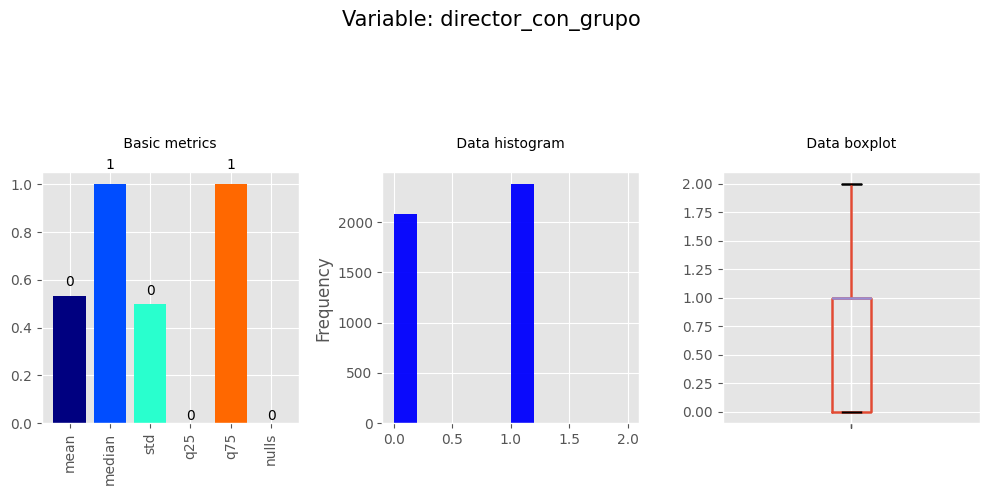

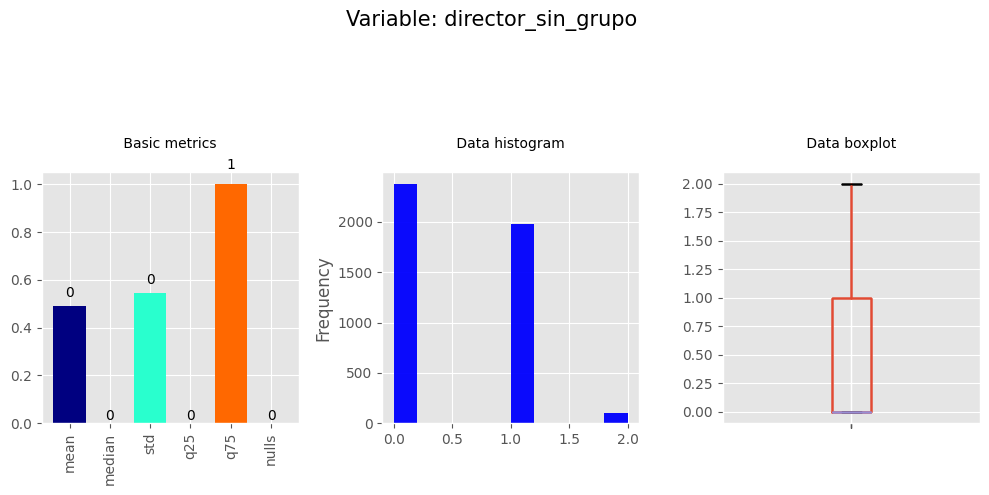

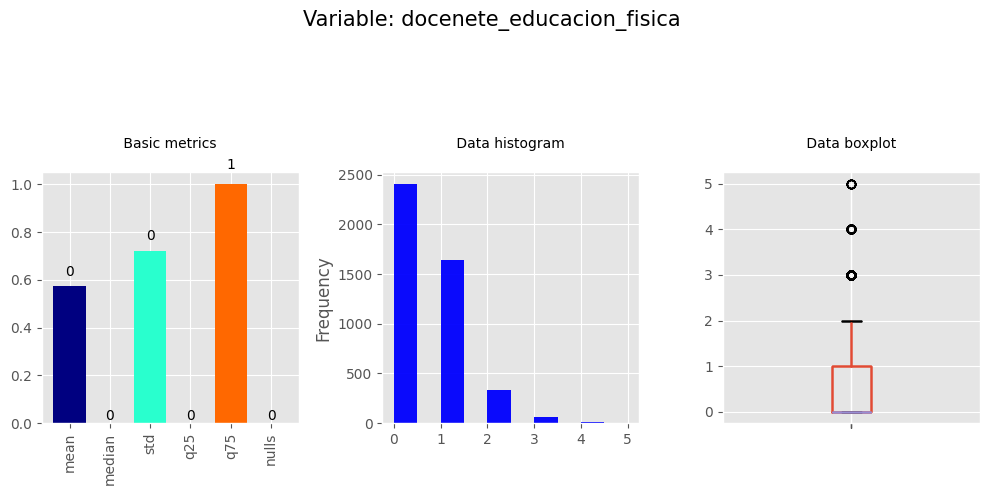

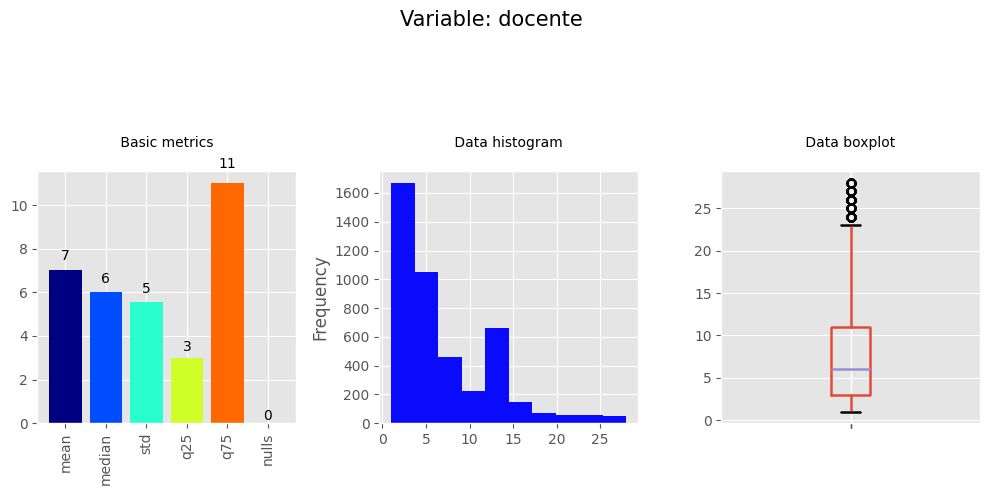

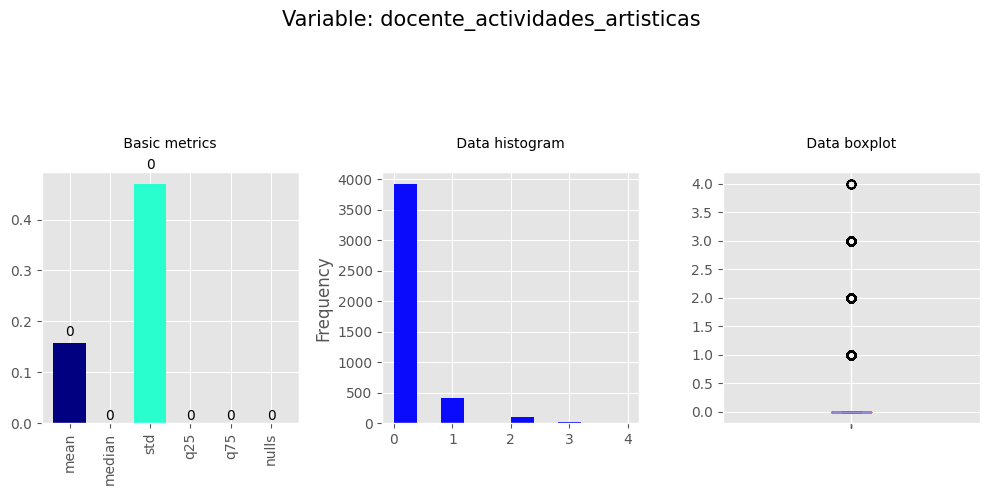

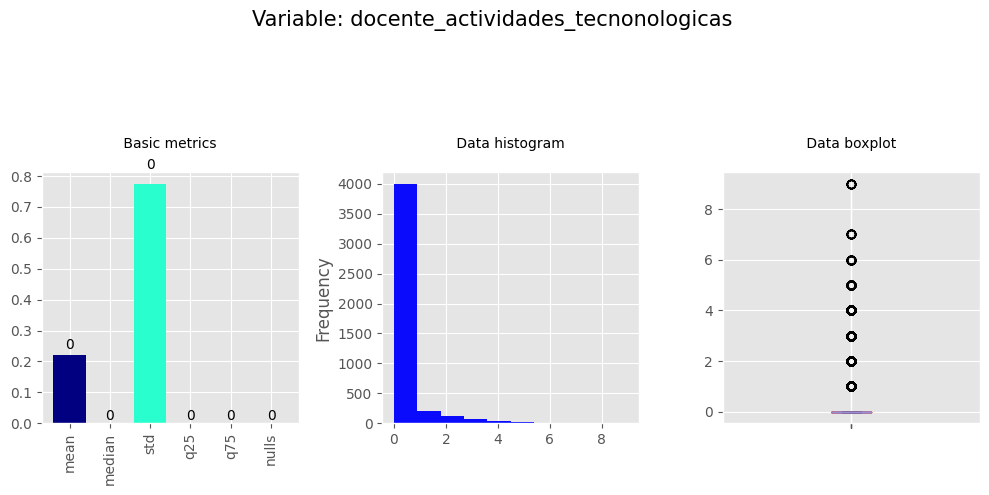

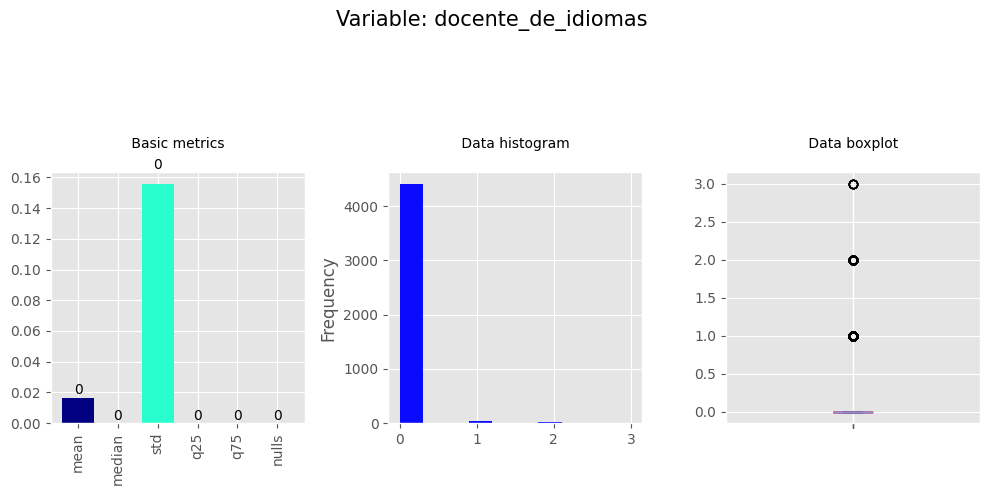

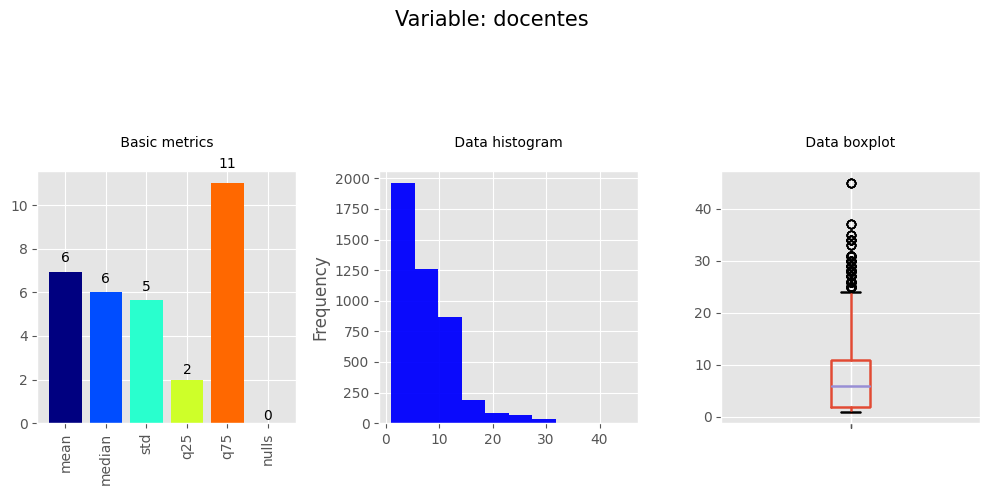

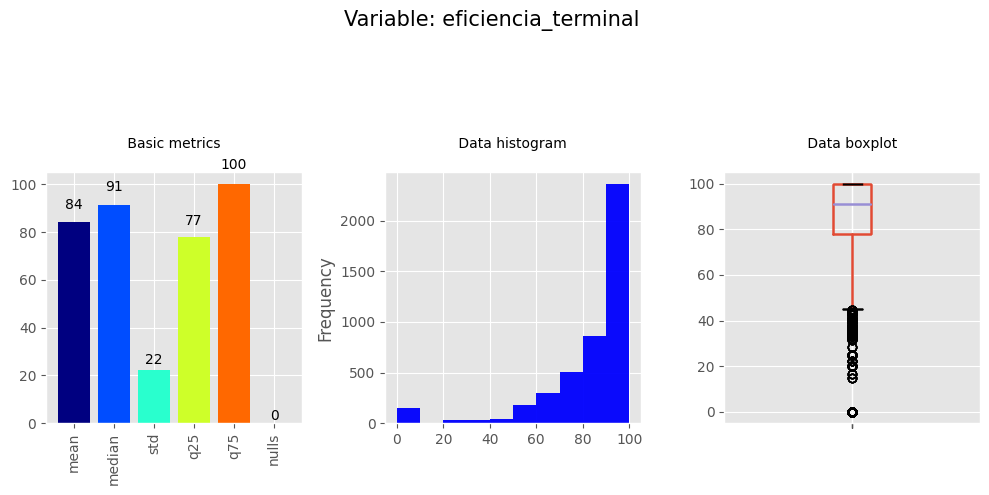

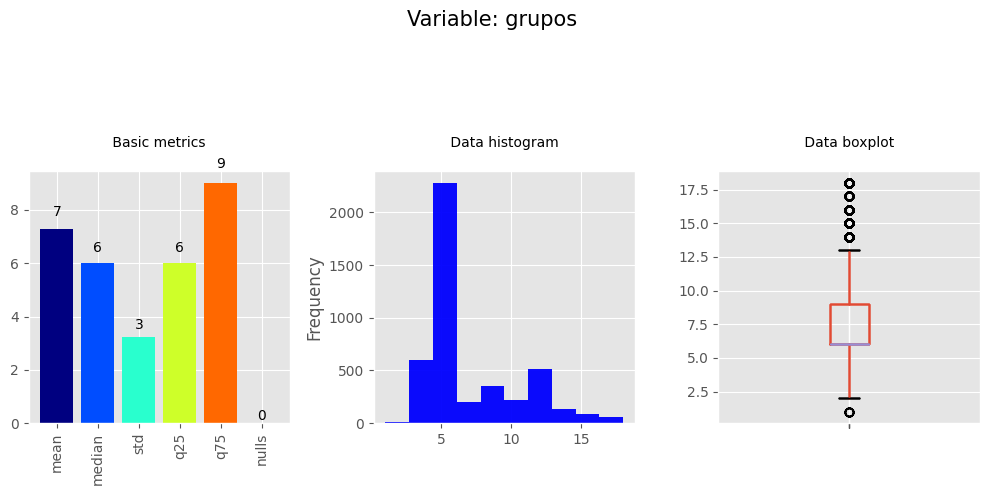

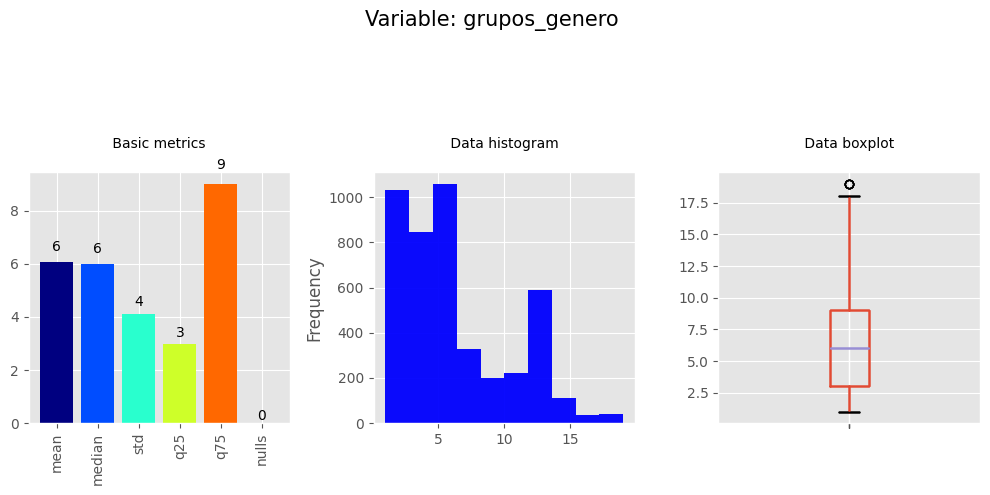

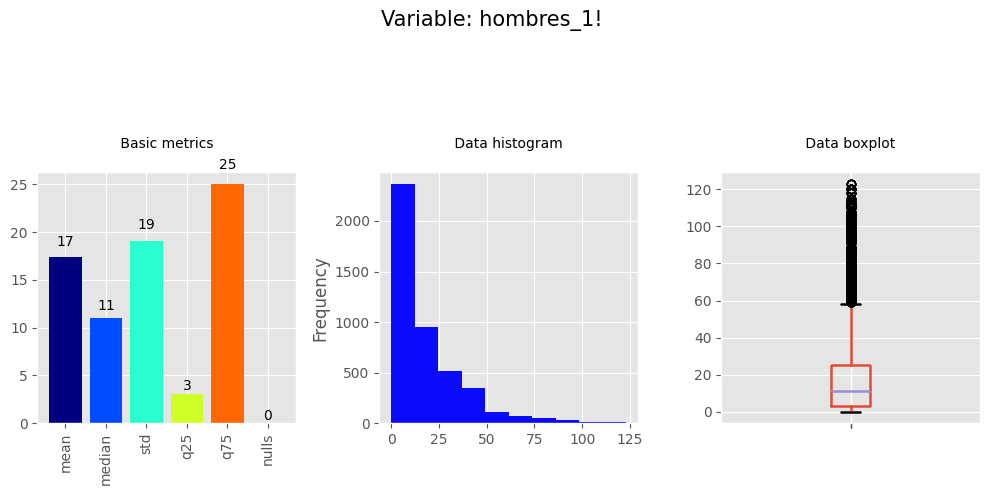

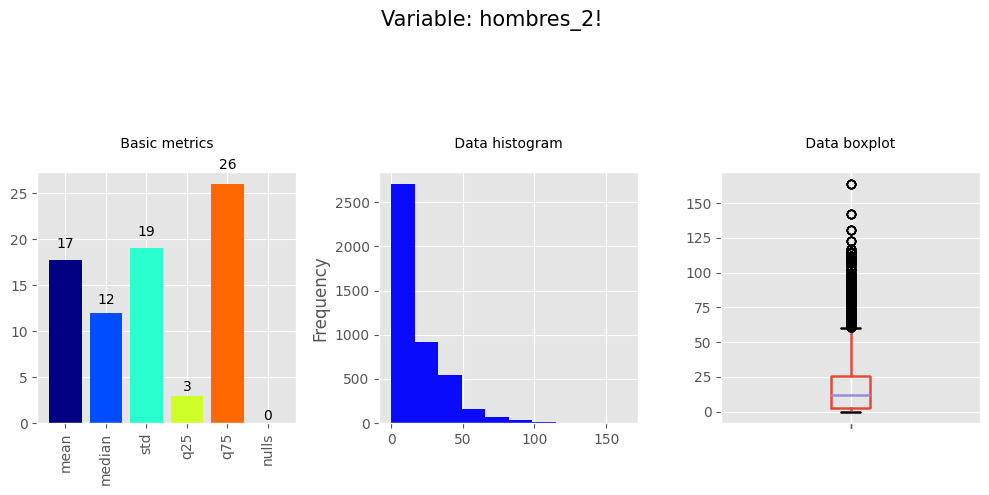

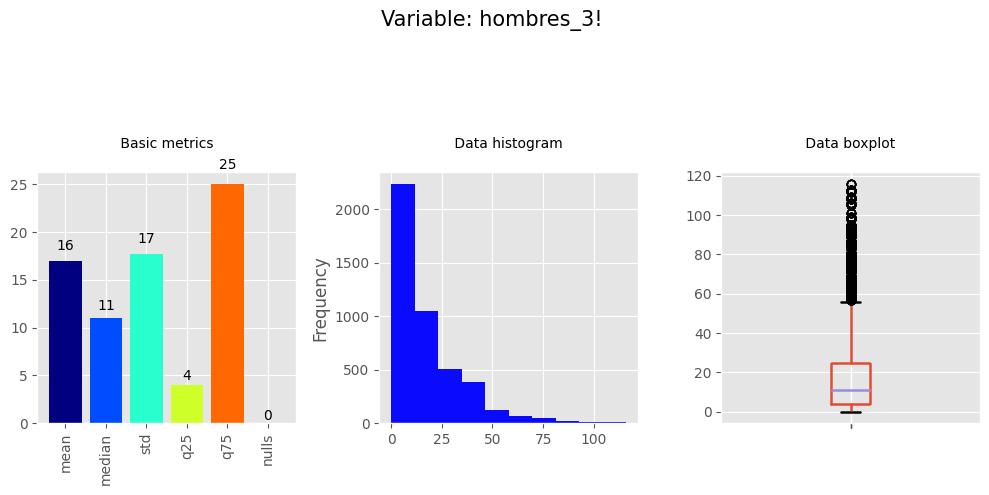

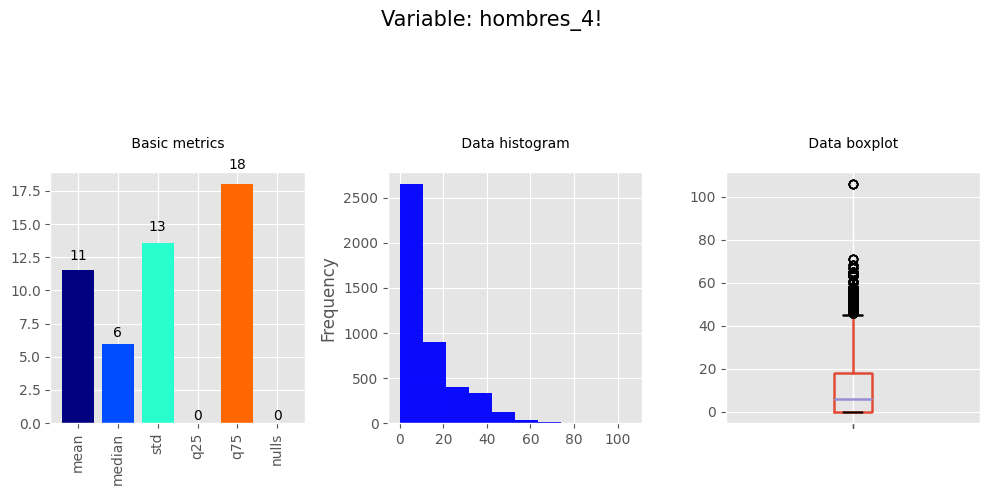

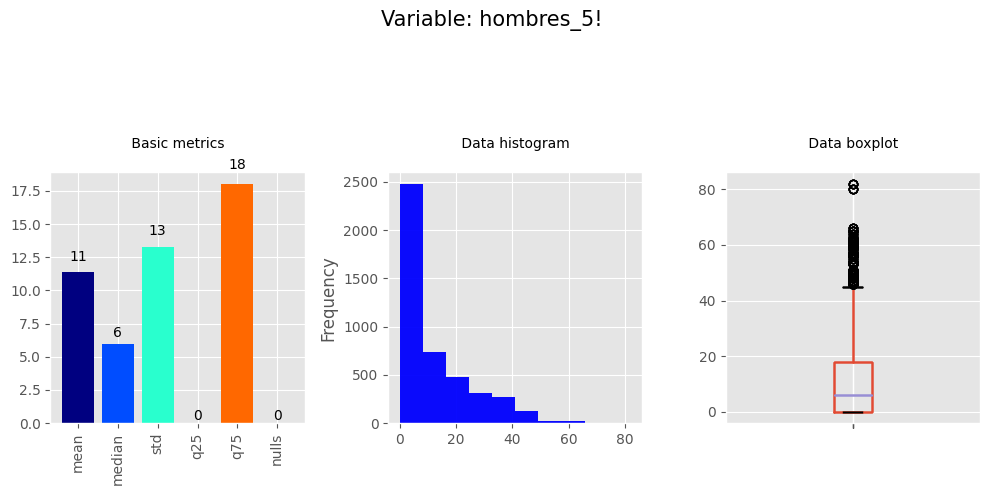

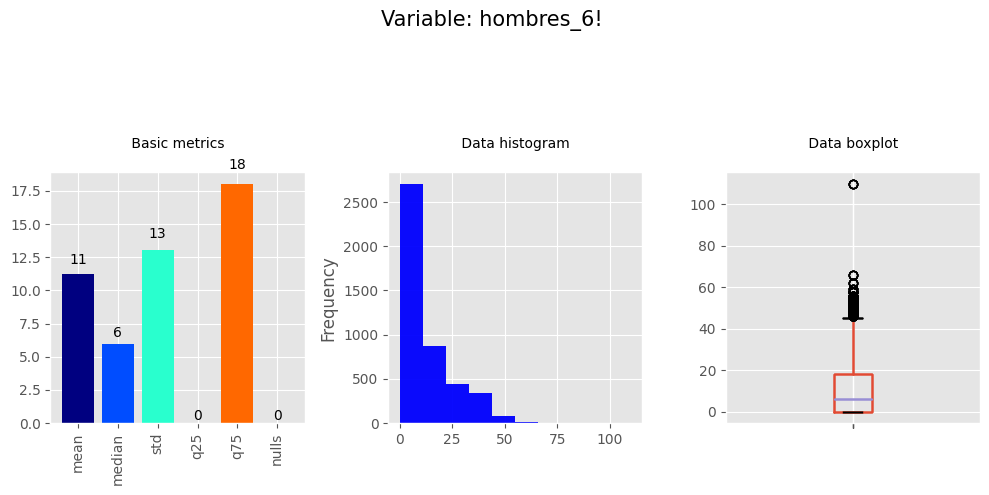

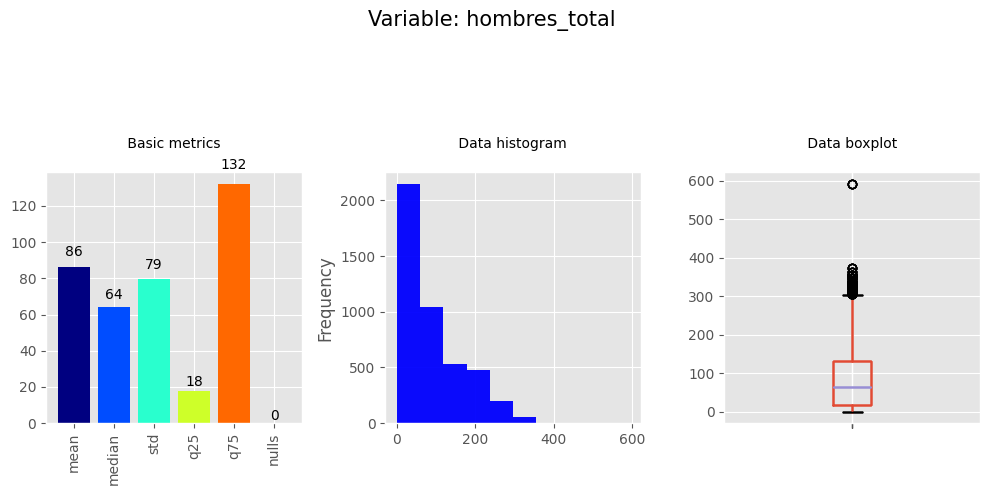

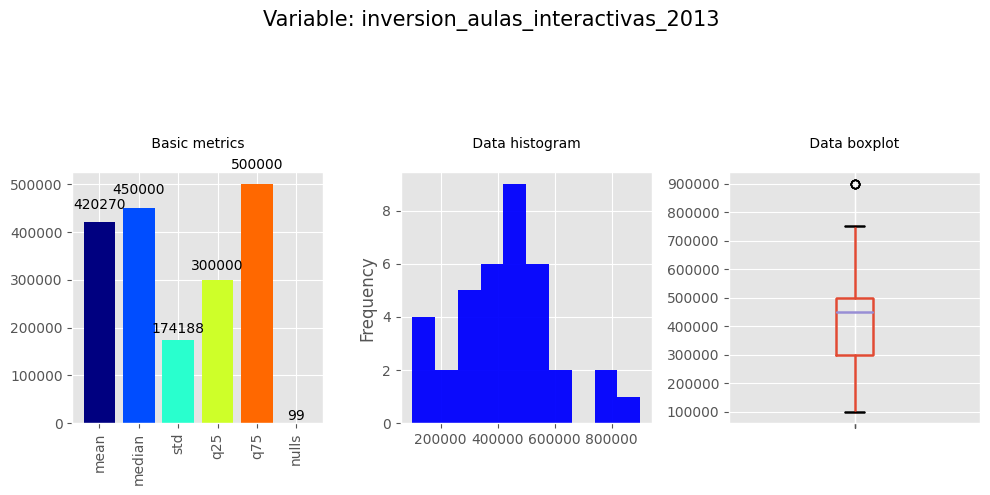

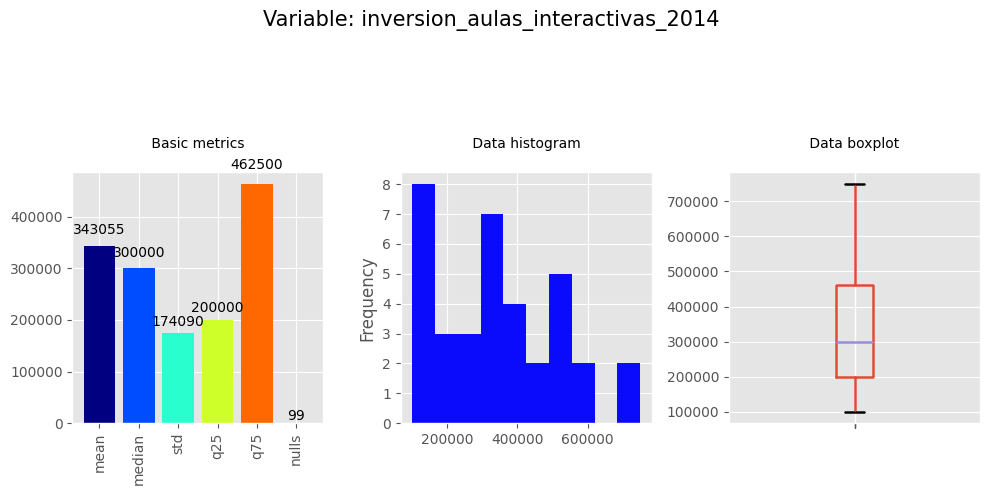

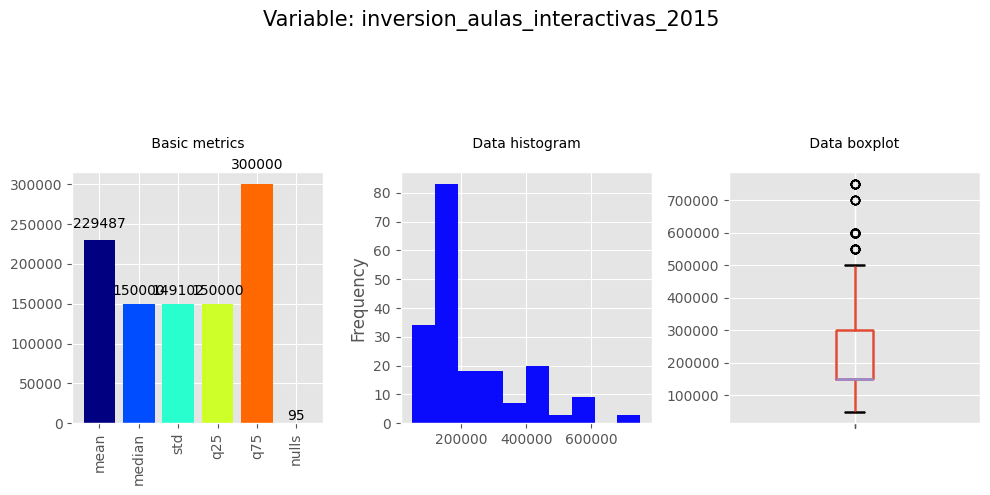

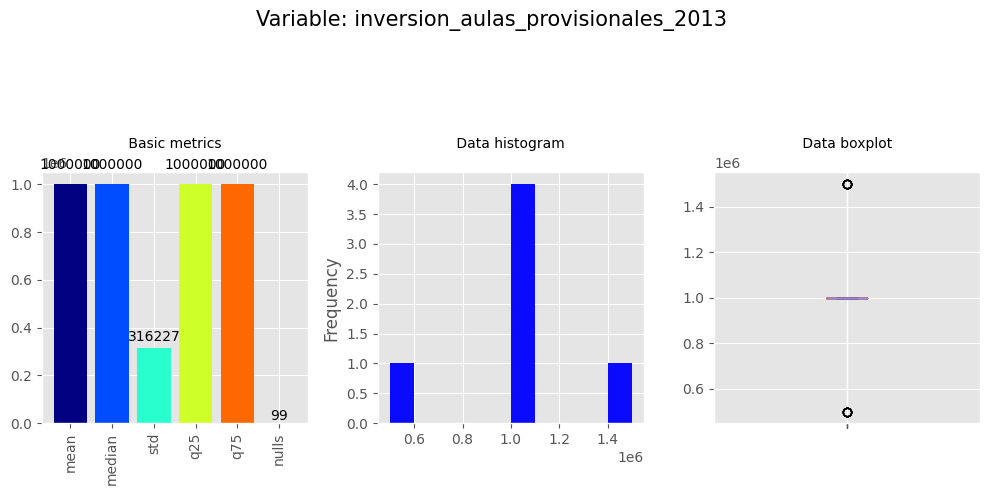

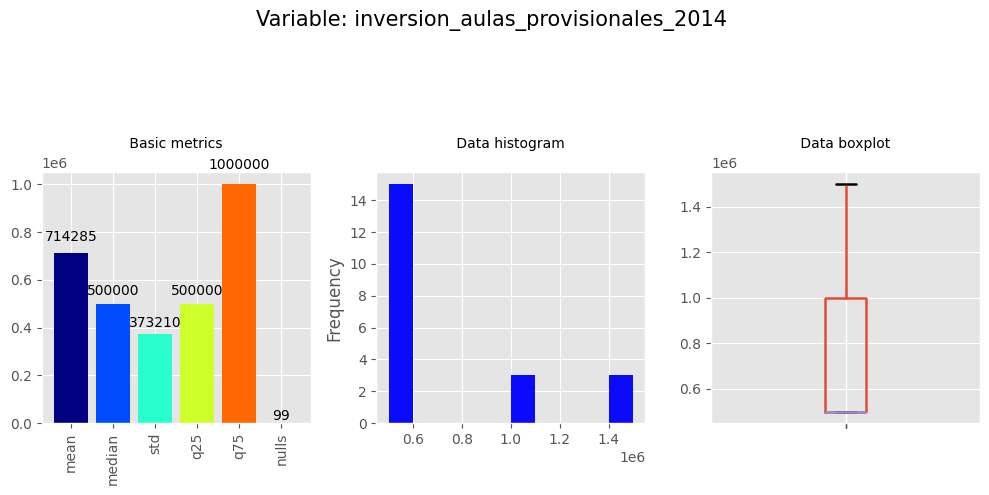

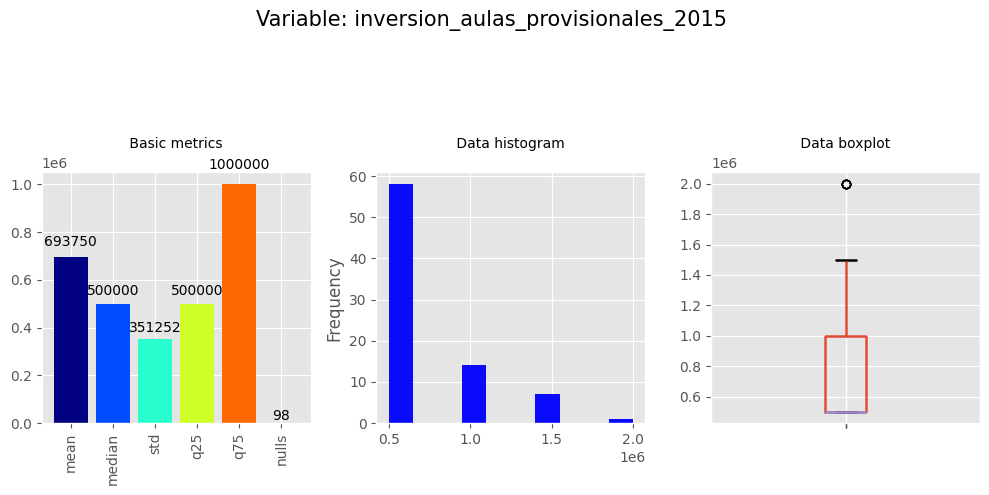

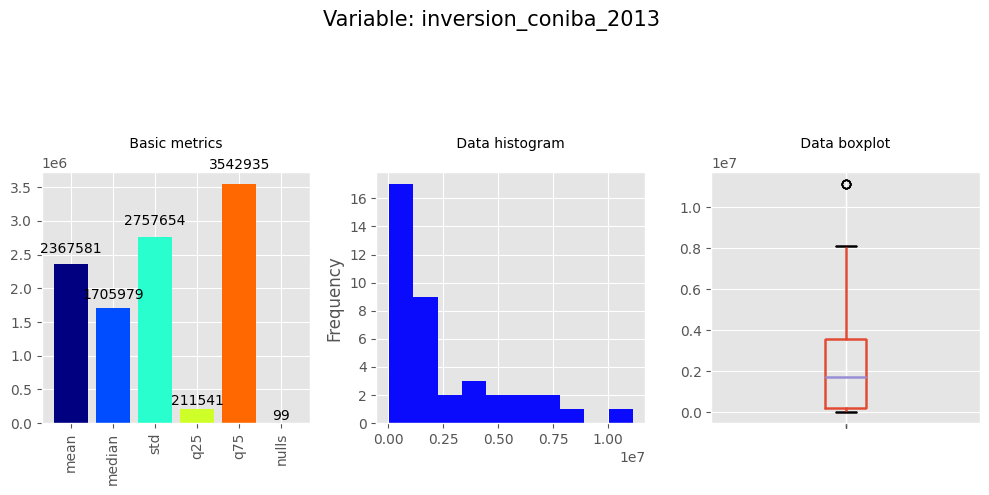

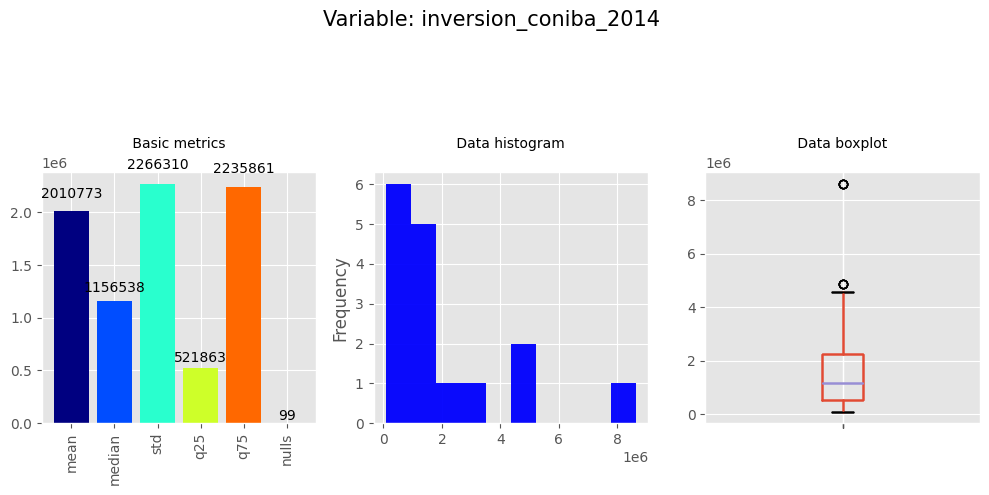

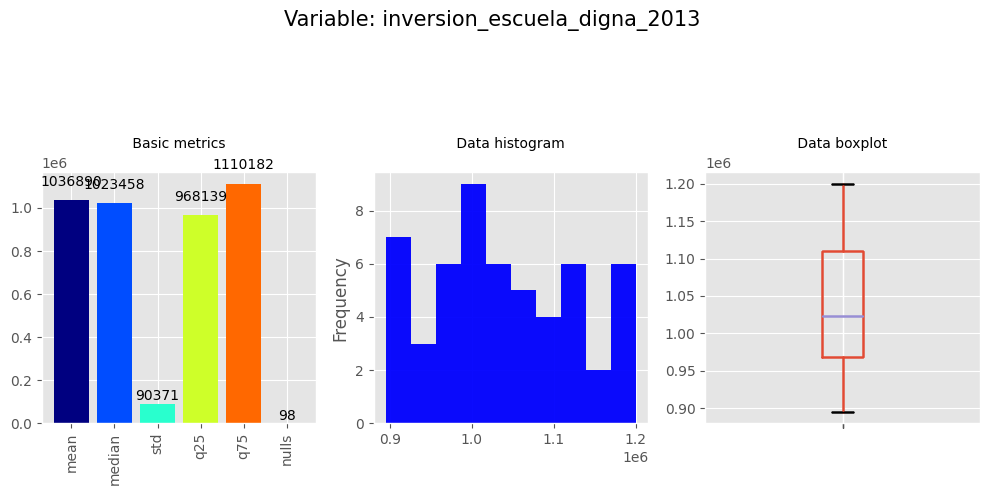

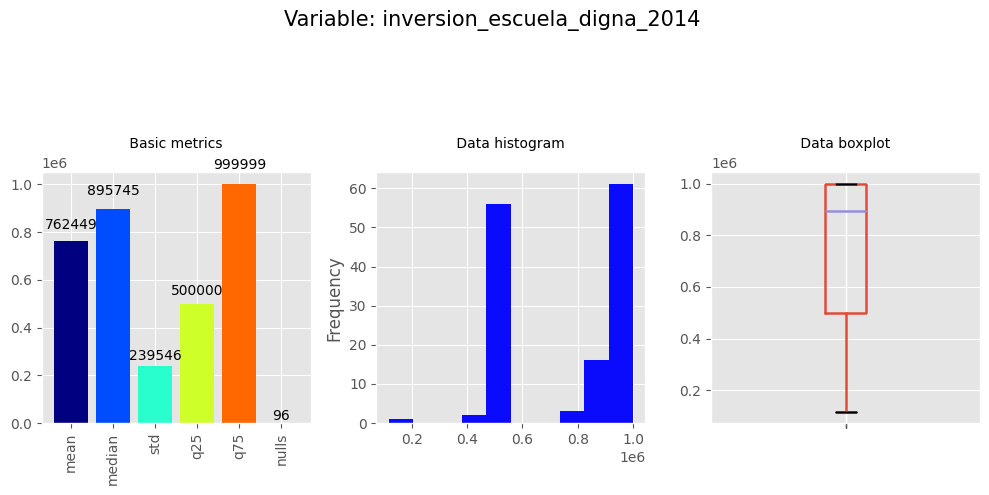

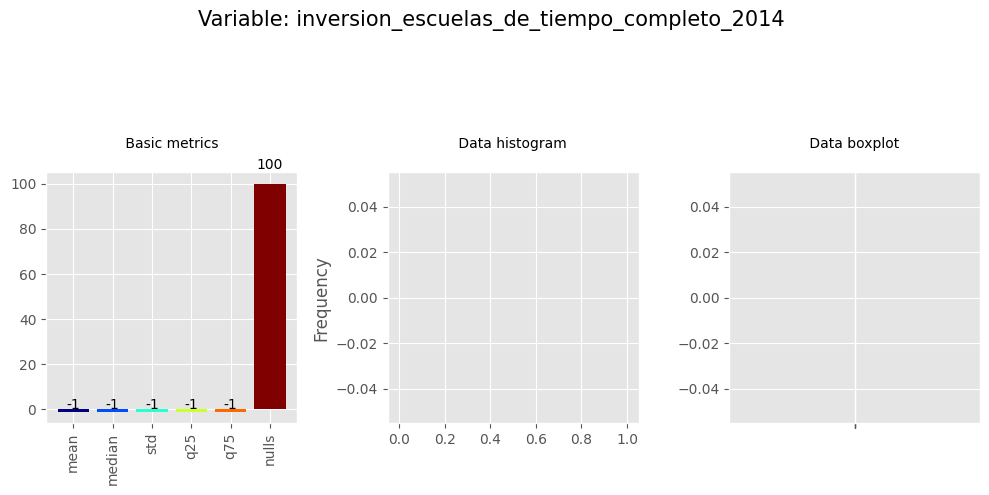

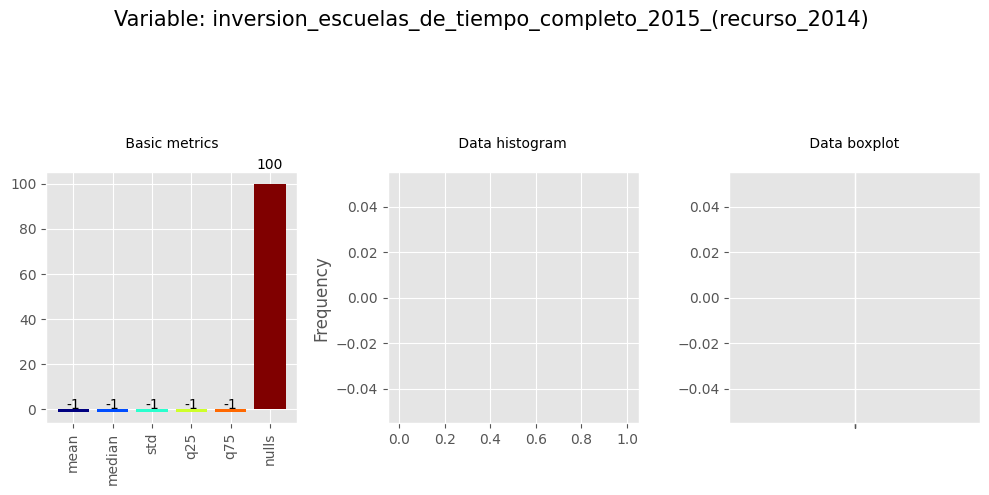

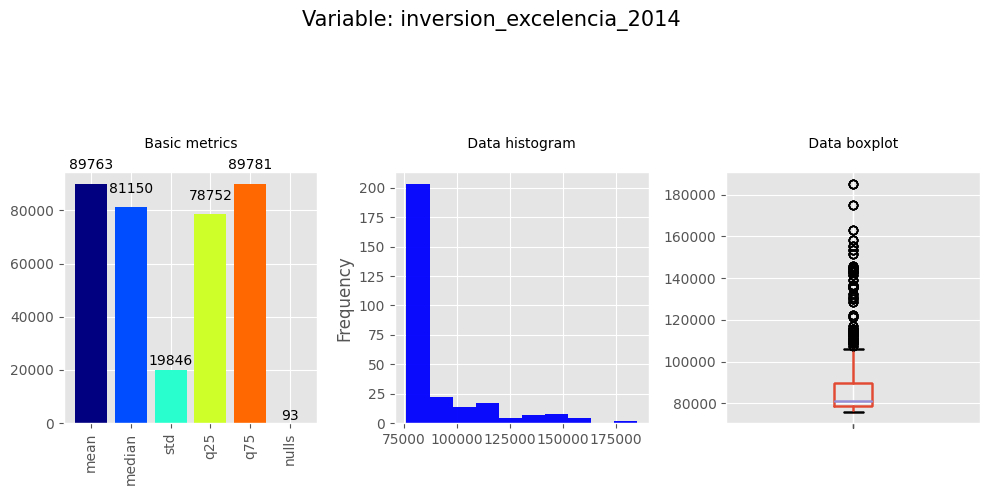

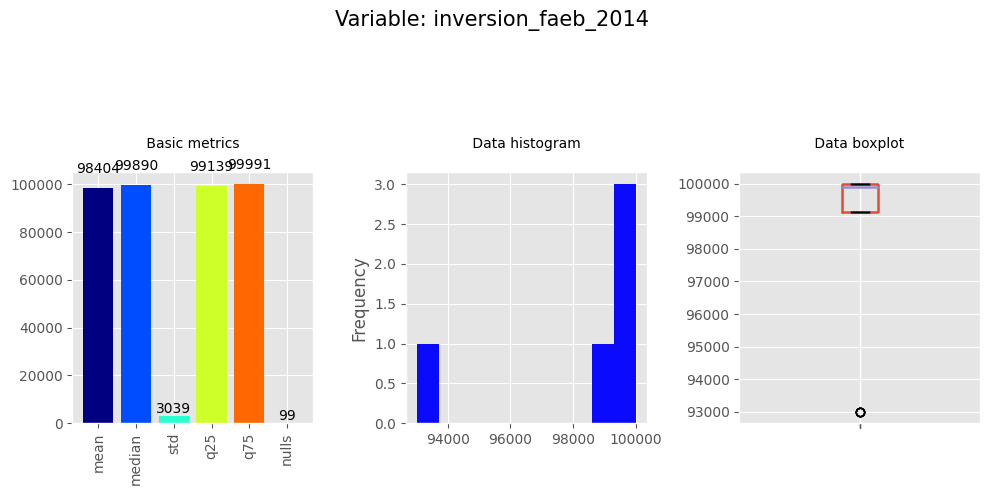

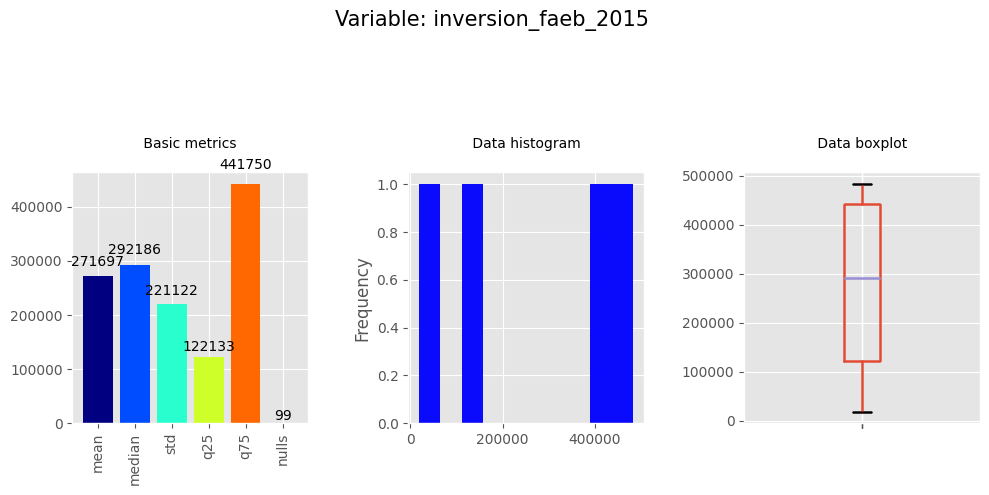

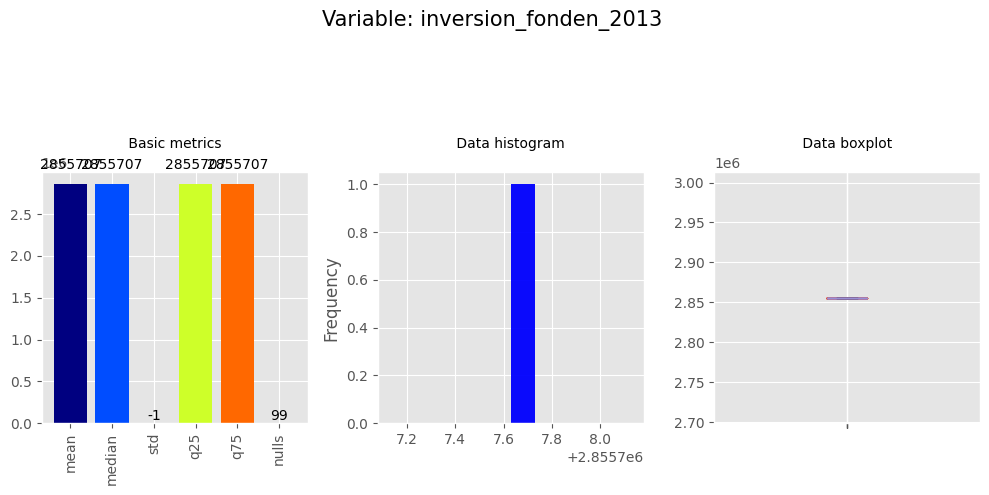

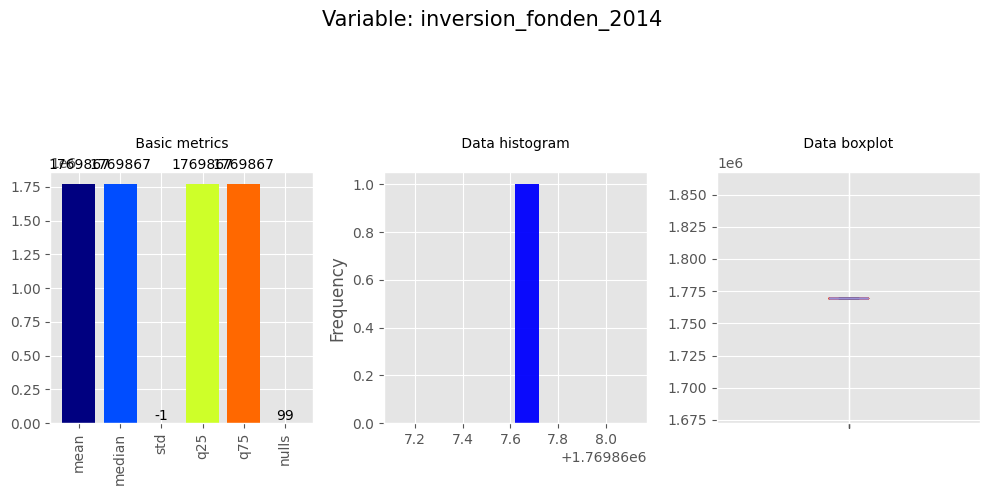

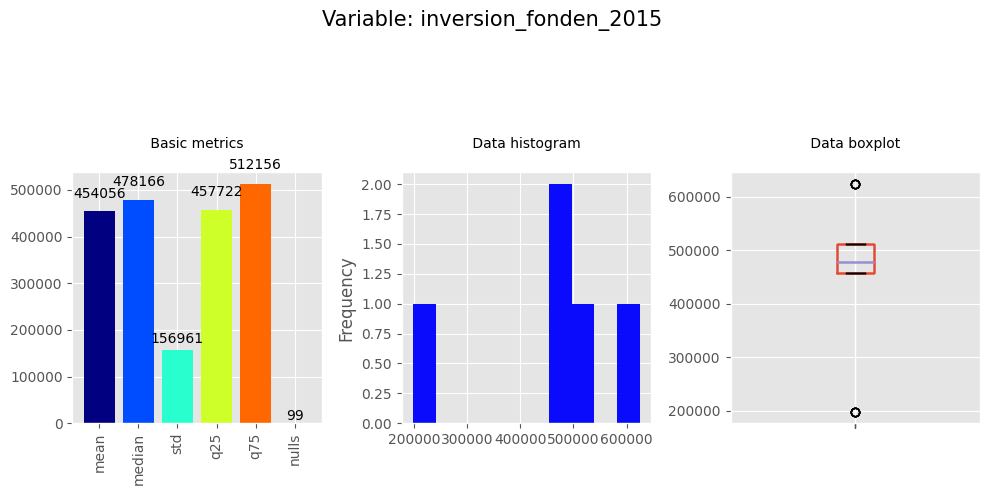

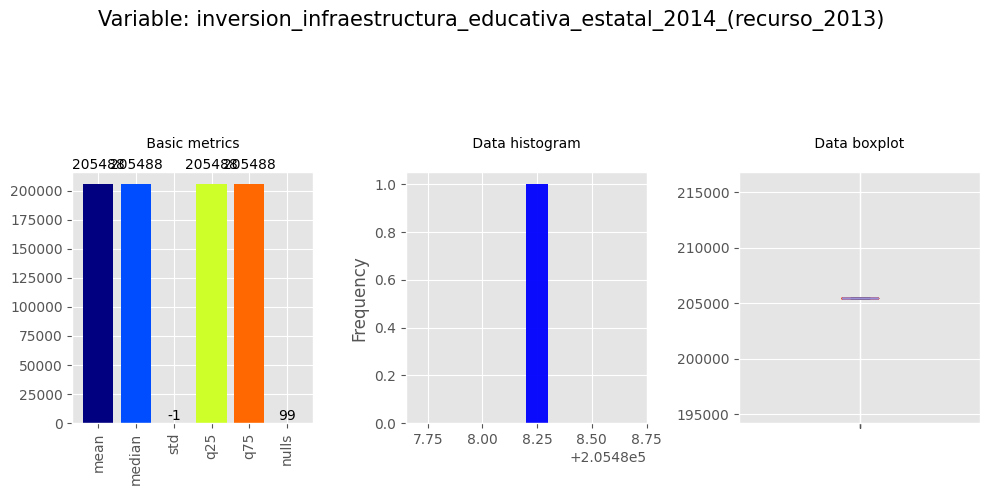

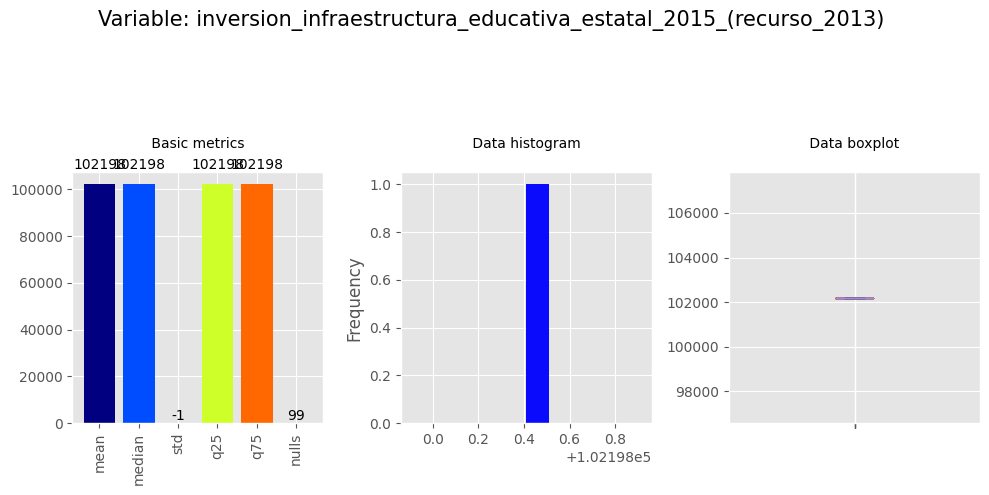

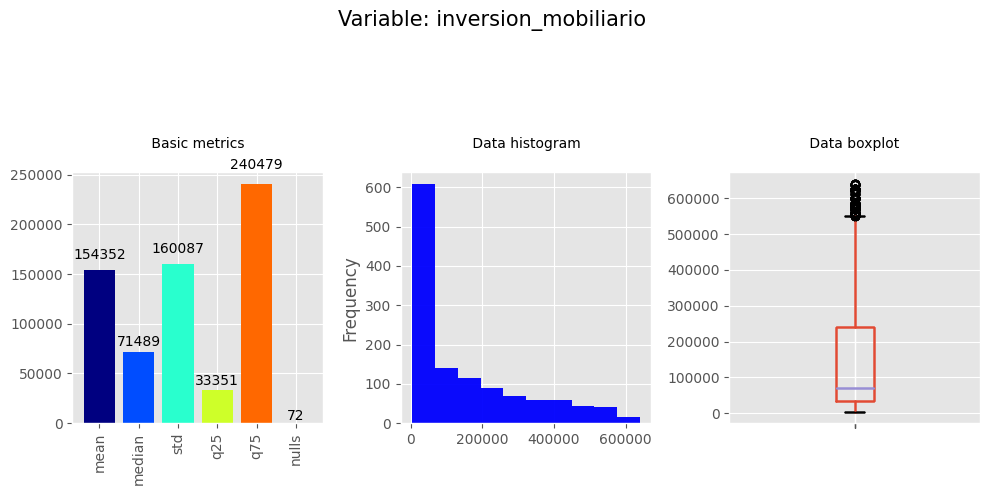

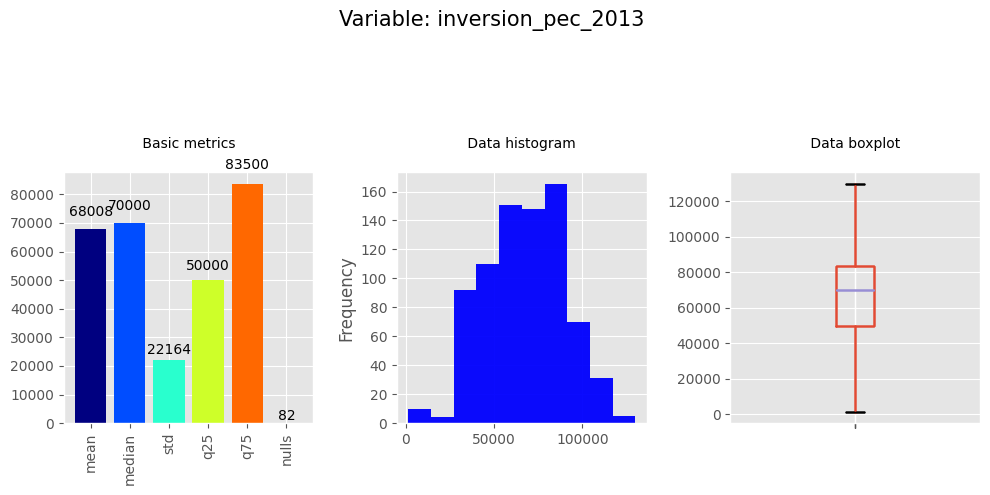

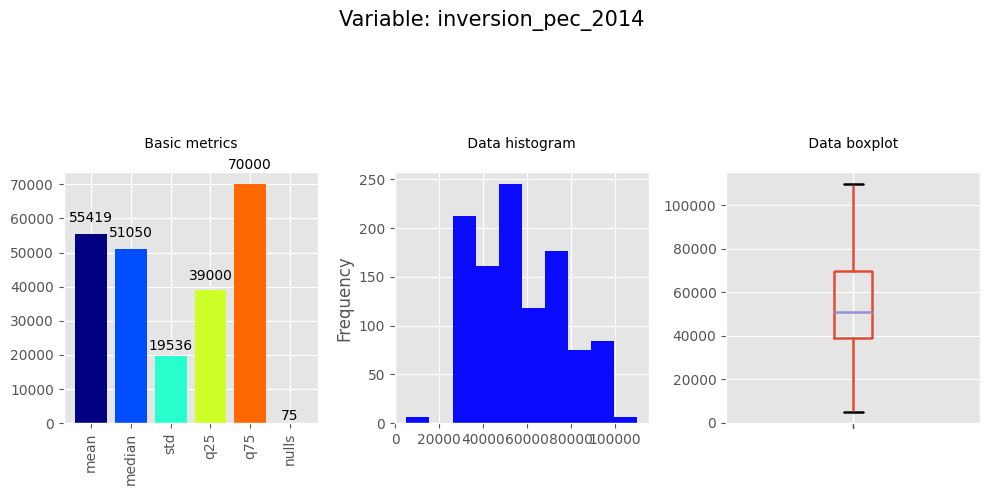

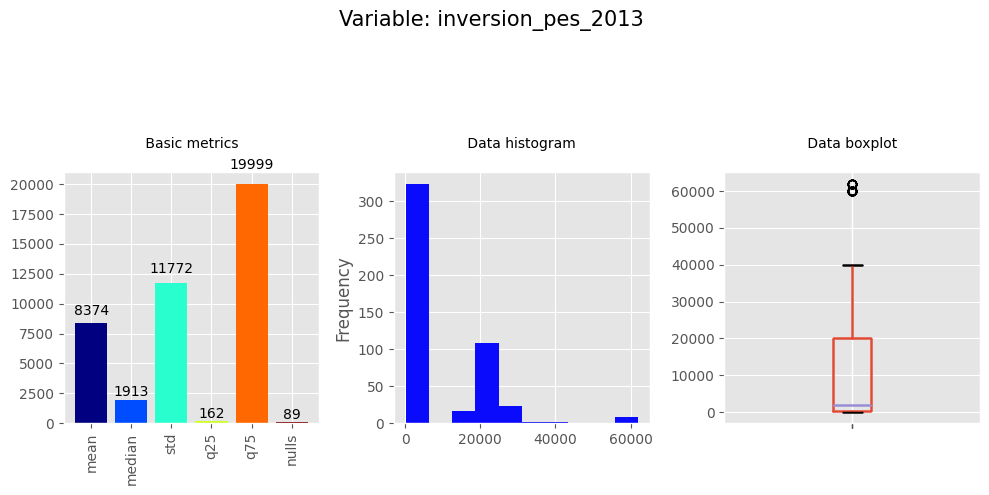

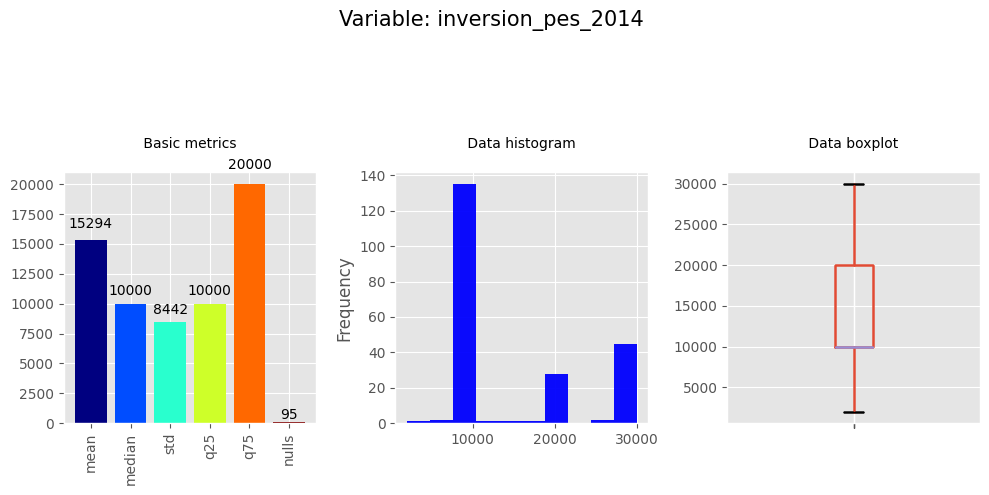

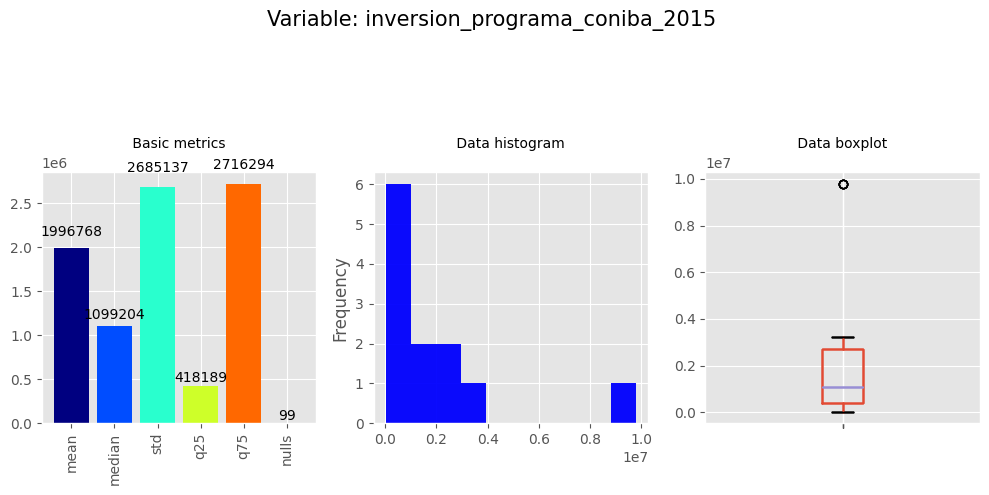

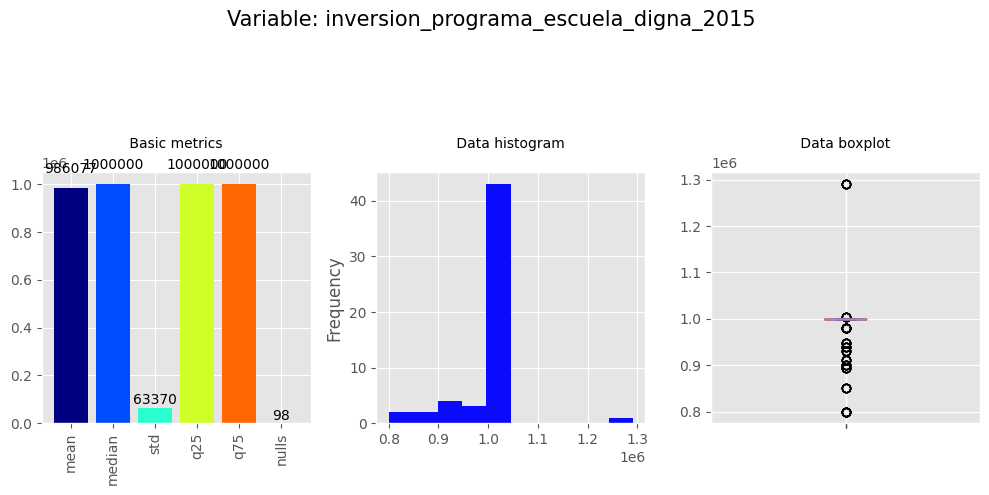

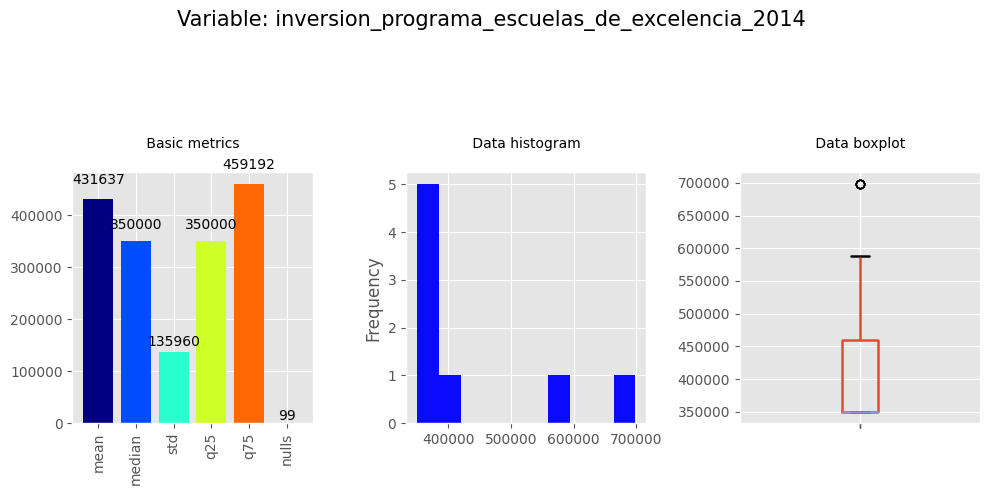

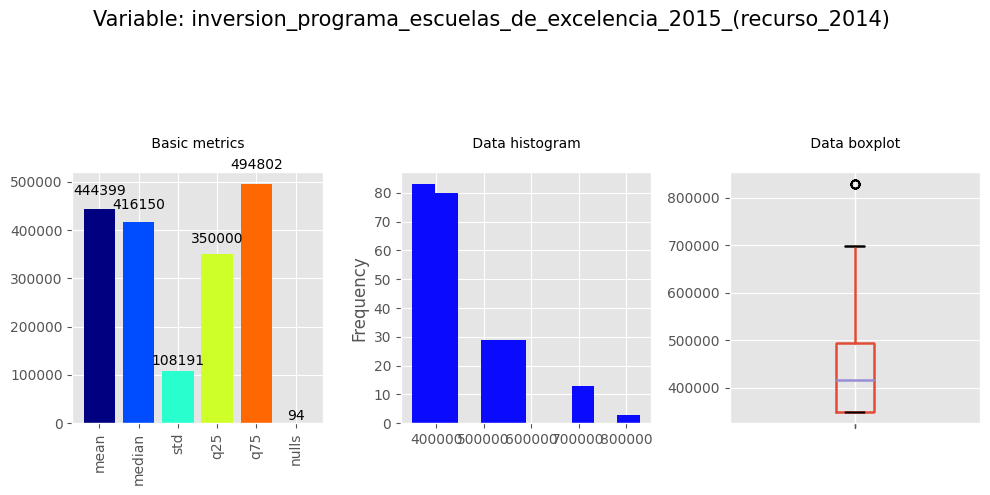

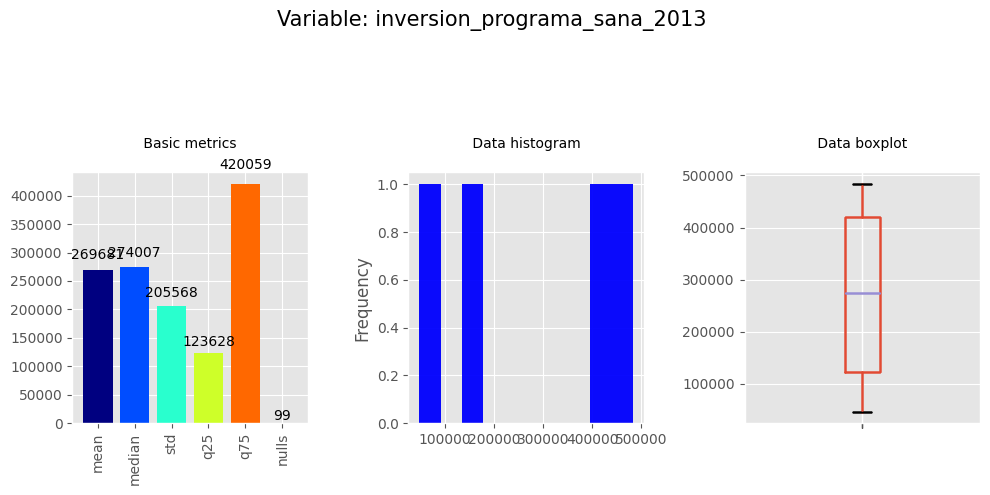

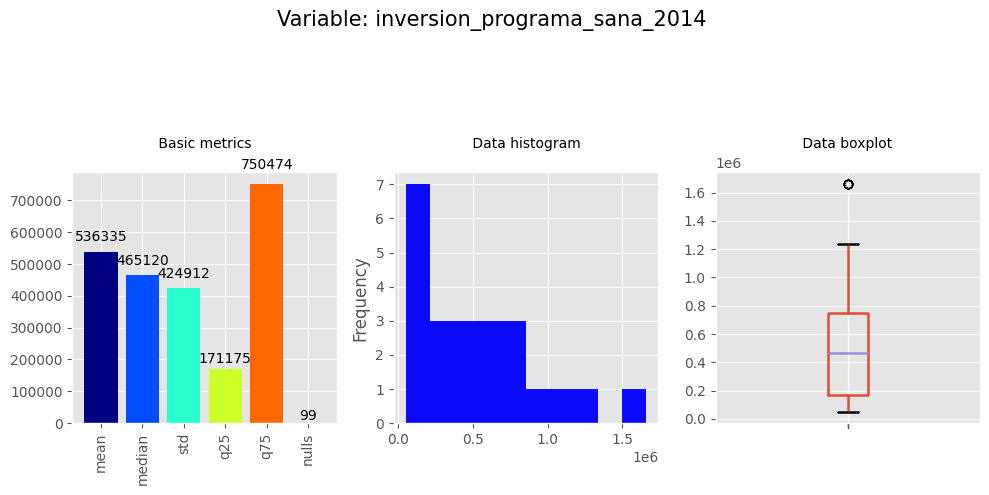

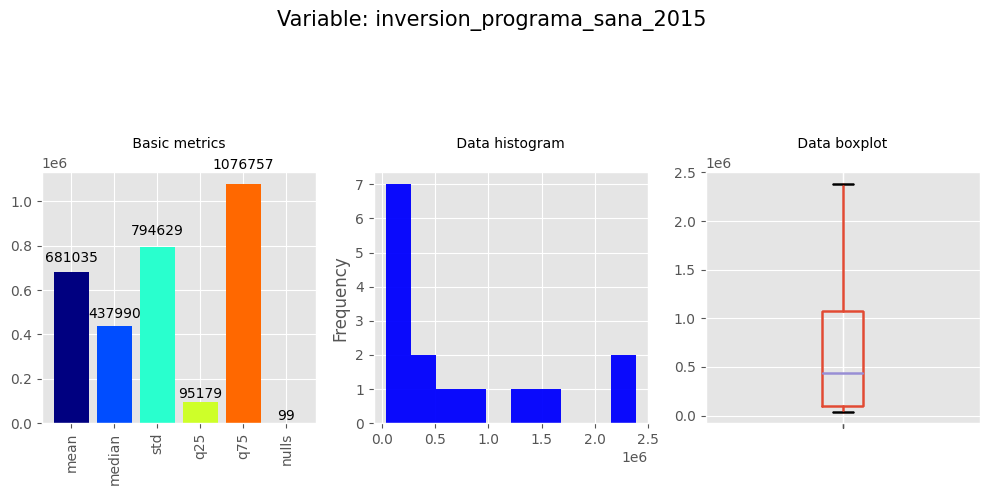

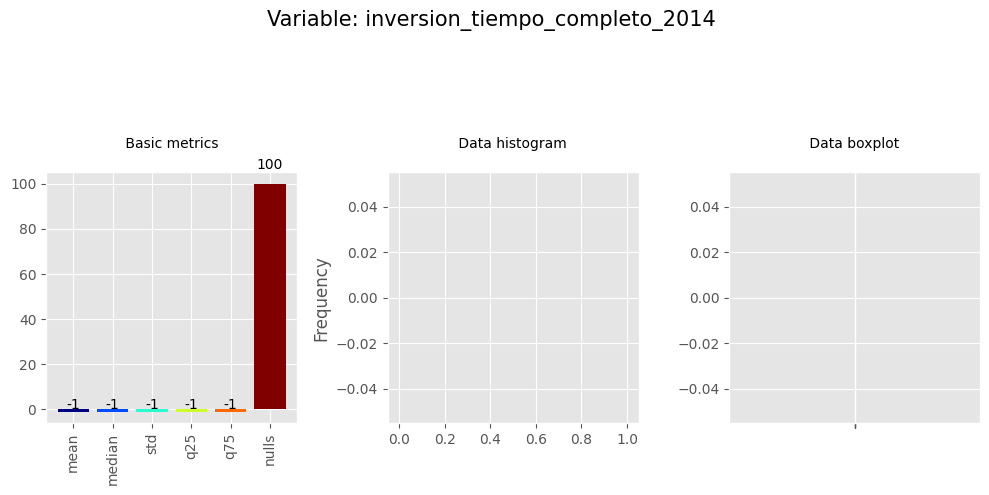

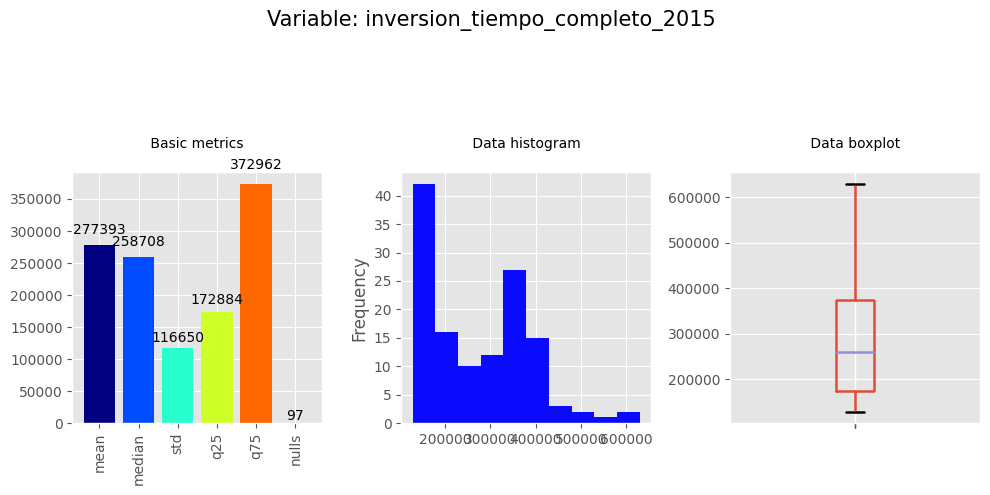

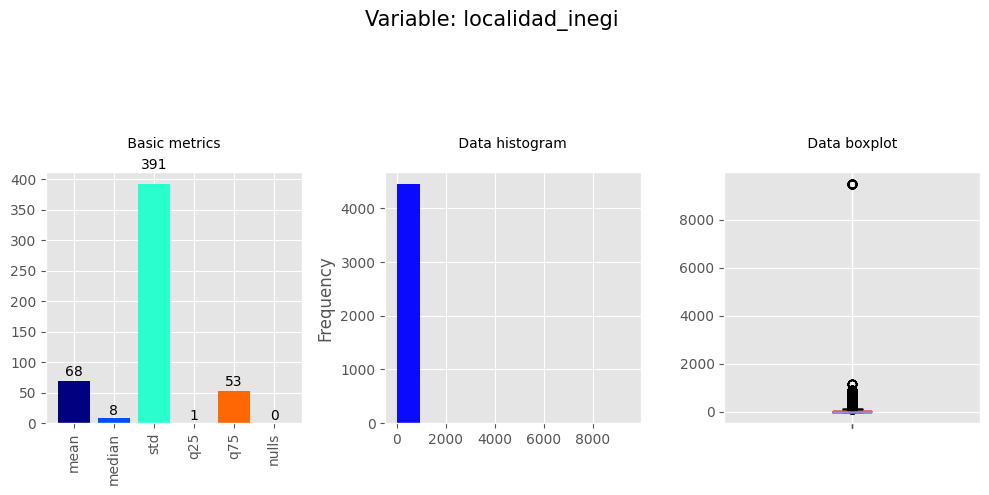

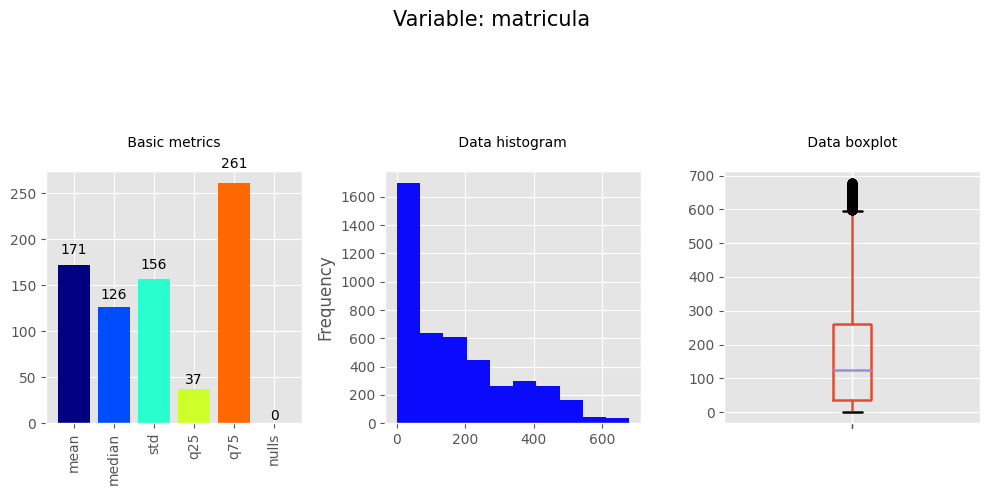

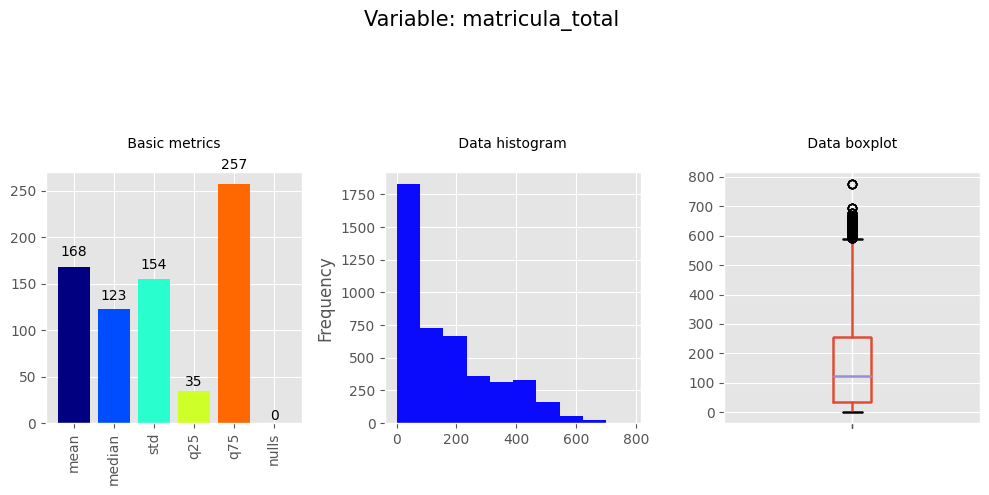

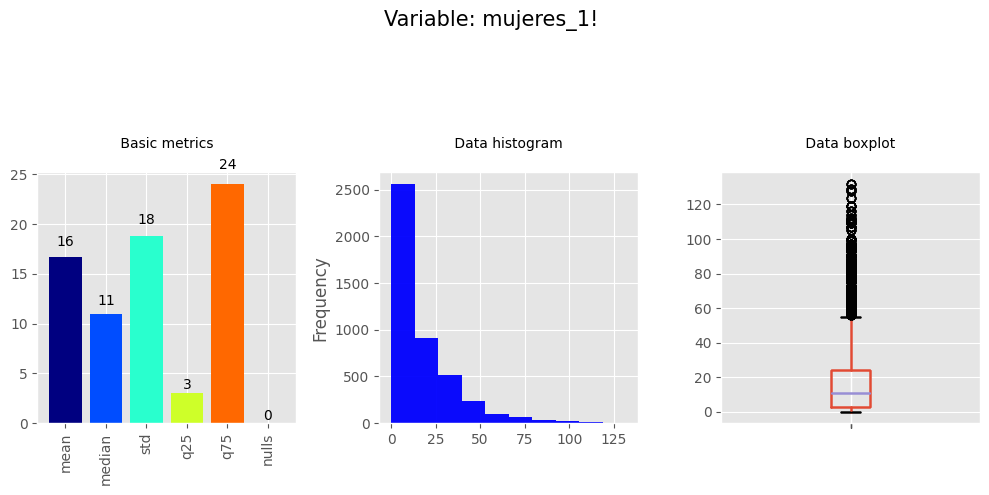

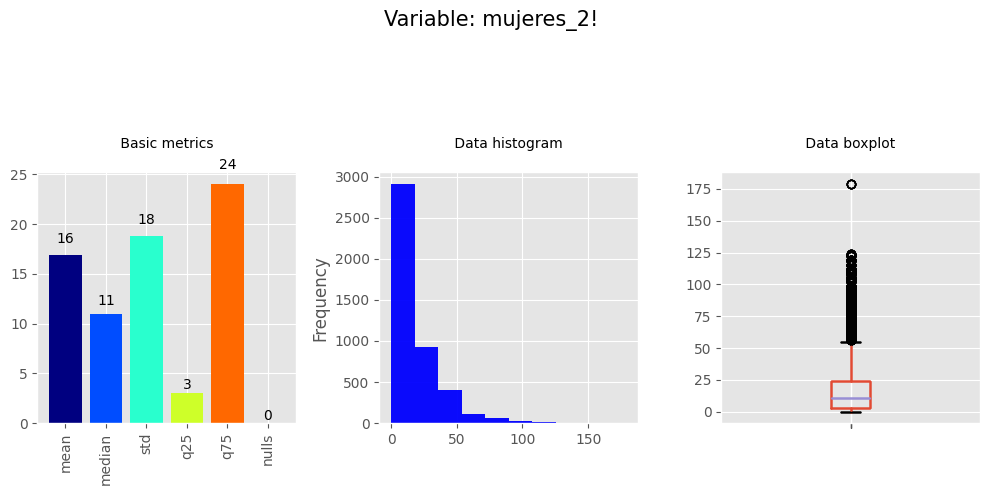

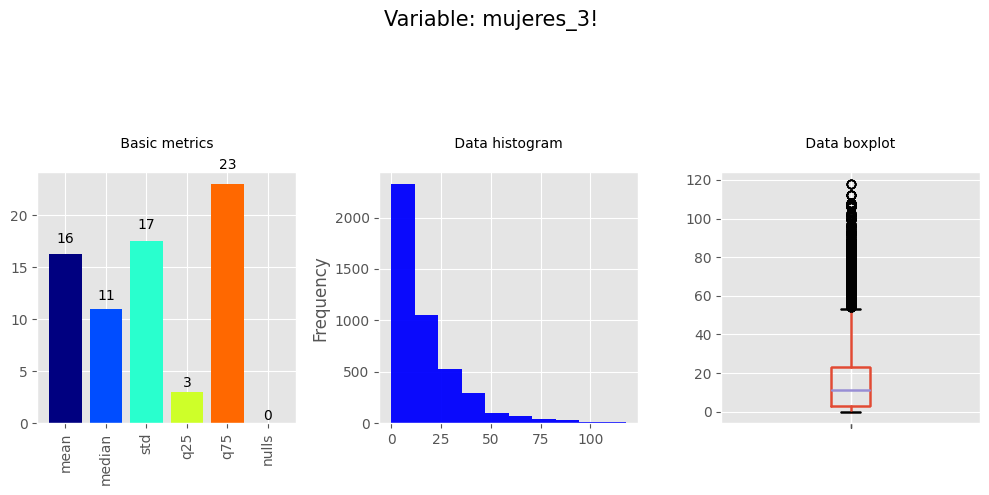

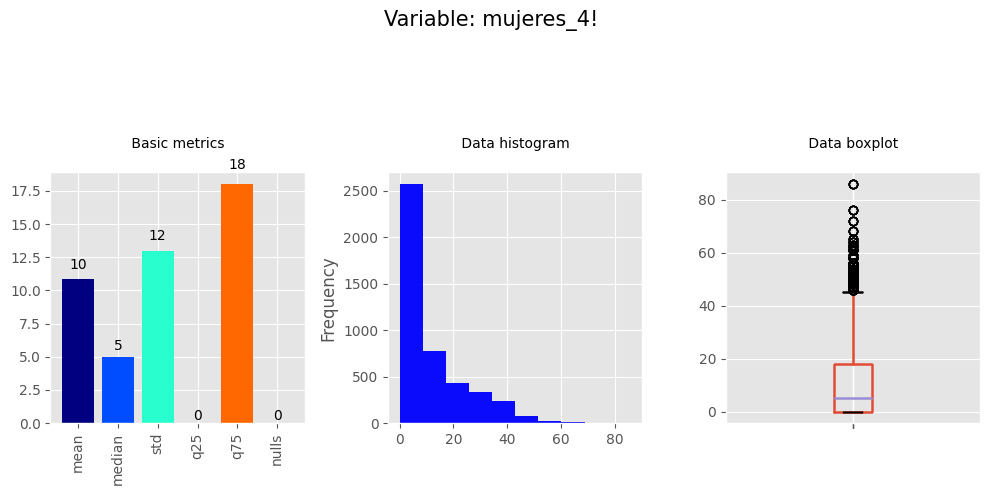

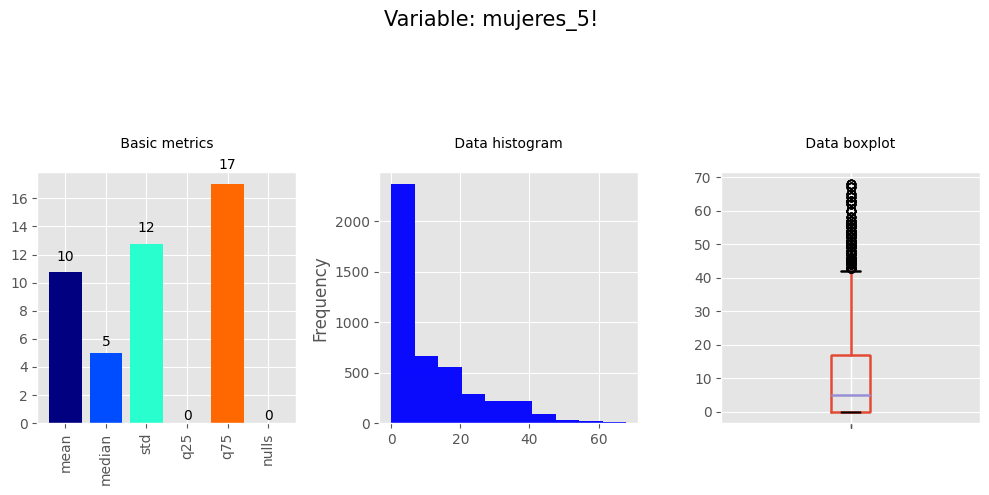

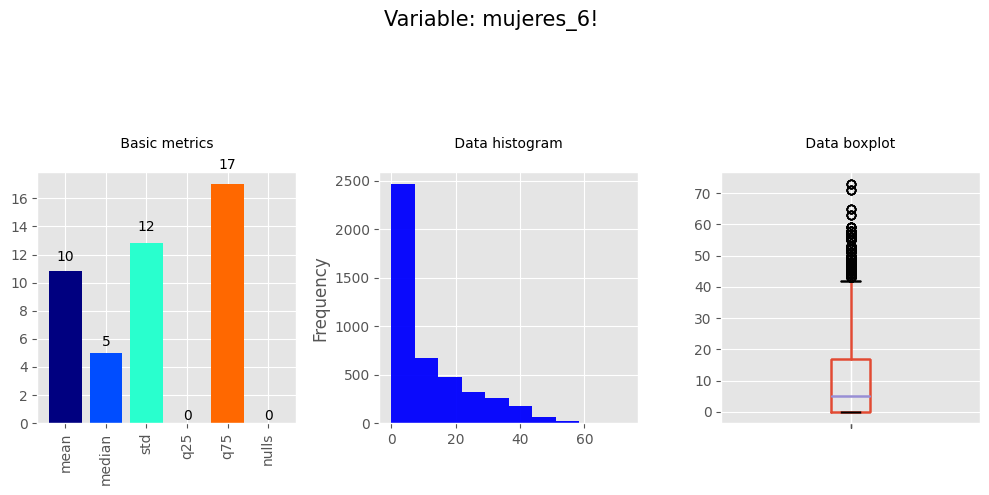

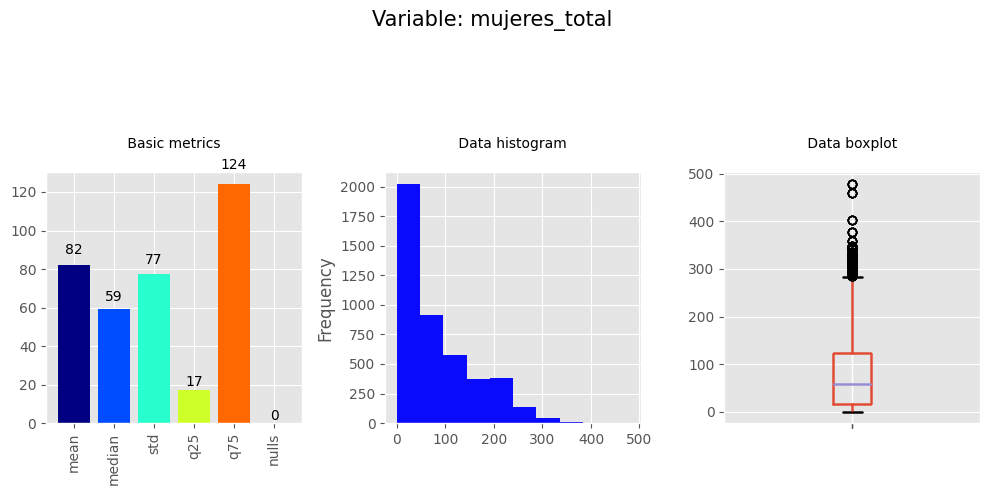

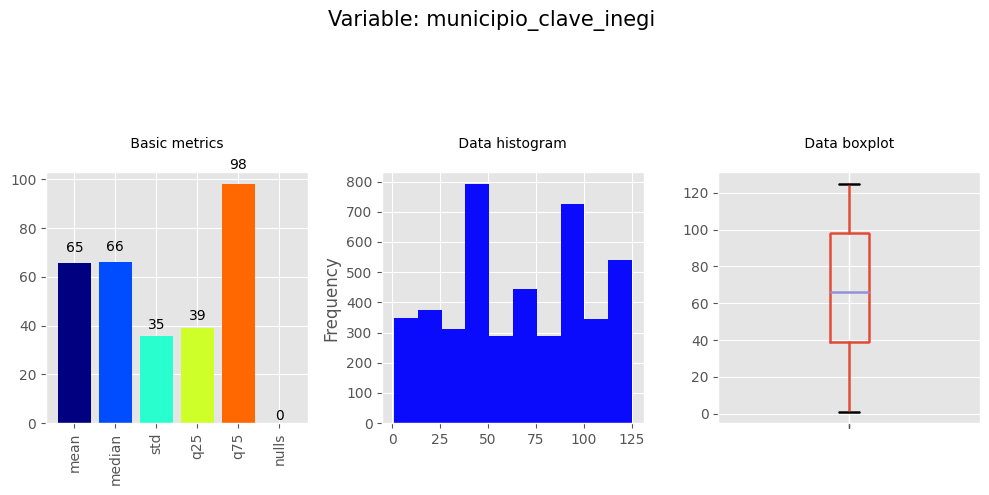

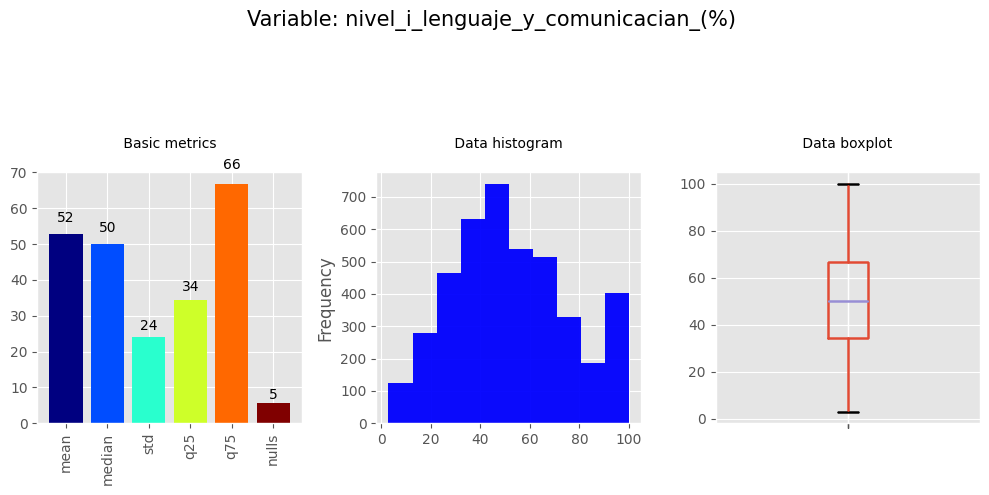

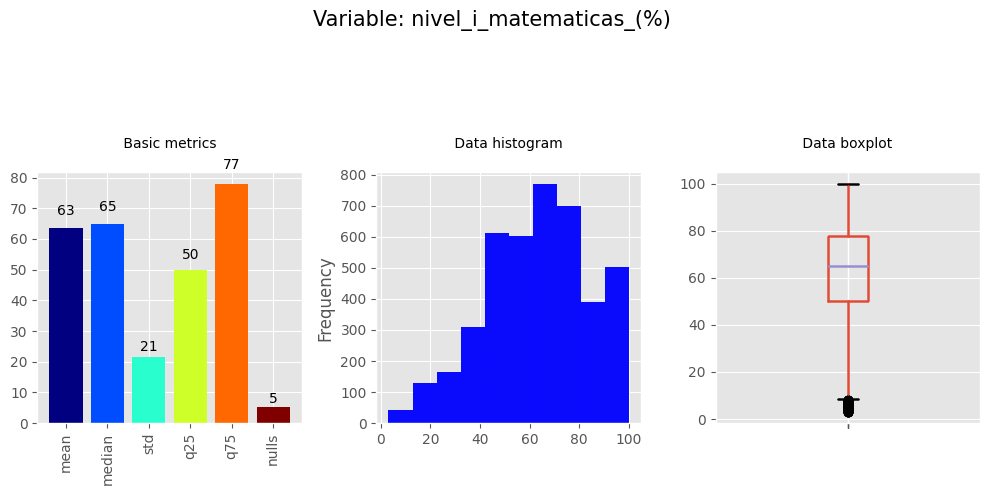

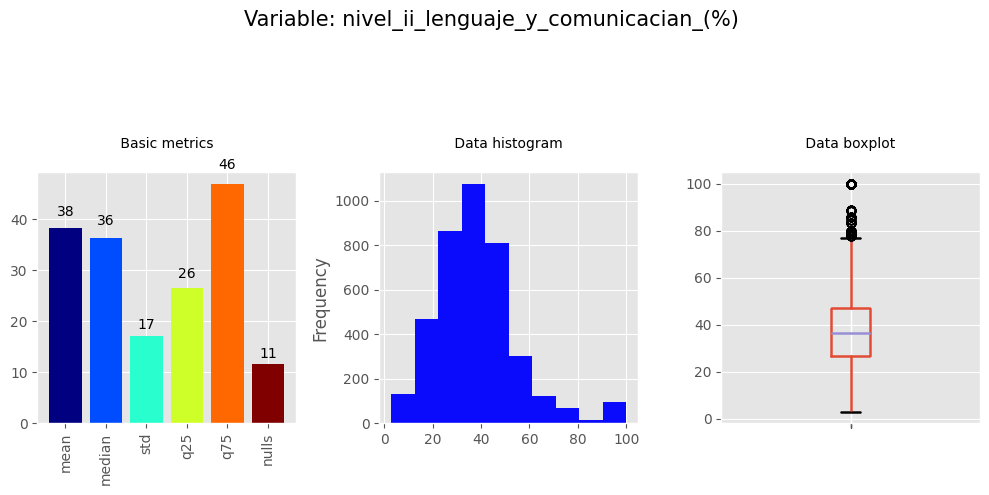

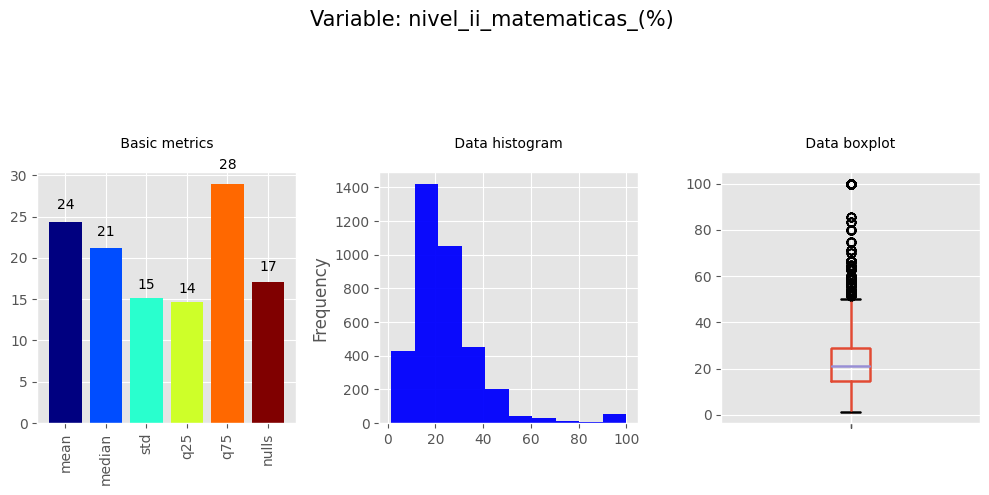

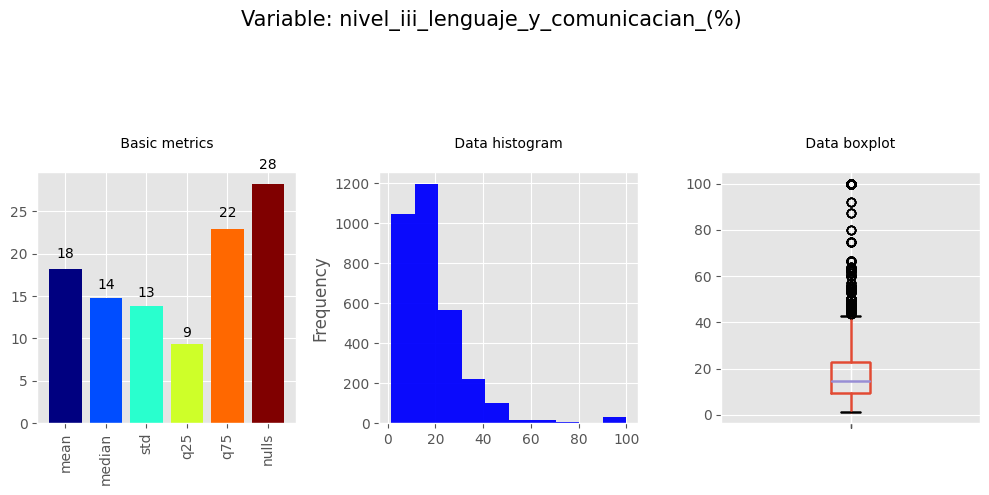

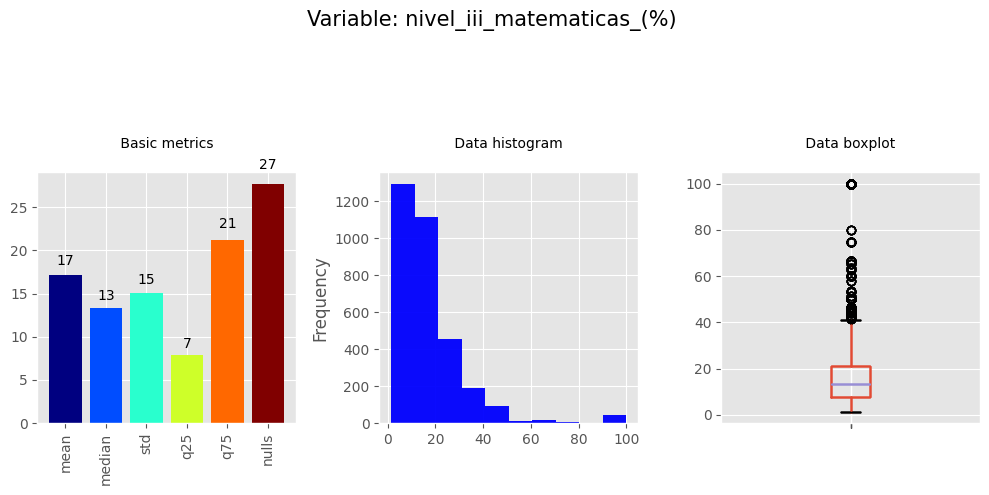

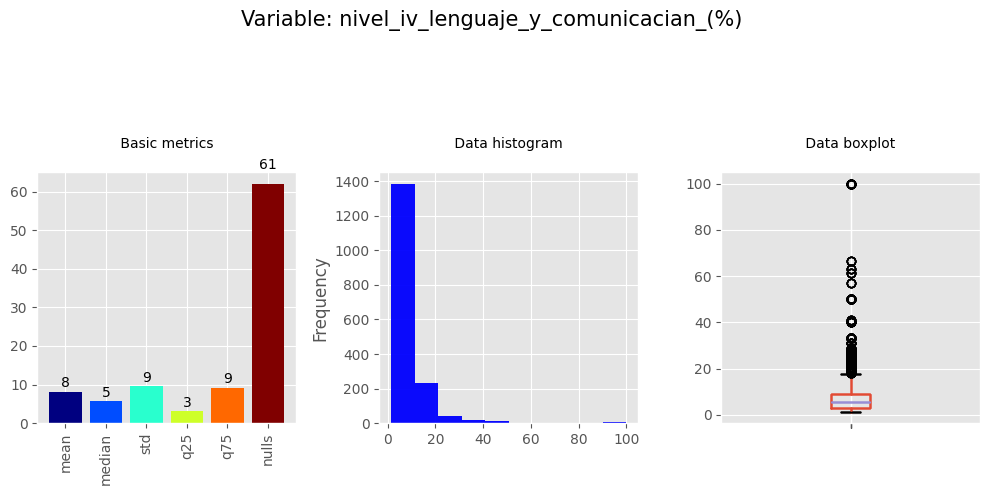

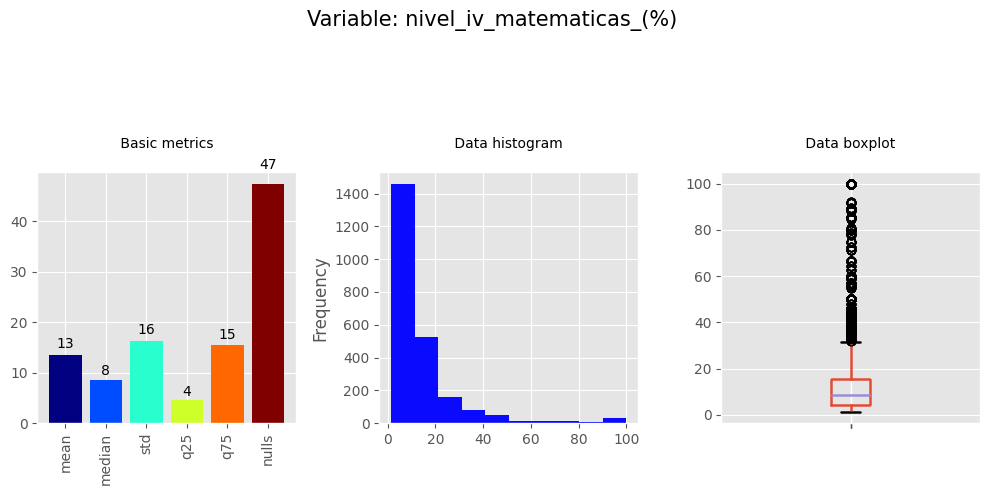

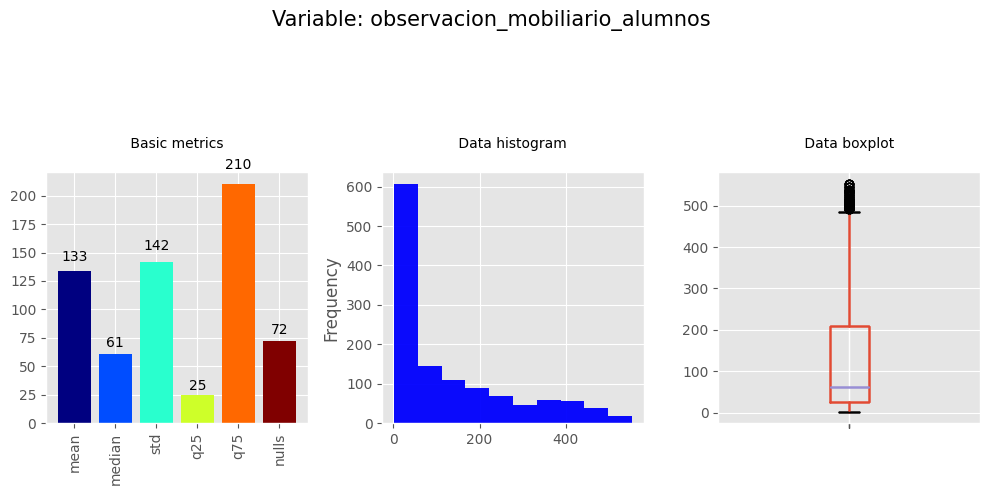

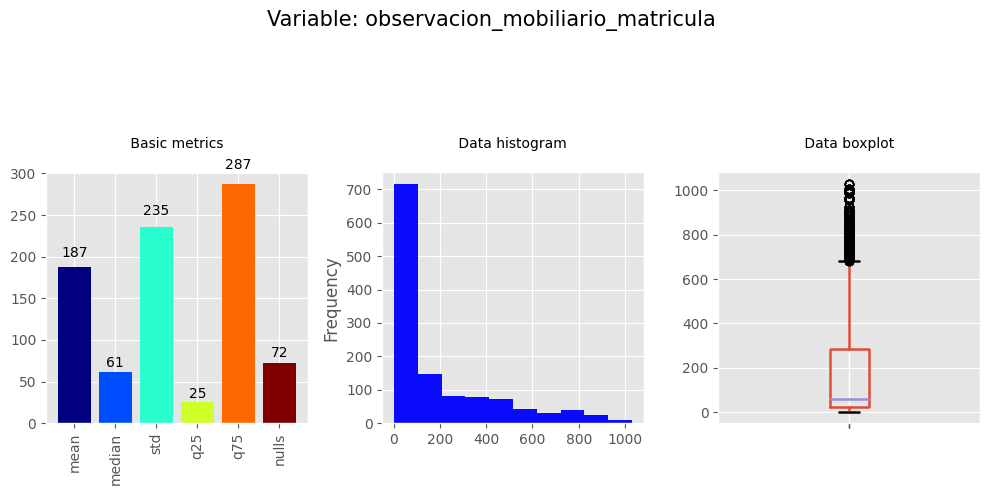

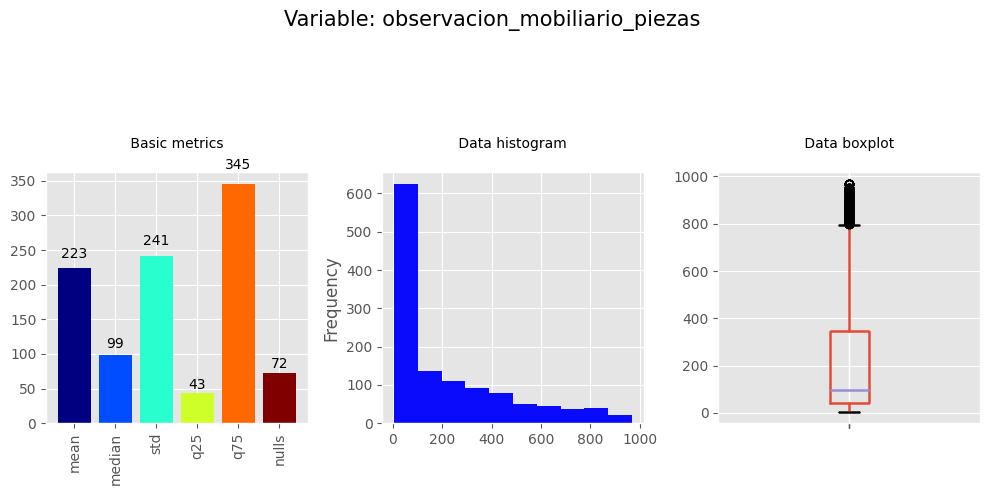

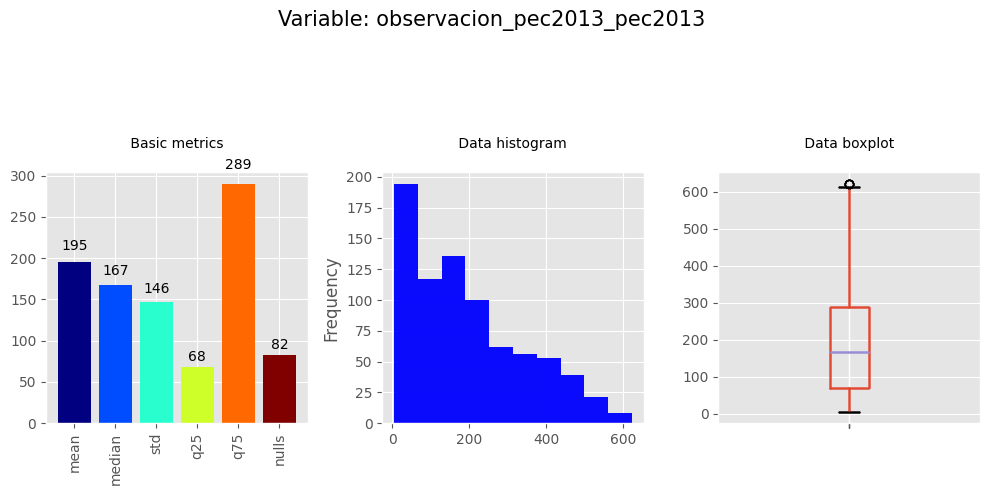

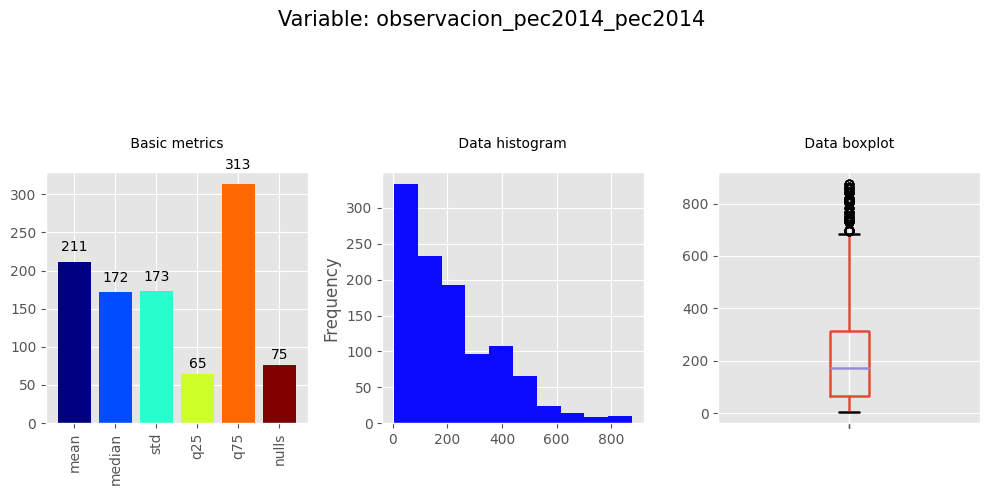

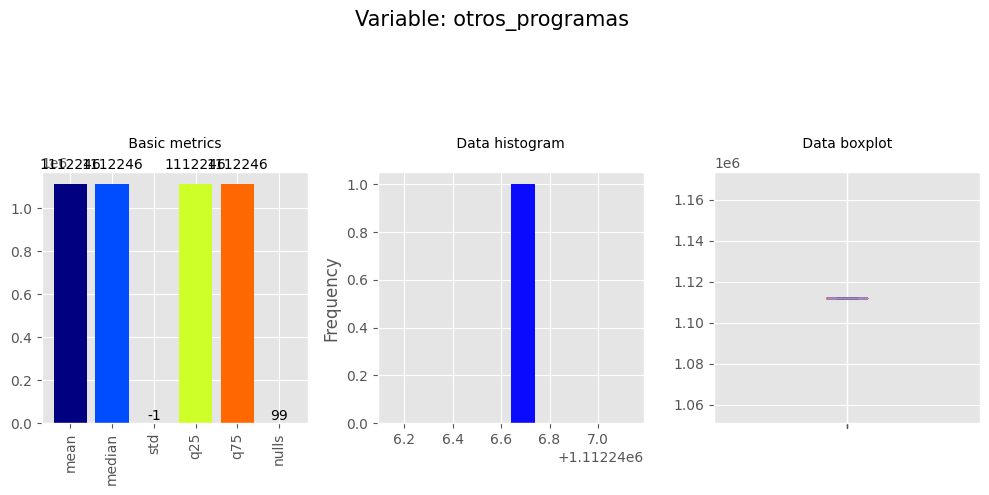

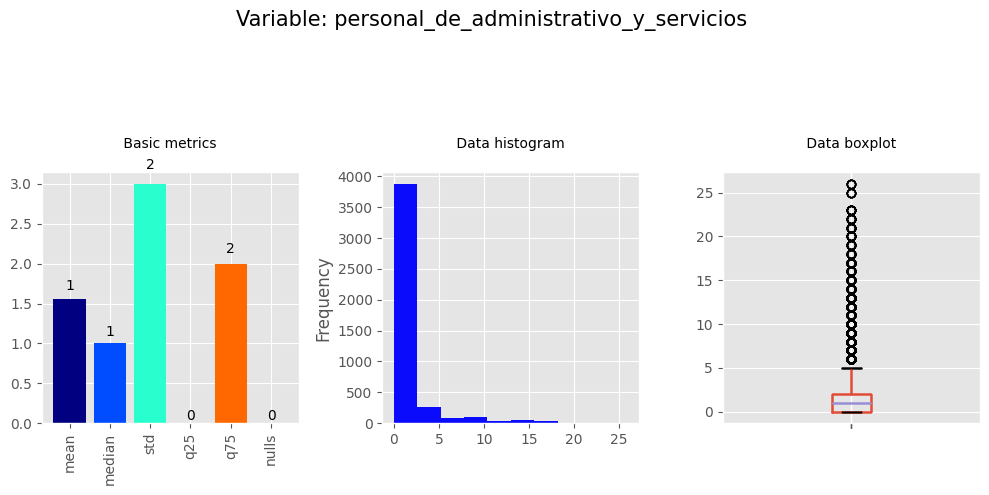

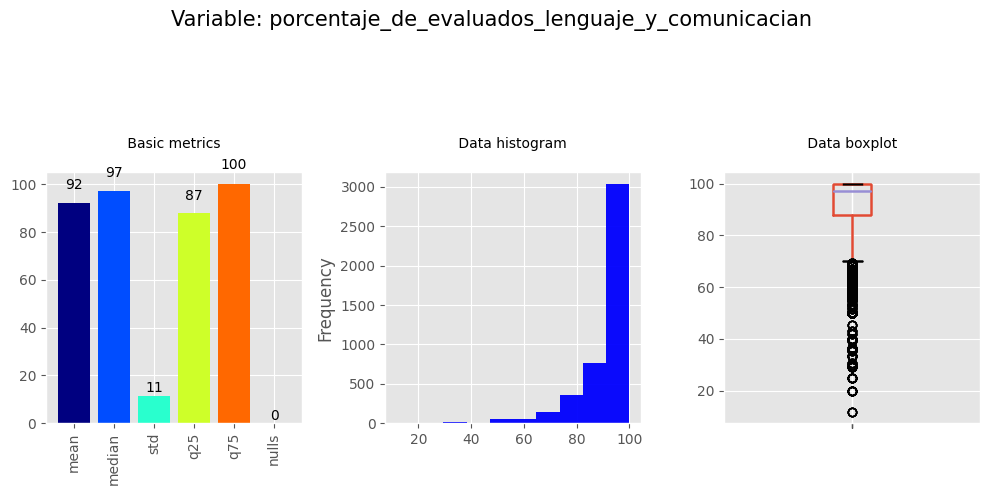

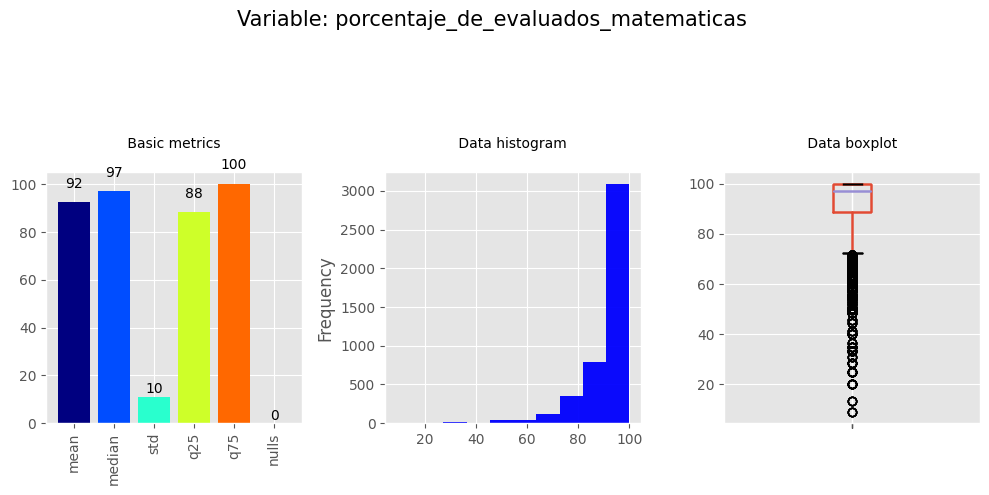

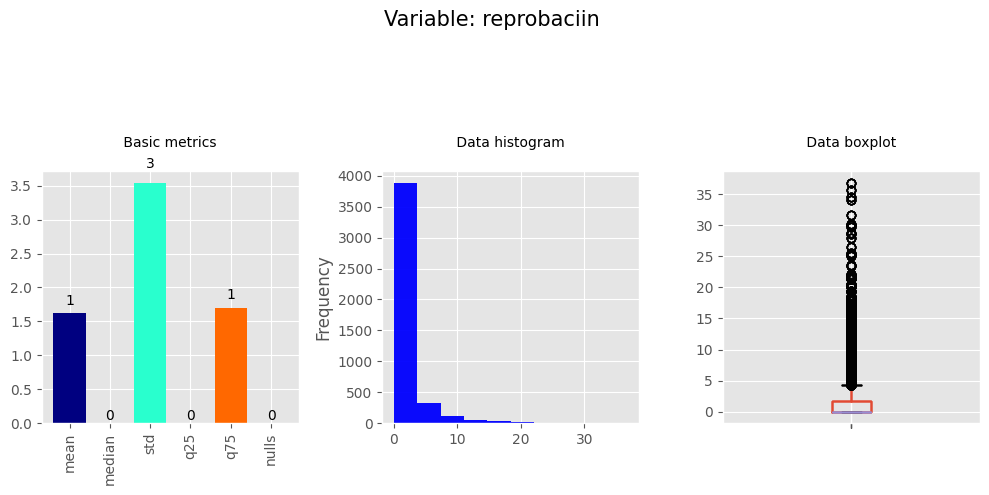

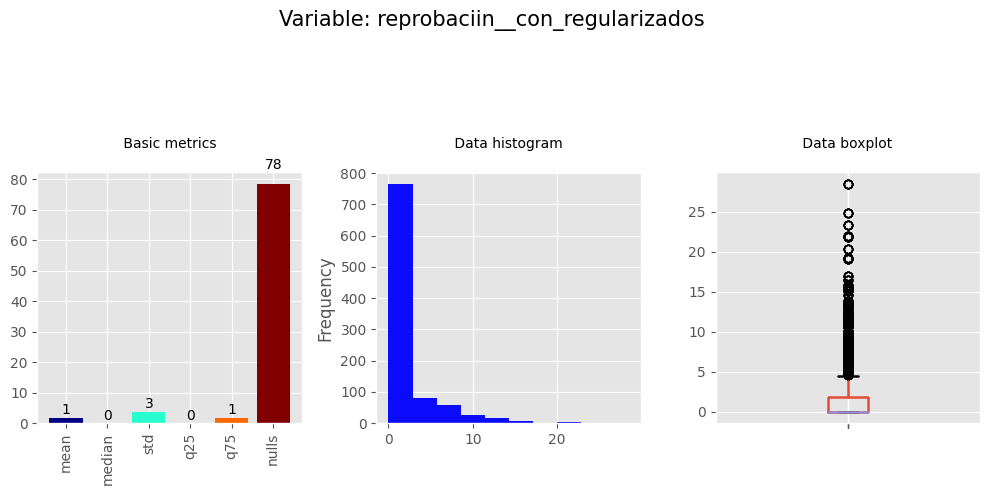

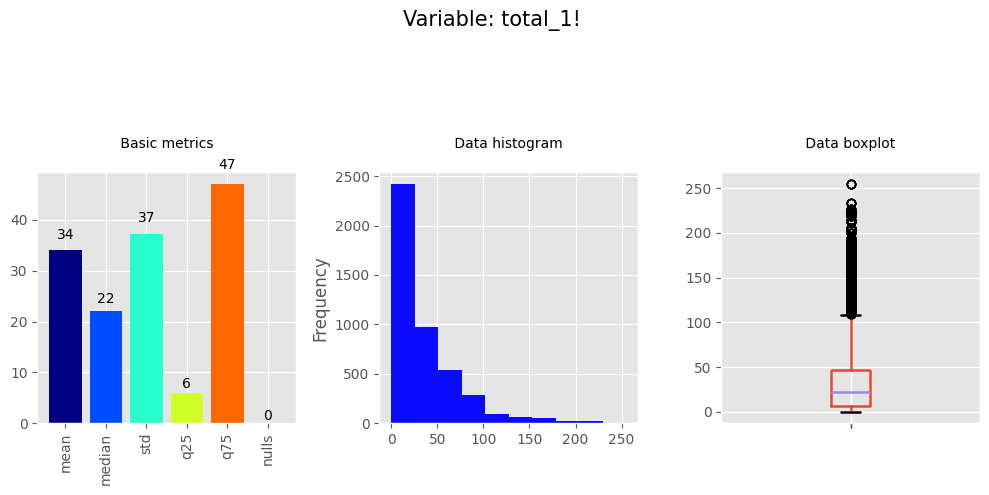

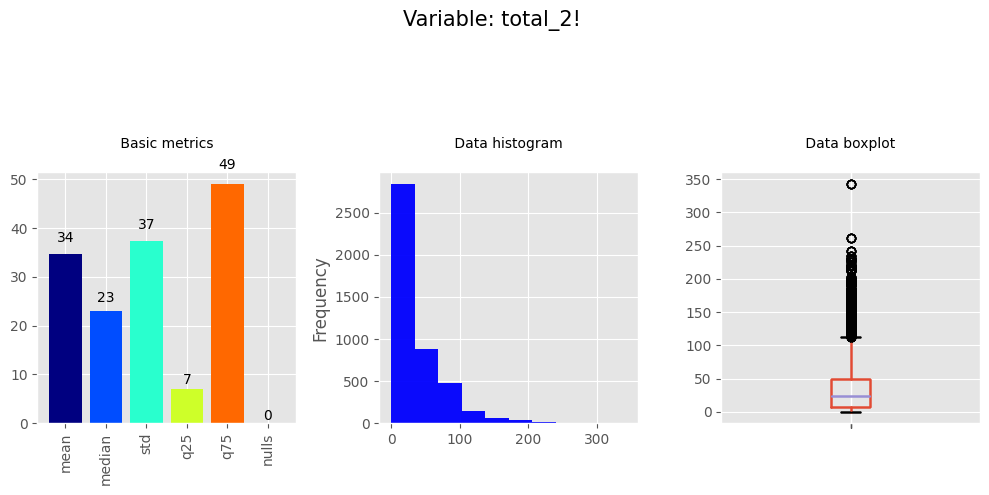

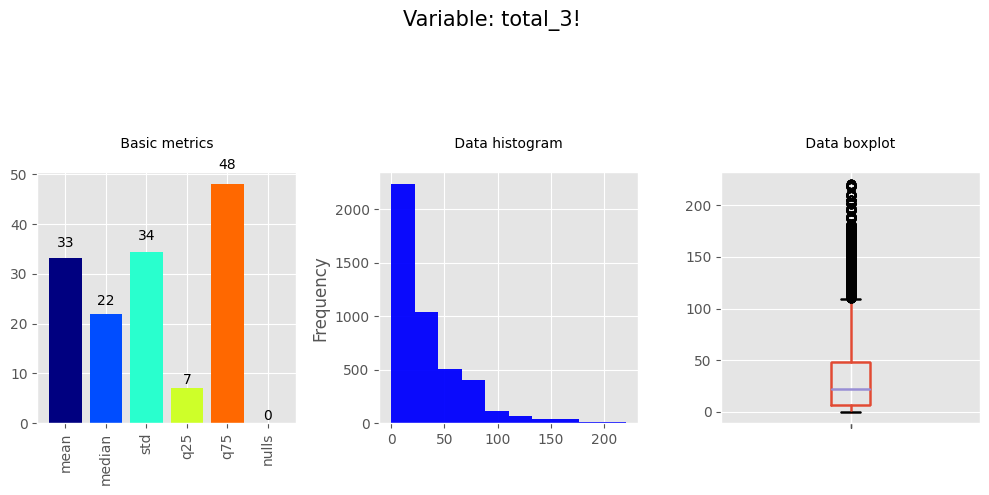

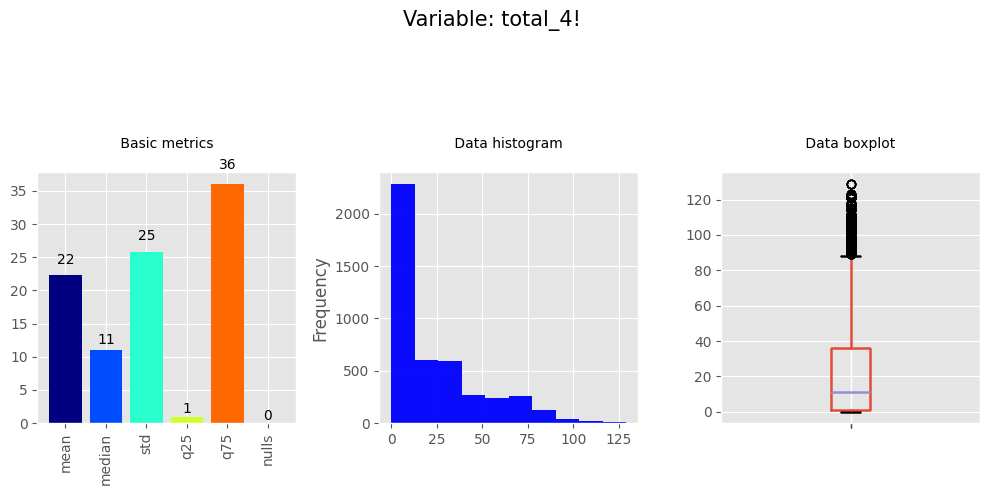

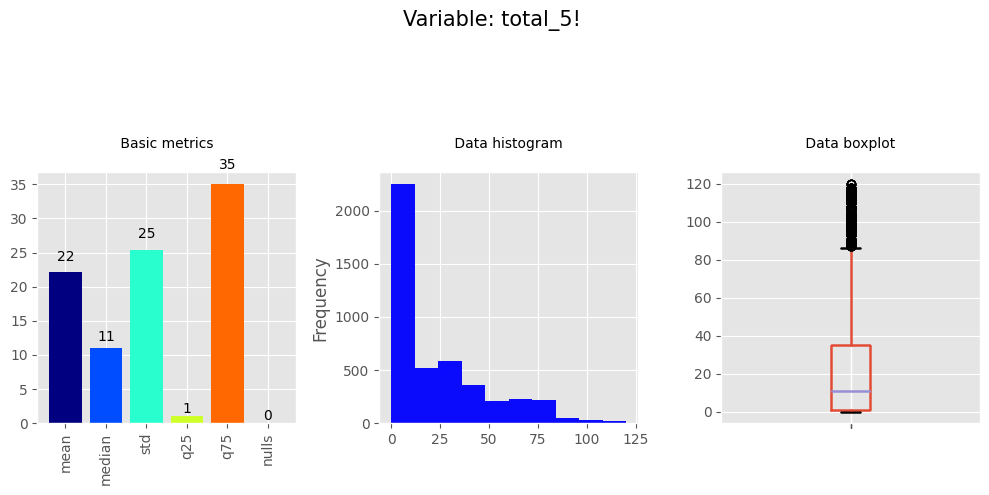

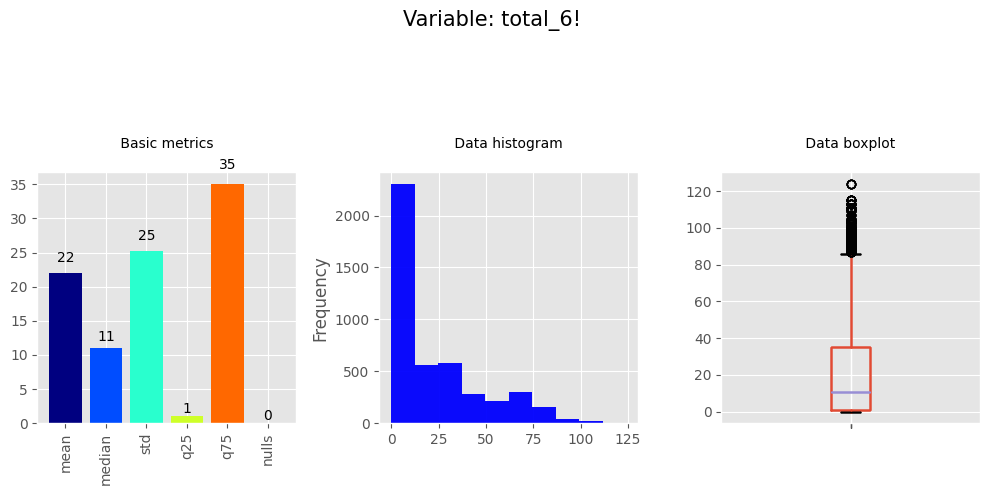

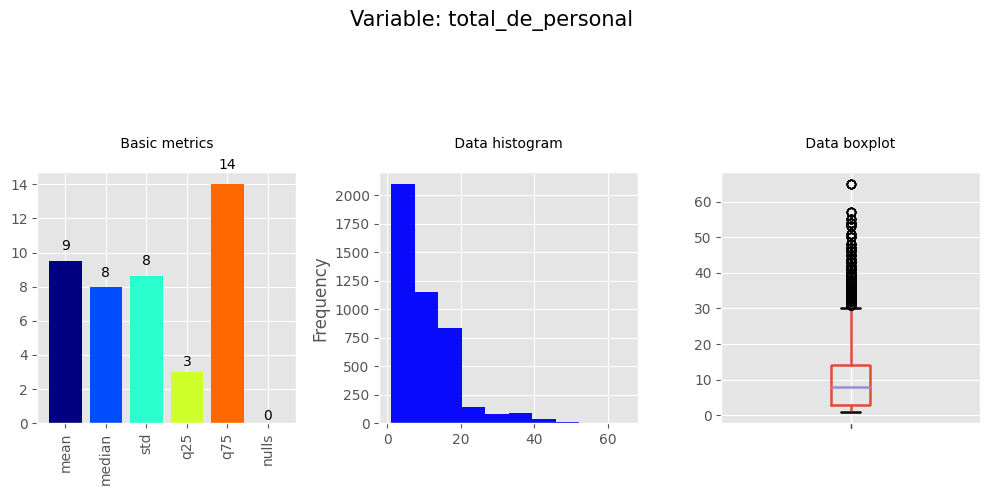

In [39]:
plot_numeric(df, numeric_stats)

##### Nuevas conclusiones antes del StoryTelling


## StoryTelling
Este concepto es muy sonado en empresas basadas en datos, de nada nos sirve los datos si no podemos describir qué tenemos en ellos. 

Ya hicimos conclusiones pero eso bien podría ser para un equipo de _data science_ o analítico (DS+BI), ¿qué pasa si presentamos nuestros datos? 

Hagamos unos ejemplos de agrupación y visualización con pandas y mapas. Para eso vamos a usar un nuevo mapa de los municipios del estado de Jalisco.

### Agrupación y medidas estadísticas
Supongamos que queremos hacer un análisis sencillo del promedio de alguna variable agrupada por turnos para ver si hay una diferencia entre el _performance_ de nuestros datos  a través de turnos educativos.

Referencias para el graficado de la dona: https://matplotlib.org/stable/gallery/pie_and_polar_charts/pie_and_donut_labels.html#sphx-glr-gallery-pie-and-polar-charts-pie-and-donut-labels-py

In [46]:
# Definir a través de qué vamos a agrupar
grouper = ['turno']

In [47]:
# Definir qué variables vamos a medir
performers = ['docente', 'aulas_uso', 'eficiencia_terminal']

In [48]:
# Definir qué vamos a medirle a esas variables
stats = ['mean', 'std', 'count']

In [50]:
# Definir dict de métricas 
metrics = {v: stats for v in performers}
metrics

{'docente': ['mean', 'std', 'count'],
 'aulas_uso': ['mean', 'std', 'count'],
 'eficiencia_terminal': ['mean', 'std', 'count']}

In [51]:
calc = df.groupby(grouper).agg(metrics)
calc

docente                 aulas_uso                  \
                 mean       std count      mean       std count   
turno                                                             
DISCONTINUO  4.428571  2.572751     7  4.285714  2.288689     7   
MATUTINO     6.374120  5.446850  2983  5.675159  4.176048  2983   
NOCTURNO     4.080000  2.942788    25  3.680000  2.286190    25   
VESPERTINO   8.370499  5.560278  1444  7.218144  3.978310  1444   

            eficiencia_terminal                   
                           mean        std count  
turno                                             
DISCONTINUO           28.214286  48.190470     7  
MATUTINO              85.560154  20.787254  2983  
NOCTURNO              66.848800  31.826585    25  
VESPERTINO            81.956267  23.936509  1444

In [44]:
# Grafiquemos en una dona el promedio de los datos


Grafiquemos ahora un mapa con valores del estado

Alguna referencias (no usadas en este código, pero útiles para el proceso): https://towardsdatascience.com/mapping-with-matplotlib-pandas-geopandas-and-basemap-in-python-d11b57ab5dac


In [45]:
# Leyendo mapas
data = df.copy()
col = 'beneficiarios_alimentos_dif_2014_digit'
file_name = 'limitemunicipal_mgj2012_modificadodecreto26837'
jalisco = get_shp_files(basedir=basedir, object_type=file_name)
jalisco = jalisco[list(jalisco.keys())[0]]

# Limpiando los mapas de Jalisco
jalisco['NOMBRE'] = jalisco['NOMBRE'].apply(lambda x: unidecode.unidecode(x))

# Reemplazando algunos caracteres del mapa de Jalisco
ugly_dict = {'BOLAÃ\x83Â\x83Ã\x82Â\x83Ã\x83Â\x82Ã\x82Â\x91OS': 'BOLANOS',
        'CAÃ\x83Â\x83Ã\x82Â\x83Ã\x83Â\x82Ã\x82Â\x91ADAS DE OBREGON': 'CANADAS DE OBREGON',
        'SAN MARTIN DE BOLAÃ\x83Â\x83Ã\x82Â\x83Ã\x83Â\x82Ã\x82Â\x91OS': 'SAN MARTIN DE BOLANOS',
        'TLAJOMULCO DE ZUÃ\x83Â\x83Ã\x82Â\x83Ã\x83Â\x82Ã\x82Â\x91IGA': 'TLAJOMULCO DE ZUNIGA'}


Initiating with .shp file reading over limitemunicipal_mgj2012_modificadodecreto26837 type of files.
Found file .shp: LimiteMunicipal_MGJ2012_modificadoDecreto26837.
Done with file seek over limitemunicipal_mgj2012_modificadodecreto26837.
